# **Instalações e Importações**

In [ ]:
%%capture

# Instalações
!pip install shap
!pip install optuna
!pip install cmaes

In [ ]:
# Bibliotecas
seed = 1

import os
import pickle
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import matplotlib

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler, MinMaxScaler, MaxAbsScaler, QuantileTransformer, LabelEncoder
from sklearn.metrics import roc_curve, roc_auc_score, auc, ConfusionMatrixDisplay, classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

import optuna
from optuna.samplers import RandomSampler, TPESampler, CmaEsSampler

import shap

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
# warnings.simplefilter(action='ignore', category=UserWarning)

# **Funções**

In [ ]:
#######################################################################################

def train_preprocessing(df, ohe_encoder=None, normalizer='StandardScaler'):
    """
    Performs preprocessing on the training dataset.

    Args:
        df (pandas.DataFrame): The DataFrame to be preprocessed.
        ohe_encoder (list, optional): A list of columns to apply one-hot encoding. If None,
            all categorical columns will be encoded using LabelEncoder.
        normalizer (str, optional): The type of normalization to apply. Defaults to 'StandardScaler'.
            Options include: 'StandardScaler', 'MinMaxScaler', 'MaxAbsScaler', 'QuantileTransformer'.

    Returns:
        tuple: A tuple containing:
            - df_aux (pandas.DataFrame): The preprocessed DataFrame.
            - enc (dict): A dictionary of encoders, one for each categorical variable.
            - norm: The normalization object used.
            - feat_cols (list): A list of feature column names.
    """

    df_aux = df.copy()

    enc = {}  # Dictionary to store encoders
    if ohe_encoder != None:
        # Apply one-hot encoding to specified columns
        for col in ohe_encoder:
            enc[col] = OneHotEncoder(handle_unknown='ignore', drop='first')
            ohe_results = enc[col].fit_transform(df_aux[[col]])
            df1 = pd.DataFrame(ohe_results.toarray(),
                               columns=enc[col].get_feature_names_out(),
                               index=df_aux[col].index)
            df_aux = df_aux.merge(df1, how='left', left_index=True, right_index=True)

        df_aux.drop(columns=ohe_encoder, inplace=True)

    # Apply label encoding to remaining categorical columns
    list_categorical = df_aux.select_dtypes(include='object').columns
    for col in list_categorical:
        enc[col] = LabelEncoder()
        df_aux[col] = enc[col].fit_transform(df_aux[col])

    # Select feature columns
    feat_cols = df_aux.columns

    # Apply normalization
    if normalizer == 'StandardScaler':
        norm = StandardScaler()
    elif normalizer == 'MinMaxScaler':
        norm = MinMaxScaler((0, 1))
    elif normalizer == 'MaxAbsScaler':
        norm = MaxAbsScaler()
    elif normalizer == 'QuantileTransformer':
        norm = QuantileTransformer(output_distribution='normal')

    df_aux = norm.fit_transform(df_aux)

    return df_aux, enc, norm, feat_cols

#######################################################################################

def test_preprocessing(df, enc, norm, ohe_encoder=None):
    """
    Performs preprocessing on the test dataset using the provided encoders and normalizer.

    Args:
        df (pandas.DataFrame): The DataFrame to be preprocessed.
        enc (dict): A dictionary of encoders used for categorical features in the training set.
        norm: The normalization object used for the training set.
        ohe_encoder (list, optional): A list of columns to apply one-hot encoding. If None,
            all categorical columns will be encoded using LabelEncoder.

    Returns:
        pandas.DataFrame: The preprocessed DataFrame.
    """

    df_aux = df.copy()

    if ohe_encoder:
        # Apply one-hot encoding to specified columns using pre-trained encoders
        for col in ohe_encoder:
            ohe_results = enc[col].transform(df_aux[[col]])
            df1 = pd.DataFrame(ohe_results.toarray(),
                               columns=enc[col].get_feature_names_out(),
                               index=df_aux[col].index)
            df_aux = df_aux.merge(df1, how='left', left_index=True, right_index=True)

        df_aux.drop(columns=ohe_encoder, inplace=True)

    # Apply label encoding to remaining categorical columns
    # Handle unseen categories by assigning them a new category (e.g., -1)
    list_categorical = df_aux.select_dtypes(include='object').columns
    for col in list_categorical:
        df_aux.loc[~df_aux[col].isin(enc[col].classes_), col] = -1
        df_aux.loc[df_aux[col].isin(enc[col].classes_), col] = enc[col].transform(df_aux[col][df_aux[col].isin(enc[col].classes_)])

    # Apply normalization using the pre-trained scaler
    df_aux = norm.transform(df_aux)

    return df_aux

#######################################################################################

def preprocessing(x_train, x_test, ohe_encoder=None,
                  norm_name='StandardScaler', return_enc_norm=False,
                  random_state=0):
    """
    Performs comprehensive data preprocessing, including train-test split,
    categorical encoding, normalization, and optional class balancing.

    Args:
        x_train: The DataFrame containing the train data.
        x_test: The DataFrame containing the test data.
        ohe_encoder: A list of columns for one-hot encoding.
        norm_name: The name of the normalizer to use.
        return_enc_norm: Whether to return the encoders and normalizer.
        random_state: Random seed for reproducibility.

    Returns:
        A tuple containing:
            - X_train_enc: Preprocessed training features.
            - X_test_: Preprocessed testing features.
            - feat_cols: Feature column names after preprocessing.
            - enc (optional): Dictionary of encoders used.
            - norm (optional): Normalization object used.
    """
    # Preprocess training set
    X_train_enc, enc, norm, feat_cols = train_preprocessing(x_train, ohe_encoder=ohe_encoder,
                                                            normalizer=norm_name)
    # Preprocess testing set using the same encoders and normalizer
    X_test_ = test_preprocessing(x_test, enc, norm, ohe_encoder=ohe_encoder)

    # Print shapes for verification
    print(f'X_train = {X_train_enc.shape}, X_test = {X_test_.shape}')

    # Return results
    if return_enc_norm:
        return X_train_enc, X_test_, feat_cols, enc, norm
    else:
        return X_train_enc, X_test_, feat_cols

#######################################################################################

def plot_roc_curve(model, X_train, X_test, y_train, y_test):
    """
    Plots the Receiver Operating Characteristic (ROC) curve for a classification model,
    calculating the Area Under the Curve (AUC) for both training and testing sets.

    Args:
        model: A trained classification model with a `predict_proba` method.
        X_train: Training features.
        X_test: Testing features.
        y_train: Training labels.
        y_test: Testing labels.

    Returns:
        None: Displays the ROC curve plot.
    """

    # Get predicted probabilities for positive class
    probas_train = model.predict_proba(X_train)[:, 1]
    probas_test = model.predict_proba(X_test)[:, 1]

    # Calculate true positive rate (TPR) and false positive rate (FPR)
    fp_train, tp_train, _ = roc_curve(y_train, probas_train)
    fp_test, tp_test, _ = roc_curve(y_test, probas_test)

    # Calculate AUC
    auc_train = auc(fp_train, tp_train)
    auc_test = auc(fp_test, tp_test)

    # Plot ROC curves
    plt.figure(figsize=(10, 7))
    plt.plot(fp_train, tp_train, 'b', label=f'Train (AUC = {auc_train:.4f})')
    plt.plot(fp_test, tp_test, 'r', label=f'Test (AUC = {auc_test:.4f})')

    # Plot random guessing line
    plt.plot(np.linspace(0, 1, 100),
             np.linspace(0, 1, 100),
             label='Baseline',
             linestyle='--',
             color='k')

    # Set plot labels and display
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC) Curve')
    plt.grid(True)
    plt.legend()
    plt.show()

#######################################################################################

def plot_confusion_matrix(model, x, y, format='.5f', norm=True):
    """
    Plots a normalized confusion matrix and classification report for a given model.

    Args:
        model: A trained classification model.
        x: The features of the test set.
        y: The true labels of the test set.
        format (str, optional): Format specifier for the values in the confusion matrix.
            Defaults to '.5f' (5 decimal places).
        norm (bool, optional): If True, normalizes the confusion matrix. Defaults to True.

    Returns:
        None: Displays the confusion matrix and classification report.
    """

    # Create a confusion matrix plot
    with plt.rc_context({'font.size': 12, 'font.weight': 'bold'}):
        if norm:
            # Plot a normalized confusion matrix
            ConfusionMatrixDisplay.from_estimator(model, x, y, values_format=format,
                                                 cmap='binary', normalize='true')
        else:
            # Plot a non-normalized confusion matrix
            ConfusionMatrixDisplay.from_estimator(model, x, y, cmap='binary',
                                                 values_format='.0f')
        plt.show()

    # Generate a classification report
    pred = model.predict(x)
    print(f'\n{classification_report(y, pred, digits=5)}')

#######################################################################################

def plot_shap_values(model, x, features, max_display=10):
    """
    Plots a summary plot of SHAP values to visualize feature importance.

    Args:
        model: A trained machine learning model.
        x: A pandas DataFrame containing the features used to train the model.
        features: A list of feature names.
        max_display: The maximum number of features to display in the plot.

    Returns:
        None: Displays the SHAP summary plot.
    """

    # Calculate SHAP values
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(x)

    # Plot summary plot
    try:
        # For models with multiple outputs
        shap.summary_plot(shap_values[1], x, feature_names=features, max_display=max_display)
    except AssertionError:
        # For models with a single output
        shap.summary_plot(shap_values, x, feature_names=features, max_display=max_display)

#######################################################################################

# **Sobrevida de 1 ano**

## **Treino e Teste**



In [ ]:
# Conjunto de dados de colorretal
!gdown 1yzI52UDZyac0QGWmKL5Mai1JOqWUTeMQ --quiet

In [ ]:
# Leitura dos dados
df_colo = pd.read_csv('colorretal.csv')
print(df_colo.shape)
df_colo.head(3)

(44857, 49)


,INSTITU,ESCOLARI,IDADE,SEXO,IBGE,CATEATEND,DIAGPREV,TOPO,EC,ECGRUP,...,TRATCONS_CAT,DIAGTRAT_CAT,PRESENCA_META,PRESENCA_REC,obito_geral,obito_cancer,sobrevida_ano1,sobrevida_ano3,sobrevida_ano5,meses_diag
0,612374,9,91,2,3550308,2,2,C209,IIA,II,...,0,1,0,0,0,0,1,0,0,23
1,8,9,79,2,3550308,9,1,C180,II,II,...,0,0,0,0,0,0,1,1,1,61
2,8,9,59,2,3534401,9,2,C209,II,II,...,0,0,0,1,0,0,1,1,1,61


In [ ]:
# Colunas
df_colo.columns

Index(['INSTITU', 'ESCOLARI', 'IDADE', 'SEXO', 'IBGE', 'CATEATEND', 'DIAGPREV',
       'TOPO', 'EC', 'ECGRUP', 'NENHUM', 'CIRURGIA', 'RADIO', 'QUIMIO',
       'HORMONIO', 'IMUNO', 'OUTROS', 'NENHUMAPOS', 'CIRURAPOS', 'RADIOAPOS',
       'QUIMIOAPOS', 'HORMOAPOS', 'IMUNOAPOS', 'OUTROAPOS', 'ULTINFO',
       'CONSDIAG', 'TRATCONS', 'DIAGTRAT', 'ANODIAG', 'DRS', 'RRAS', 'DSCINST',
       'IBGEATEN', 'HABILIT2', 'DRS_INST', 'RRAS_INST', 'ECGRUP_CAT',
       'ULTIDIAG', 'CONSDIAG_CAT', 'TRATCONS_CAT', 'DIAGTRAT_CAT',
       'PRESENCA_META', 'PRESENCA_REC', 'obito_geral', 'obito_cancer',
       'sobrevida_ano1', 'sobrevida_ano3', 'sobrevida_ano5', 'meses_diag'],
      dtype='object')

In [ ]:
# Retirada dos pacientes censurados
df_colo = df_colo[~((df_colo.obito_geral == 0) & (df_colo.sobrevida_ano1 == 0))].reset_index(drop=True)
df_colo.shape

(41638, 49)

In [ ]:
# Distribuição do óbito por qualquer motivo
df_colo['obito_geral'].value_counts()

,count
obito_geral,
1,21877
0,19761


In [ ]:
# Distribuição da sobrevida de 1 ano
df_colo['sobrevida_ano1'].value_counts()

,count
sobrevida_ano1,
1,31425
0,10213


In [ ]:
# Divisão dos dados em treino e teste
# Separação das features (X) e label (y)
X = df_colo.drop(['obito_geral'], axis=1)  # Features (todas as colunas, exceto 'obito_geral')
y = df_colo['obito_geral']  # Label ('obito_geral')

# Divisão do conjunto de dados
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,  # 80% treino, 20% teste
                                                    random_state=seed,  # Reprodutibilidade
                                                    stratify=y)  # Estratificação para manter a proporção das classes

# Tamanhos dos conjuntos após a divisão dos dados
print(f'X_train: {X_train.shape}')
print(f'y_train: {y_train.shape}')
print(f'X_test: {X_test.shape}')
print(f'y_test: {y_test.shape}')

X_train: (33310, 48)
y_train: (33310,)
X_test: (8328, 48)
y_test: (8328,)


In [ ]:
# Salvamento dos datasets
# Concatenação das features e label
df_treino = pd.concat([X_train, y_train], axis=1)  # Combinação do X_train e y_train em um conjunto de dados
df_teste = pd.concat([X_test, y_test], axis=1)  # Combinação do X_test e y_test em um conjunto de dados

df_treino.to_csv('colorretal_treino.csv', index=False)  # Salva o dataset de treino como 'colorretal_treino.csv'
df_teste.to_csv('colorretal_teste.csv', index=False)  # Salva o dataset de teste como 'colorretal_teste.csv'

## **Preparação dos dados**

In [ ]:
# Leitura dos dados de treino
df_treino = pd.read_csv('colorretal_treino.csv')
print(df_treino.shape)  # Dimensões dos dados
df_treino.head(3)  # 3 primeiras linhas

(33310, 49)


,INSTITU,ESCOLARI,IDADE,SEXO,IBGE,CATEATEND,DIAGPREV,TOPO,EC,ECGRUP,...,TRATCONS_CAT,DIAGTRAT_CAT,PRESENCA_META,PRESENCA_REC,obito_cancer,sobrevida_ano1,sobrevida_ano3,sobrevida_ano5,meses_diag,obito_geral
0,270877,4,31,2,3552205,2,2,C187,IVA,IV,...,0,2,1,0,0,1,1,1,61,0
1,16624,3,67,2,3550308,2,2,C182,IIIB,III,...,3,3,0,0,1,0,0,0,2,1
2,20737,2,80,2,3512001,9,2,C209,IIA,II,...,2,2,0,0,0,1,0,0,17,1


In [ ]:
# Leitura dos dados de teste
df_teste = pd.read_csv('colorretal_teste.csv')
print(df_teste.shape)  # Dimensões dos dados
df_teste.head(3)  # 3 primeiras linhas

(8328, 49)


,INSTITU,ESCOLARI,IDADE,SEXO,IBGE,CATEATEND,DIAGPREV,TOPO,EC,ECGRUP,...,TRATCONS_CAT,DIAGTRAT_CAT,PRESENCA_META,PRESENCA_REC,obito_cancer,sobrevida_ano1,sobrevida_ano3,sobrevida_ano5,meses_diag,obito_geral
0,22128,5,37,2,3549805,2,1,C185,IV,IV,...,2,2,1,1,1,1,1,0,51,1
1,740092,3,70,2,3542404,2,2,C182,I,I,...,0,1,0,0,0,1,0,0,17,0
2,21768,4,61,2,3539004,9,1,C209,III,III,...,2,2,0,0,1,1,0,0,15,1


In [ ]:
# Retirada das colunas que não serão utilizadas como features nos modelos de sobrevida
list_drop = ['ECGRUP', 'NENHUM', 'CIRURGIA', 'RADIO', 'QUIMIO', 'HORMONIO',
             'IMUNO', 'OUTROS', 'NENHUMAPOS', 'CIRURAPOS', 'RADIOAPOS',
             'QUIMIOAPOS', 'HORMOAPOS', 'IMUNOAPOS', 'OUTROAPOS', 'ULTINFO',
             'CONSDIAG', 'TRATCONS', 'DIAGTRAT', 'RRAS', 'DSCINST', 'RRAS_INST',
             'ECGRUP_CAT', 'ULTIDIAG', 'CONSDIAG_CAT', 'PRESENCA_META',
             'PRESENCA_REC', 'obito_cancer', 'sobrevida_ano1', 'sobrevida_ano3',
             'sobrevida_ano5', 'meses_diag', 'obito_geral']

X_train = df_treino.drop(list_drop, axis=1)  # Conjunto de treino
y_train = df_treino.sobrevida_ano1.copy()

X_test = df_teste.drop(list_drop, axis=1)  # Conjunto de teste
y_test = df_teste.sobrevida_ano1.copy()

X_train.shape, y_train.shape, X_test.shape, y_test.shape

((33310, 16), (33310,), (8328, 16), (8328,))

In [ ]:
# Pré-processamento dos conjuntos de treino e teste
X_train, X_test, feat_cols, enc, norm = preprocessing(X_train, X_test,
                                                      norm_name='StandardScaler',  # Método de normalização
                                                      return_enc_norm=True,  # Retornar os modelos de codificação e normalização
                                                      random_state=seed)  # Reprodutibilidade

X_train = (33310, 16), X_test = (8328, 16)


In [ ]:
# Features
feat_cols

Index(['INSTITU', 'ESCOLARI', 'IDADE', 'SEXO', 'IBGE', 'CATEATEND', 'DIAGPREV',
       'TOPO', 'EC', 'ANODIAG', 'DRS', 'IBGEATEN', 'HABILIT2', 'DRS_INST',
       'TRATCONS_CAT', 'DIAGTRAT_CAT'],
      dtype='object')

## **Treinamento e validação dos modelos de Machine Learning**

### **XGBoost**


#### **Baseline**

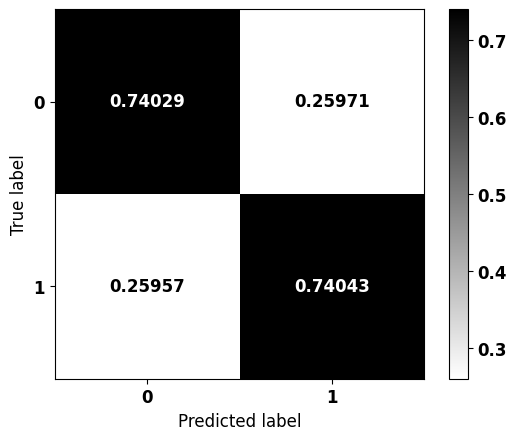


              precision    recall  f1-score   support

           0    0.47945   0.74029   0.58198      2033
           1    0.89825   0.74043   0.81174      6295

    accuracy                        0.74039      8328
   macro avg    0.68885   0.74036   0.69686      8328
weighted avg    0.79601   0.74039   0.75565      8328



In [ ]:
# XGBoost
xgb = XGBClassifier(max_depth=3,            # max_depth = 3
                    scale_pos_weight=0.298, # Peso da classe 1
                    random_state=seed)      # Reprodutibilidade

# Treinamento do modelo
xgb.fit(X_train, y_train)

# Matriz de confusão
plot_confusion_matrix(xgb, X_test, y_test)

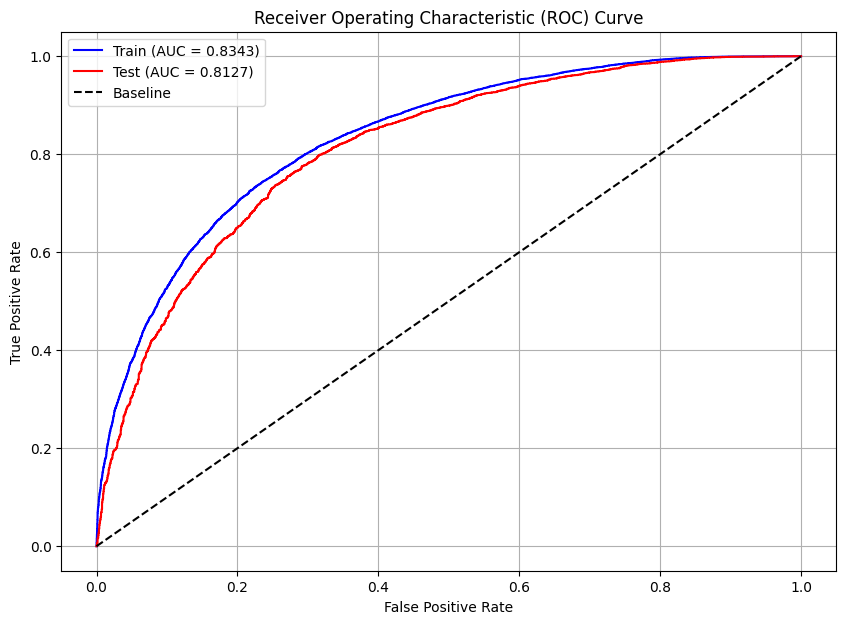

In [ ]:
# Curva ROC
plot_roc_curve(xgb, X_train, X_test, y_train, y_test)

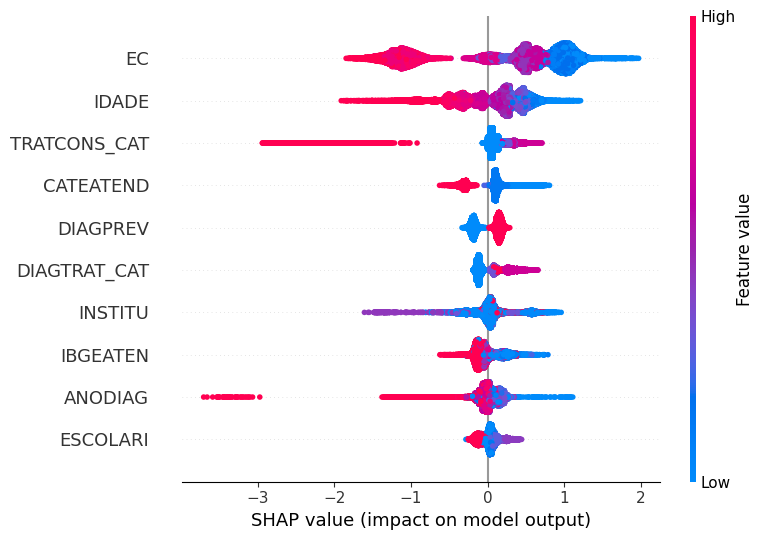

In [ ]:
# Importância pelo SHAP
plot_shap_values(xgb, X_train, feat_cols)

#### **Optuna**

In [ ]:
# Folds para validação cruzada
skf = StratifiedKFold(10, shuffle=True, random_state=seed)

# Função objetivo para otimização de hiperparâmetros
def objective(trial):

    # Define os hiperparâmetros que serão otimizados
    n_estimators = trial.suggest_int('n_estimators', 50, 150)  # Número de árvores
    max_depth = trial.suggest_int('max_depth', 2, 4)  # Profundidade máxima de cada árvore
    learning_rate = trial.suggest_float('learning_rate', 0.05, 0.2, step=0.05)  # Taxa de aprendizado
    gamma = trial.suggest_float('gamma', 0.0, 0.3, step=0.1)  # Termo de regularização
    min_child_weight = trial.suggest_int('min_child_weight', 1, 7)  # Mínimo peso para os nós filhos
    colsample_bytree = trial.suggest_float('colsample_bytree', 0.3, 0.7, step=0.1)  # Fração de features para cada árvore

    # Cria e treina o modelo com os hiperparâmetros escolhidos
    cls = XGBClassifier(n_estimators=n_estimators,
                        max_depth=max_depth,
                        learning_rate=learning_rate,
                        gamma=gamma,
                        min_child_weight=min_child_weight,
                        colsample_bytree=colsample_bytree,
                        random_state=seed,
                        n_jobs=-1)

    # Realiza a validação cruzada e retorna o valor médio de acurácia
    return cross_val_score(cls, X_train, y_train,
                           cv=skf, scoring='accuracy').mean()

**RandomSampler**

In [ ]:
# Otimização dos hiperparâmetros com Optuna - RandomSampler
studyXGB = optuna.create_study(direction='maximize', sampler=RandomSampler(seed))

# Inicia o estudo com 'n_trials'
studyXGB.optimize(objective, n_trials=150, n_jobs=-1)

In [ ]:
# Melhores hiperparâmetros encontrados
studyXGB.best_params

{'n_estimators': 109,
 'max_depth': 4,
 'learning_rate': 0.2,
 'gamma': 0.2,
 'min_child_weight': 3,
 'colsample_bytree': 0.4}

Best weight: 0.2951


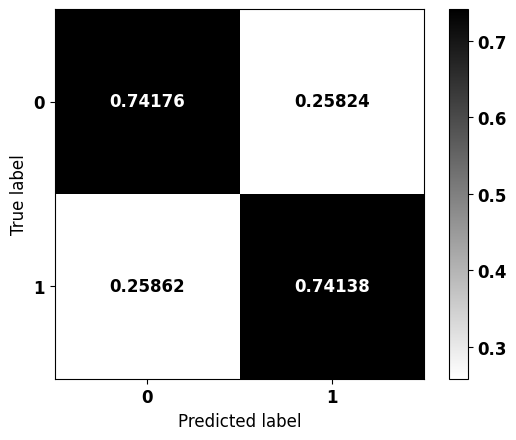


              precision    recall  f1-score   support

           0    0.48087   0.74176   0.58348      2033
           1    0.89888   0.74138   0.81257      6295

    accuracy                        0.74147      8328
   macro avg    0.68988   0.74157   0.69802      8328
weighted avg    0.79684   0.74147   0.75665      8328



In [ ]:
# Candidatos a scale_pos_weight após a busca por hiperparâmetros
pesos = np.round(np.arange(0.28, 0.31, 0.0001), 4)

# Salva os melhores hiperparâmetros e fixa o random_state
params = studyXGB.best_params
params['random_state'] = seed
mean, peso = 0, 0  # Média e peso

# Itera entre os candidatos a peso
for i in pesos:
    params['scale_pos_weight'] = i  # Atualiza o peso

    # Cria o modelo com os parâmetros
    xgb_optuna = XGBClassifier()
    xgb_optuna.set_params(**params)

    # Treino do modelo
    xgb_optuna.fit(X_train, y_train)

    # Predições no conjunto de teste
    y_pred = xgb_optuna.predict(X_test)

    # Matriz de confusão para calcular se houve ganho no ajuste do peso
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred, normalize='true').ravel()

    # Verifica se a diferença das diagonais principais é menor que 0.1% e se a média é maior
    if (abs(tn - tp) <= 0.001) and ((tn+tp)/2 > mean):
        peso = i
        mean = (tn+tp)/2
        best = xgb_optuna

if peso != 0:
    print(f'Best weight: {peso}')  # Print do melhor peso encontrado
    plot_confusion_matrix(best, X_test, y_test)  # Matriz de confusão

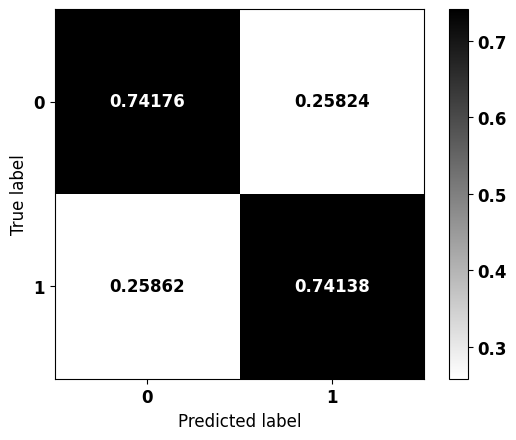


              precision    recall  f1-score   support

           0    0.48087   0.74176   0.58348      2033
           1    0.89888   0.74138   0.81257      6295

    accuracy                        0.74147      8328
   macro avg    0.68988   0.74157   0.69802      8328
weighted avg    0.79684   0.74147   0.75665      8328



In [ ]:
# Treino e validação com os melhores hiperparâmetros
params = studyXGB.best_params  # Salva os hiperparâmetros do estudo
params['random_state'] = seed  # Reprodutibilidade
params['scale_pos_weight'] = 0.2951  # Peso para a classe 1

# Criação do modelo com os parâmetros encontrados
xgb_rand = XGBClassifier()
xgb_rand.set_params(**params)

# Treinamento do modelo
xgb_rand.fit(X_train, y_train)

# Matriz de confusão do modelo otimizado
plot_confusion_matrix(xgb_rand, X_test, y_test)

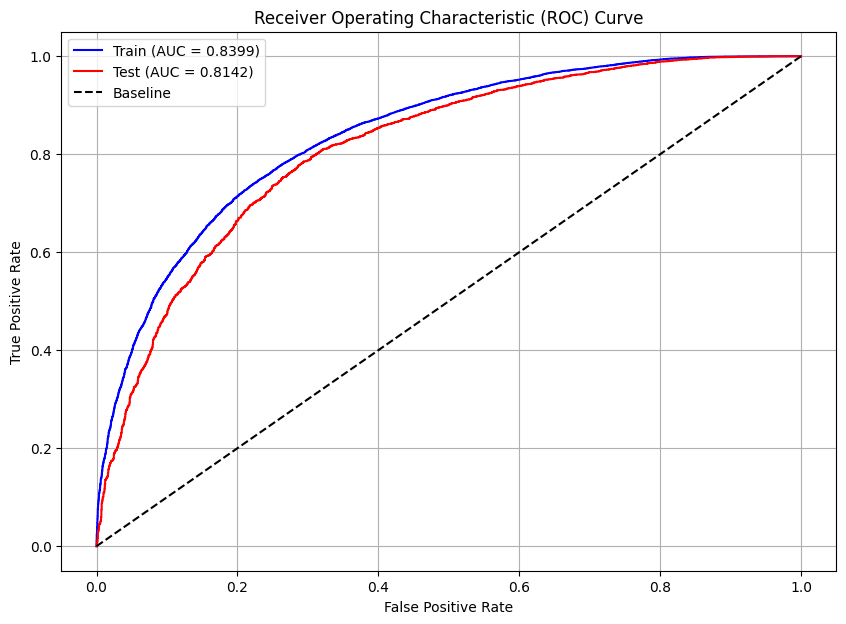

In [ ]:
# Curva ROC
plot_roc_curve(xgb_rand, X_train, X_test, y_train, y_test)

**TPESampler**

In [ ]:
# Otimização dos hiperparâmetros com Optuna - TPESampler
studyXGB = optuna.create_study(direction='maximize', sampler=TPESampler(seed=seed))

# Inicia o estudo com 'n_trials'
studyXGB.optimize(objective, n_trials=150, n_jobs=-1)

In [ ]:
# Melhores hiperparâmetros encontrados
studyXGB.best_params

{'n_estimators': 139,
 'max_depth': 3,
 'learning_rate': 0.2,
 'gamma': 0.2,
 'min_child_weight': 4,
 'colsample_bytree': 0.5}

Best weight: 0.2967


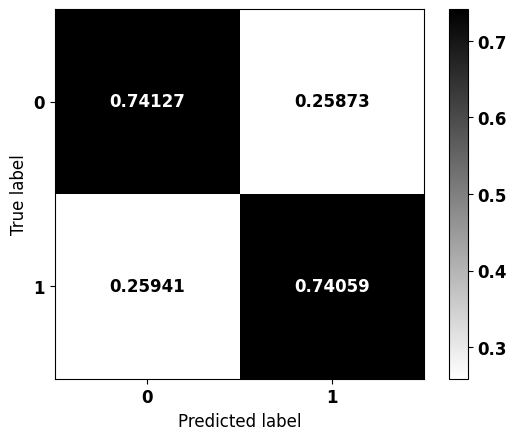


              precision    recall  f1-score   support

           0    0.47994   0.74127   0.58264      2033
           1    0.89861   0.74059   0.81198      6295

    accuracy                        0.74075      8328
   macro avg    0.68927   0.74093   0.69731      8328
weighted avg    0.79641   0.74075   0.75600      8328



In [ ]:
# Candidatos a scale_pos_weight após a busca por hiperparâmetros
pesos = np.round(np.arange(0.28, 0.31, 0.0001), 4)

# Salva os melhores hiperparâmetros e fixa o random_state
params = studyXGB.best_params
params['random_state'] = seed
mean, peso = 0, 0  # Média e peso

# Itera entre os candidatos a peso
for i in pesos:
    params['scale_pos_weight'] = i  # Atualiza o peso

    # Cria o modelo com os parâmetros
    xgb_optuna = XGBClassifier()
    xgb_optuna.set_params(**params)

    # Treino do modelo
    xgb_optuna.fit(X_train, y_train)

    # Predições no conjunto de teste
    y_pred = xgb_optuna.predict(X_test)

    # Matriz de confusão para calcular se houve ganho no ajuste do peso
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred, normalize='true').ravel()

    # Verifica se a diferença das diagonais principais é menor que 0.1% e se a média é maior
    if (abs(tn - tp) <= 0.001) and ((tn+tp)/2 > mean):
        peso = i
        mean = (tn+tp)/2
        best = xgb_optuna

if peso != 0:
    print(f'Best weight: {peso}')  # Print do melhor peso encontrado
    plot_confusion_matrix(best, X_test, y_test)  # Matriz de confusão

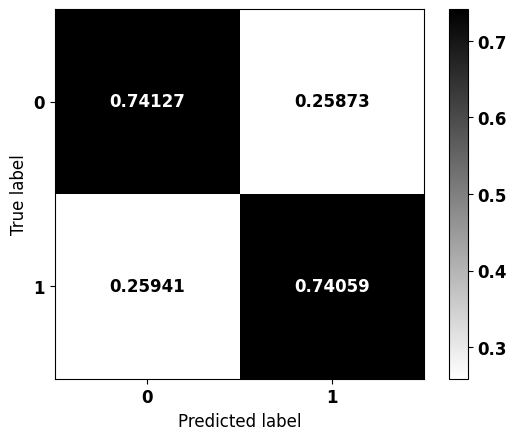


              precision    recall  f1-score   support

           0    0.47994   0.74127   0.58264      2033
           1    0.89861   0.74059   0.81198      6295

    accuracy                        0.74075      8328
   macro avg    0.68927   0.74093   0.69731      8328
weighted avg    0.79641   0.74075   0.75600      8328



In [ ]:
# Treino e validação com os melhores hiperparâmetros
params = studyXGB.best_params  # Salva os hiperparâmetros do estudo
params['random_state'] = seed  # Reprodutibilidade
params['scale_pos_weight'] = 0.2967  # Peso para a classe 1

# Criação do modelo com os parâmetros encontrados
xgb_tpe = XGBClassifier()
xgb_tpe.set_params(**params)

# Treinamento do modelo
xgb_tpe.fit(X_train, y_train)

# Matriz de confusão do modelo otimizado
plot_confusion_matrix(xgb_tpe, X_test, y_test)

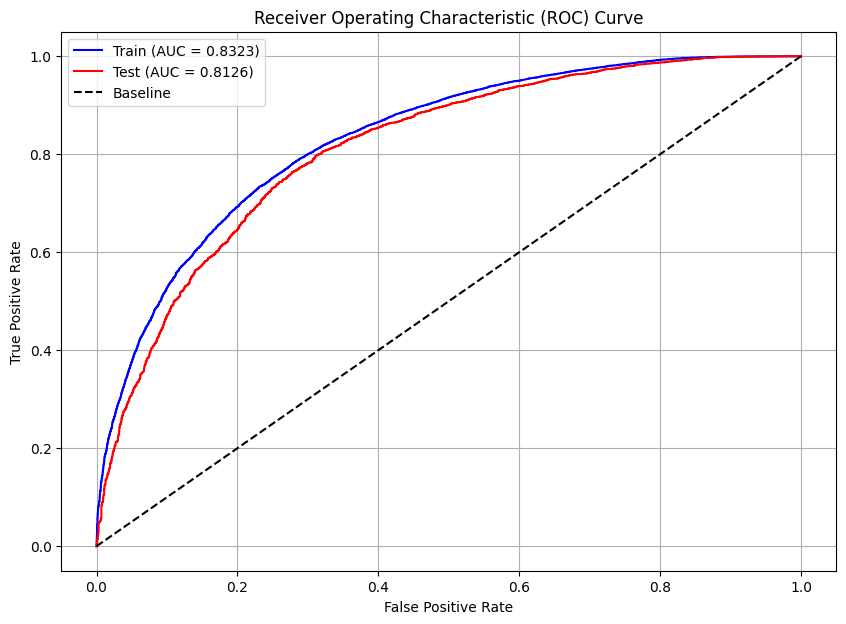

In [ ]:
# Curva ROC
plot_roc_curve(xgb_tpe, X_train, X_test, y_train, y_test)

**CmaEsSampler**

In [ ]:
# Otimização dos hiperparâmetros com Optuna - CmaEsSampler
studyXGB = optuna.create_study(direction='maximize', sampler=CmaEsSampler(seed=seed))

# Inicia o estudo com 'n_trials'
studyXGB.optimize(objective, n_trials=150, n_jobs=-1)

In [ ]:
# Melhores hiperparâmetros encontrados
studyXGB.best_params

{'n_estimators': 114,
 'max_depth': 4,
 'learning_rate': 0.2,
 'gamma': 0.2,
 'min_child_weight': 3,
 'colsample_bytree': 0.4}

Best weight: 0.3004


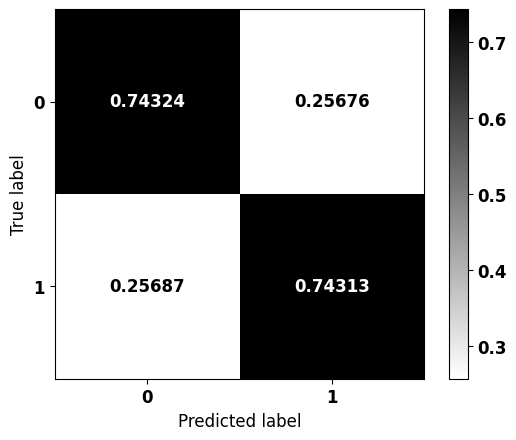


              precision    recall  f1-score   support

           0    0.48306   0.74324   0.58555      2033
           1    0.89962   0.74313   0.81392      6295

    accuracy                        0.74316      8328
   macro avg    0.69134   0.74318   0.69973      8328
weighted avg    0.79793   0.74316   0.75817      8328



In [ ]:
# Candidatos a scale_pos_weight após a busca por hiperparâmetros
pesos = np.round(np.arange(0.28, 0.31, 0.0001), 4)

# Salva os melhores hiperparâmetros e fixa o random_state
params = studyXGB.best_params
params['random_state'] = seed
mean, peso = 0, 0  # Média e peso

# Itera entre os candidatos a peso
for i in pesos:
    params['scale_pos_weight'] = i  # Atualiza o peso

    # Cria o modelo com os parâmetros
    xgb_optuna = XGBClassifier()
    xgb_optuna.set_params(**params)

    # Treino do modelo
    xgb_optuna.fit(X_train, y_train)

    # Predições no conjunto de teste
    y_pred = xgb_optuna.predict(X_test)

    # Matriz de confusão para calcular se houve ganho no ajuste do peso
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred, normalize='true').ravel()

    # Verifica se a diferença das diagonais principais é menor que 0.1% e se a média é maior
    if (abs(tn - tp) <= 0.001) and ((tn+tp)/2 > mean):
        peso = i
        mean = (tn+tp)/2
        best = xgb_optuna

if peso != 0:
    print(f'Best weight: {peso}')  # Print do melhor peso encontrado
    plot_confusion_matrix(best, X_test, y_test)  # Matriz de confusão

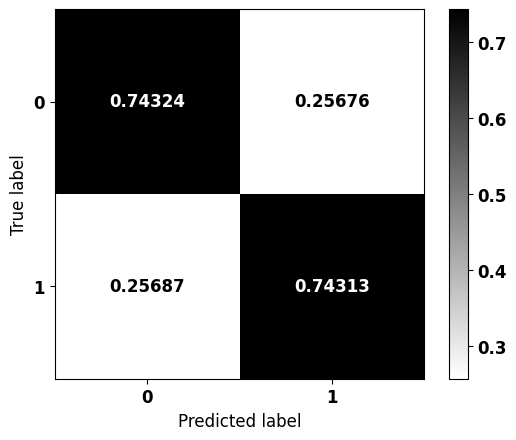


              precision    recall  f1-score   support

           0    0.48306   0.74324   0.58555      2033
           1    0.89962   0.74313   0.81392      6295

    accuracy                        0.74316      8328
   macro avg    0.69134   0.74318   0.69973      8328
weighted avg    0.79793   0.74316   0.75817      8328



In [ ]:
# Treino e validação com os melhores hiperparâmetros
params = studyXGB.best_params  # Salva os hiperparâmetros do estudo
params['random_state'] = seed  # Reprodutibilidade
params['scale_pos_weight'] = 0.3004  # Peso para a classe 1

# Criação do modelo com os parâmetros encontrados
xgb_cma = XGBClassifier()
xgb_cma.set_params(**params)

# Treinamento do modelo
xgb_cma.fit(X_train, y_train)

# Matriz de confusão do modelo otimizado
plot_confusion_matrix(xgb_cma, X_test, y_test)

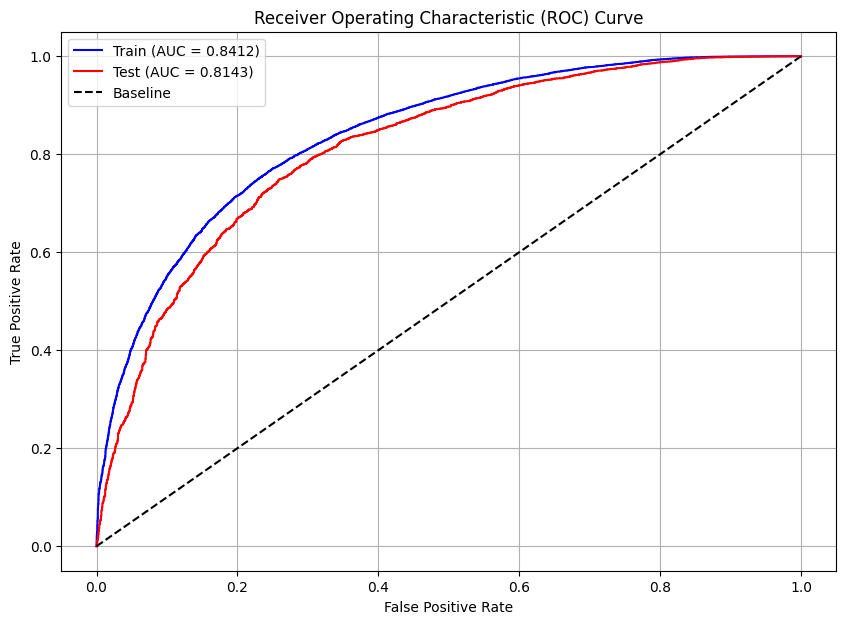

In [ ]:
# Curva ROC
plot_roc_curve(xgb_cma, X_train, X_test, y_train, y_test)

**Modelo Otimizado**

In [ ]:
# Seleção do melhor modelo
models = [xgb_rand, xgb_tpe, xgb_cma]  # Lista dos modelos
best = models[0]

# Itera entre os modelos para encontrar o com maior acurácia
for i, m in enumerate(models):
    if i == 0:
        continue

    best_score = best.score(X_test, y_test)  # Acurácia do melhor modelo
    score = m.score(X_test, y_test)  # Acurácia do modelo atual

    if score > best_score:  # Atualiza o melhor modelo se a acurácia for maior
        best = m

# Print do melhor modelo selecionado
print(best)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.4, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=0.2, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.2, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=3, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=114, n_jobs=None,
              num_parallel_tree=None, random_state=1, ...)


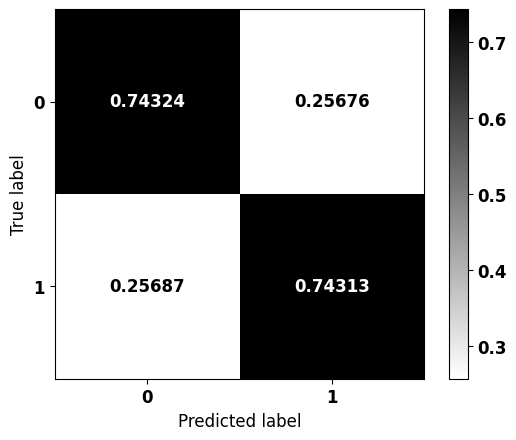


              precision    recall  f1-score   support

           0    0.48306   0.74324   0.58555      2033
           1    0.89962   0.74313   0.81392      6295

    accuracy                        0.74316      8328
   macro avg    0.69134   0.74318   0.69973      8328
weighted avg    0.79793   0.74316   0.75817      8328



In [ ]:
# Treinamento do modelo final com os melhores hiperparâmetros
params = best.get_params()

# Inicializa o modelo final
xgb_optuna = XGBClassifier()
xgb_optuna.set_params(**params)

# Treinamento do modelo otimizado
xgb_optuna.fit(X_train, y_train)

# Plot da matriz de confusão para o conjunto de teste
plot_confusion_matrix(xgb_optuna, X_test, y_test)

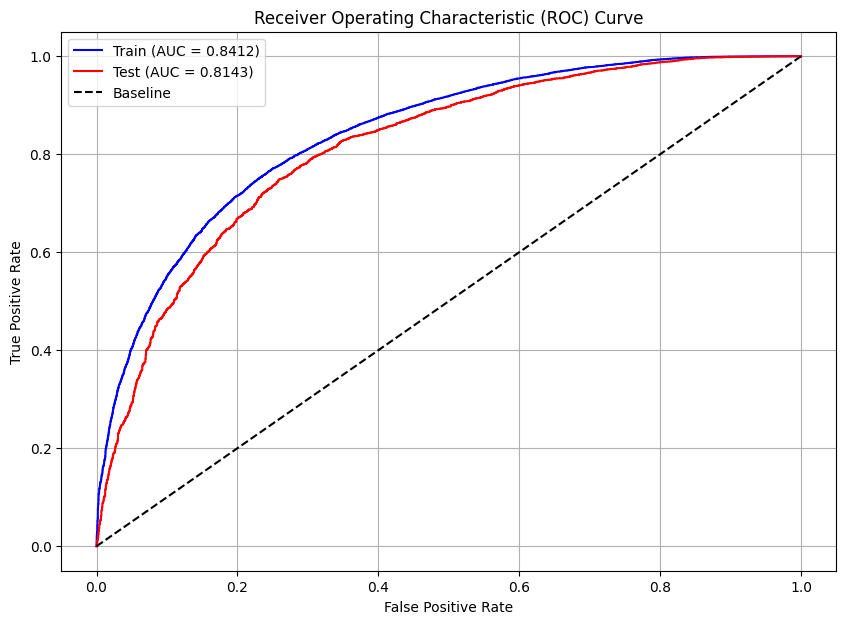

In [ ]:
# Curva ROC
plot_roc_curve(xgb_optuna, X_train, X_test, y_train, y_test)

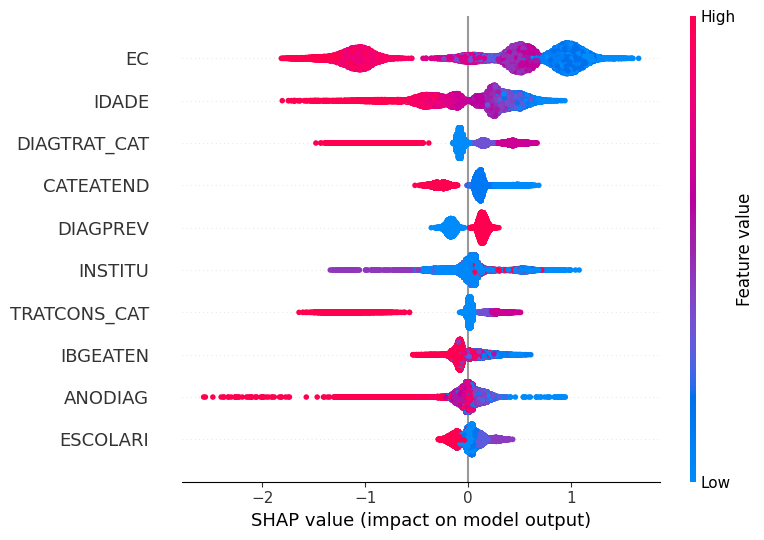

In [ ]:
# Importância das features pelo SHAP
plot_shap_values(xgb_optuna, X_train, feat_cols)

### **LightGBM**


#### **Baseline**

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


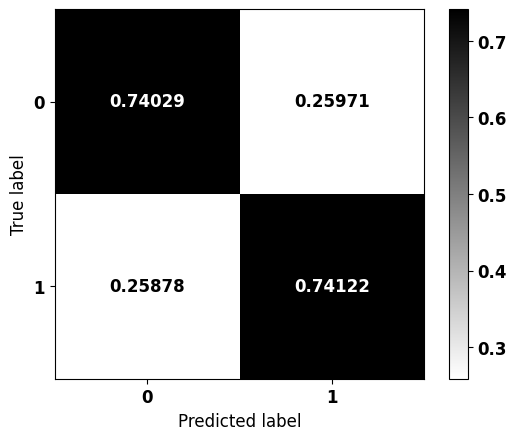


              precision    recall  f1-score   support

           0    0.48022   0.74029   0.58254      2033
           1    0.89834   0.74122   0.81226      6295

    accuracy                        0.74099      8328
   macro avg    0.68928   0.74075   0.69740      8328
weighted avg    0.79627   0.74099   0.75618      8328



/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


In [ ]:
# Cria e treina o modelo LightGBM

# Inicializa o classificador LightGBM com os parâmetros especificados
lgbm = LGBMClassifier(
    max_depth=5,                     # Define a profundidade máxima das árvores
    class_weight={0: 3.4393, 1: 1}, # Ajusta o peso das classes para lidar com o desbalanceamento
    random_state=seed,              # Garante a reprodutibilidade dos resultados
    verbose=-1                       # Desativa as mensagens de saída durante o treinamento
)

# Treina o modelo utilizando o conjunto de dados de treinamento
lgbm.fit(X_train, y_train)

# Matriz de confusão

# Gera e exibe a matriz de confusão para avaliar as classificações
# realizadas pelo modelo no conjunto de teste
plot_confusion_matrix(lgbm, X_test, y_test)

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


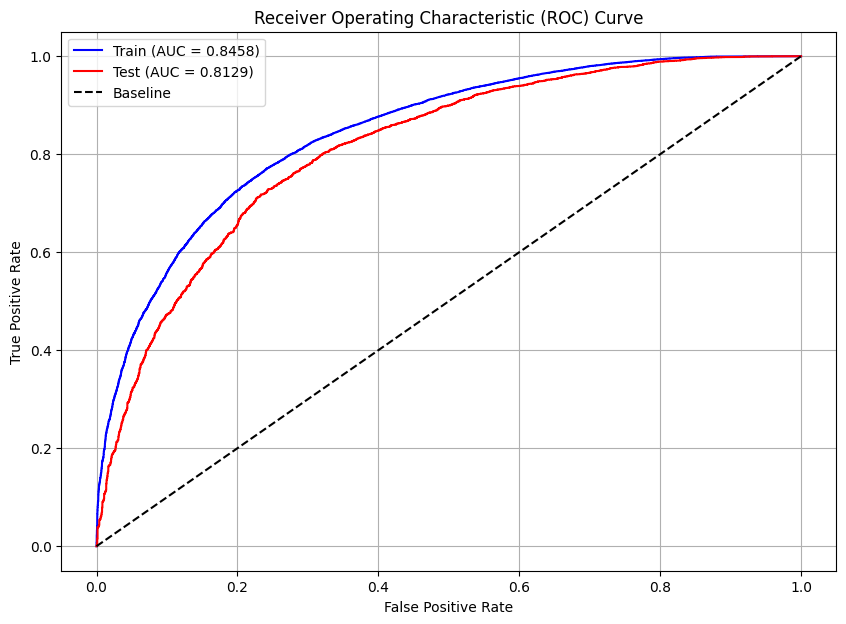

In [ ]:
# Curva ROC
plot_roc_curve(lgbm, X_train, X_test, y_train, y_test)

/usr/local/lib/python3.11/dist-packages/shap/explainers/_tree.py:583: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


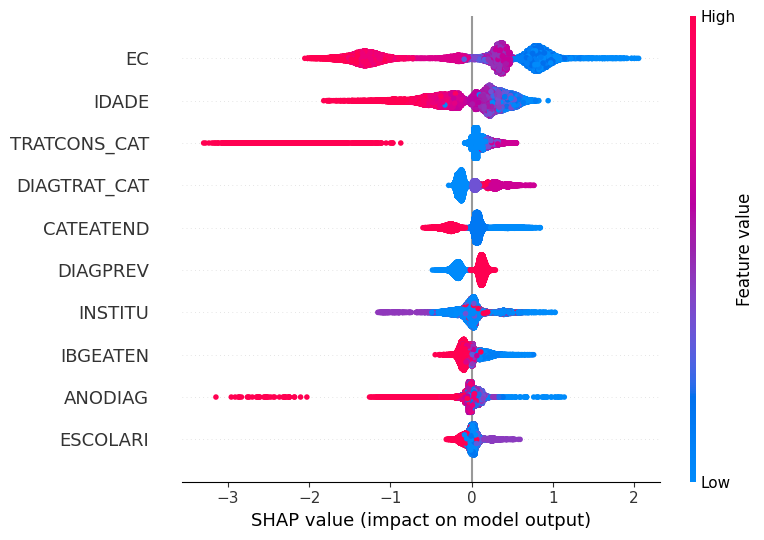

In [ ]:
# Importância pelo SHAP
plot_shap_values(lgbm, X_train, feat_cols)

#### **Optuna**

In [ ]:
# Cria os folds estratificados, mantendo aproximadamente a mesma proporção
# de classes em cada divisão dos dados
skf = StratifiedKFold(10, shuffle=True, random_state=seed)

# Define a função objetivo utilizada pelo Optuna para otimizar
# os hiperparâmetros do modelo LightGBM
def objective(trial):

    # Define o espaço de busca dos hiperparâmetros
    # Número de árvores utilizadas pelo modelo
    n_estimators = trial.suggest_int('n_estimators', 50, 150)

    # Profundidade máxima das árvores
    max_depth = trial.suggest_int('max_depth', 3, 6)

    # Taxa de aprendizado utilizada durante o treinamento
    learning_rate = trial.suggest_float('learning_rate', 0.05, 0.2, step=0.01)

    # Soma mínima dos pesos necessária para criar um novo nó filho
    min_child_weight = trial.suggest_int('min_child_weight', 1, 7)

    # Proporção de variáveis selecionadas aleatoriamente para cada árvore
    colsample_bytree = trial.suggest_float('colsample_bytree', 0.3, 0.7, step=0.1)

    # Inicializa o classificador LightGBM com os hiperparâmetros
    # selecionados pelo Optuna na iteração atual
    cls = LGBMClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        learning_rate=learning_rate,
        min_child_weight=min_child_weight,
        colsample_bytree=colsample_bytree,
        random_state=seed,
        verbose=-1,
        n_jobs=-1
    )

    # Realiza validação cruzada estratificada e retorna a média
    # da acurácia obtida nos 10 folds.
    # O Optuna utiliza esse valor como função objetivo para selecionar
    # a combinação de hiperparâmetros com melhor desempenho.
    return cross_val_score(cls, X_train, y_train, cv=skf, scoring='accuracy').mean()

**RandomSampler**

In [ ]:
# Otimização dos hiperparâmetros com Optuna - RandomSampler
studyLGBM = optuna.create_study(direction='maximize', sampler=RandomSampler(seed))

# Inicia o estudo com 'n_trials'
studyLGBM.optimize(objective, n_trials=150, n_jobs=-1)

In [ ]:
# Melhores hiperparâmetros encontrados
studyLGBM.best_params

{'n_estimators': 141,
 'max_depth': 4,
 'learning_rate': 0.2,
 'min_child_weight': 3,
 'colsample_bytree': 0.3}

Best weight: 3.377


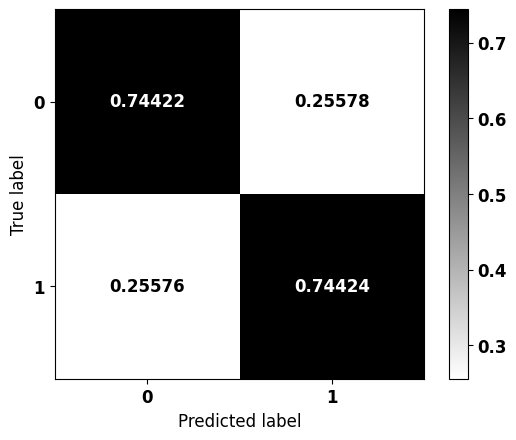


              precision    recall  f1-score   support

           0    0.48447   0.74422   0.58689      2033
           1    0.90010   0.74424   0.81478      6295

    accuracy                        0.74424      8328
   macro avg    0.69228   0.74423   0.70084      8328
weighted avg    0.79864   0.74424   0.75915      8328



In [ ]:
# Candidatos a class_weight após a busca por hiperparâmetros
pesos = np.round(np.arange(3.2, 3.4, 0.001), 3)

# Salva os melhores hiperparâmetros e fixa o random_state
params = studyLGBM.best_params
params['random_state'] = seed
mean, peso = 0, 0  # Média e peso

# Itera entre os candidatos a peso
for i in pesos:
    params['class_weight'] = {0:i, 1:1}  # Atualiza o peso

    # Cria o modelo com os parâmetros
    lgbm_optuna = LGBMClassifier(verbose=-1)
    lgbm_optuna.set_params(**params)

    # Treino do modelo
    lgbm_optuna.fit(X_train, y_train)

    # Predições no conjunto de teste
    y_pred = lgbm_optuna.predict(X_test)

    # Matriz de confusão para calcular se houve ganho no ajuste do peso
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred, normalize='true').ravel()

    # Verifica se a diferença das diagonais principais é menor que 0.1% e se a média é maior
    if (abs(tn - tp) <= 0.001) and ((tn+tp)/2 > mean):
        peso = i
        mean = (tn+tp)/2
        best = lgbm_optuna

if peso != 0:
    print(f'Best weight: {peso}')  # Print do melhor peso encontrado
    plot_confusion_matrix(best, X_test, y_test)  # Matriz de confusão

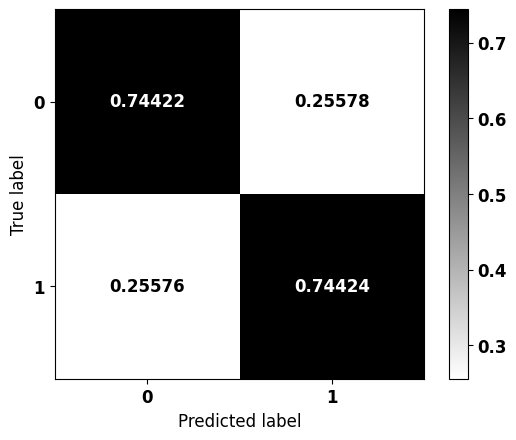


              precision    recall  f1-score   support

           0    0.48447   0.74422   0.58689      2033
           1    0.90010   0.74424   0.81478      6295

    accuracy                        0.74424      8328
   macro avg    0.69228   0.74423   0.70084      8328
weighted avg    0.79864   0.74424   0.75915      8328



In [ ]:
# Treino e validação com os melhores hiperparâmetros
params = studyLGBM.best_params  # Salva os hiperparâmetros do estudo
params['random_state'] = seed  # Reprodutibilidade
params['class_weight'] = {0:3.377, 1:1}  # Peso para a classe 0

# Criação do modelo com os parâmetros encontrados
lgbm_rand = LGBMClassifier(verbose=-1)
lgbm_rand.set_params(**params)

# Treinamento do modelo
lgbm_rand.fit(X_train, y_train)

# Matriz de confusão do modelo otimizado
plot_confusion_matrix(lgbm_rand, X_test, y_test)

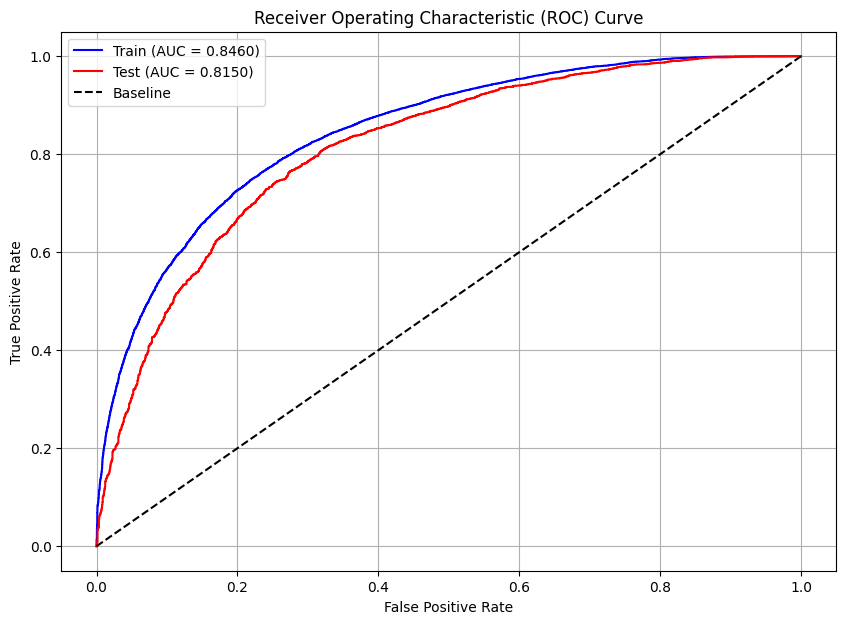

In [ ]:
# Curva ROC
plot_roc_curve(lgbm_rand, X_train, X_test, y_train, y_test)

**TPESampler**

In [ ]:
# Otimização dos hiperparâmetros com Optuna - TPESampler
studyLGBM = optuna.create_study(direction='maximize', sampler=TPESampler(seed=seed))

# Inicia o estudo com 'n_trials'
studyLGBM.optimize(objective, n_trials=150, n_jobs=-1)

In [ ]:
# Melhores hiperparâmetros encontrados
studyLGBM.best_params

{'n_estimators': 93,
 'max_depth': 6,
 'learning_rate': 0.2,
 'min_child_weight': 5,
 'colsample_bytree': 0.3}

Best weight: 3.306


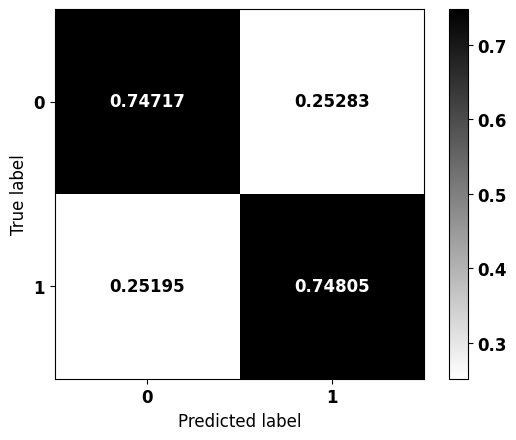


              precision    recall  f1-score   support

           0    0.48921   0.74717   0.59128      2033
           1    0.90159   0.74805   0.81768      6295

    accuracy                        0.74784      8328
   macro avg    0.69540   0.74761   0.70448      8328
weighted avg    0.80092   0.74784   0.76241      8328



In [ ]:
# Candidatos a class_weight após a busca por hiperparâmetros
pesos = np.round(np.arange(3.2, 3.5, 0.001), 3)

# Salva os melhores hiperparâmetros e fixa o random_state
params = studyLGBM.best_params
params['random_state'] = seed
mean, peso = 0, 0  # Média e peso

# Itera entre os candidatos a peso
for i in pesos:
    params['class_weight'] = {0:i, 1:1}  # Atualiza o peso

    # Cria o modelo com os parâmetros
    lgbm_optuna = LGBMClassifier(verbose=-1)
    lgbm_optuna.set_params(**params)

    # Treino do modelo
    lgbm_optuna.fit(X_train, y_train)

    # Predições no conjunto de teste
    y_pred = lgbm_optuna.predict(X_test)

    # Matriz de confusão para calcular se houve ganho no ajuste do peso
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred, normalize='true').ravel()

    # Verifica se a diferença das diagonais principais é menor que 0.1% e se a média é maior
    if (abs(tn - tp) <= 0.001) and ((tn+tp)/2 > mean):
        peso = i
        mean = (tn+tp)/2
        best = lgbm_optuna

if peso != 0:
    print(f'Best weight: {peso}')  # Print do melhor peso encontrado
    plot_confusion_matrix(best, X_test, y_test)  # Matriz de confusão

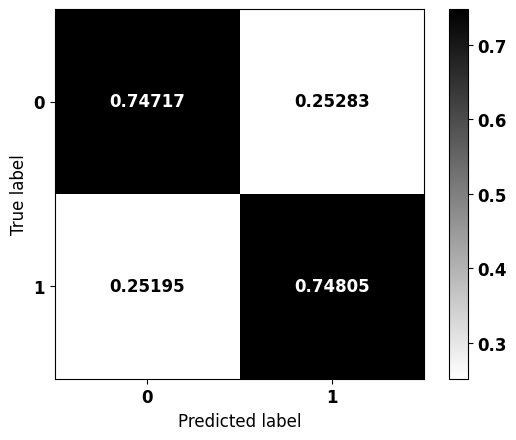


              precision    recall  f1-score   support

           0    0.48921   0.74717   0.59128      2033
           1    0.90159   0.74805   0.81768      6295

    accuracy                        0.74784      8328
   macro avg    0.69540   0.74761   0.70448      8328
weighted avg    0.80092   0.74784   0.76241      8328



In [ ]:
# Treino e validação com os melhores hiperparâmetros
params = studyLGBM.best_params  # Salva os hiperparâmetros do estudo
params['random_state'] = seed  # Reprodutibilidade
params['class_weight'] = {0:3.306, 1:1}  # Peso para a classe 0

# Criação do modelo com os parâmetros encontrados
lgbm_tpe = LGBMClassifier(verbose=-1)
lgbm_tpe.set_params(**params)

# Treinamento do modelo
lgbm_tpe.fit(X_train, y_train)

# Matriz de confusão do modelo otimizado
plot_confusion_matrix(lgbm_tpe, X_test, y_test)

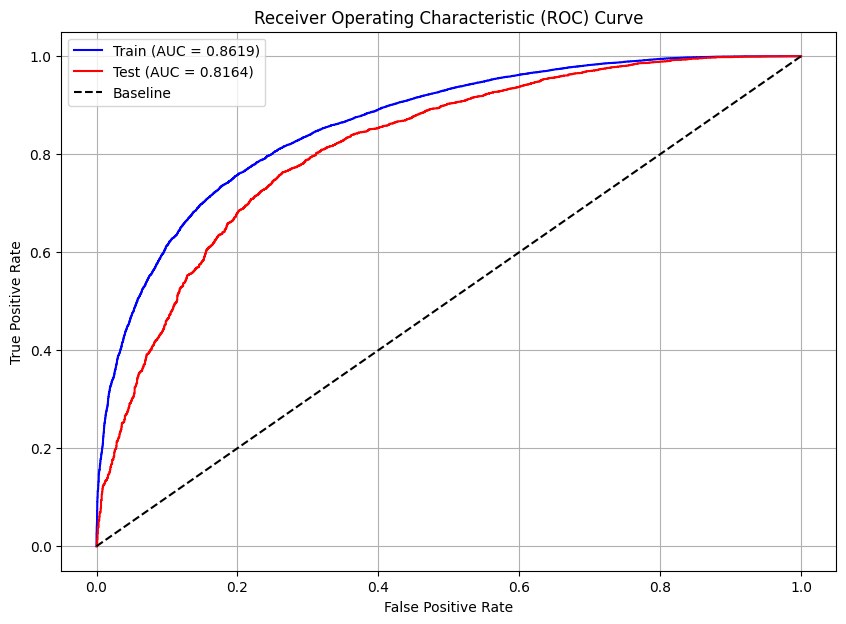

In [ ]:
# Curva ROC
plot_roc_curve(lgbm_tpe, X_train, X_test, y_train, y_test)

**CmaEsSampler**

In [ ]:
# Otimização dos hiperparâmetros com Optuna - CmaEsSampler
studyLGBM = optuna.create_study(direction='maximize', sampler=CmaEsSampler(seed=seed))

# Inicia o estudo com 'n_trials'
studyLGBM.optimize(objective, n_trials=150, n_jobs=-1)

In [ ]:
# Melhores hiperparâmetros encontrados
studyLGBM.best_params

{'n_estimators': 98,
 'max_depth': 5,
 'learning_rate': 0.15000000000000002,
 'min_child_weight': 4,
 'colsample_bytree': 0.5}

Best weight: 3.423


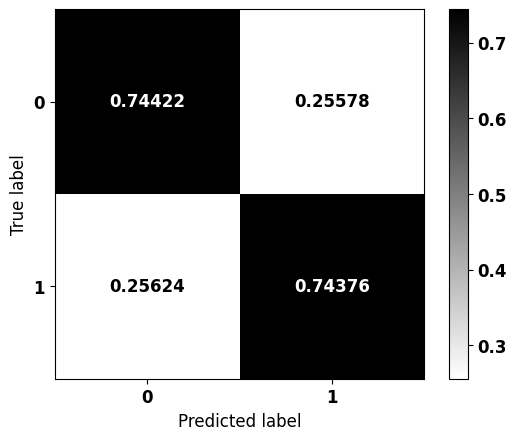


              precision    recall  f1-score   support

           0    0.48401   0.74422   0.58655      2033
           1    0.90004   0.74376   0.81447      6295

    accuracy                        0.74388      8328
   macro avg    0.69202   0.74399   0.70051      8328
weighted avg    0.79848   0.74388   0.75883      8328



In [ ]:
# Candidatos a class_weight após a busca por hiperparâmetros
pesos = np.round(np.arange(3.2, 3.5, 0.001), 3)

# Salva os melhores hiperparâmetros e fixa o random_state
params = studyLGBM.best_params
params['random_state'] = seed
mean, peso = 0, 0  # Média e peso

# Itera entre os candidatos a peso
for i in pesos:
    params['class_weight'] = {0:i, 1:1}  # Atualiza o peso

    # Cria o modelo com os parâmetros
    lgbm_optuna = LGBMClassifier(verbose=-1)
    lgbm_optuna.set_params(**params)

    # Treino do modelo
    lgbm_optuna.fit(X_train, y_train)

    # Predições no conjunto de teste
    y_pred = lgbm_optuna.predict(X_test)

    # Matriz de confusão para calcular se houve ganho no ajuste do peso
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred, normalize='true').ravel()

    # Verifica se a diferença das diagonais principais é menor que 0.1% e se a média é maior
    if (abs(tn - tp) <= 0.001) and ((tn+tp)/2 > mean):
        peso = i
        mean = (tn+tp)/2
        best = lgbm_optuna

if peso != 0:
    print(f'Best weight: {peso}')  # Print do melhor peso encontrado
    plot_confusion_matrix(best, X_test, y_test)  # Matriz de confusão

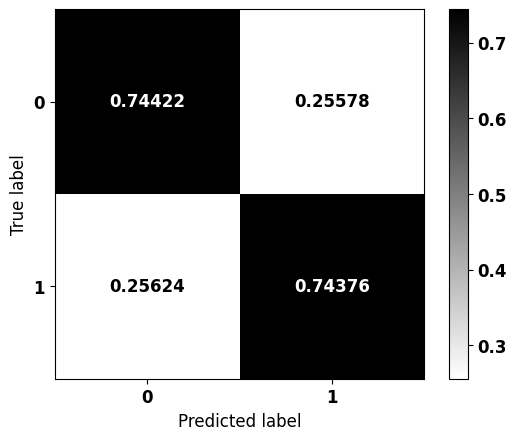


              precision    recall  f1-score   support

           0    0.48401   0.74422   0.58655      2033
           1    0.90004   0.74376   0.81447      6295

    accuracy                        0.74388      8328
   macro avg    0.69202   0.74399   0.70051      8328
weighted avg    0.79848   0.74388   0.75883      8328



In [ ]:
# Treino e validação com os melhores hiperparâmetros
params = studyLGBM.best_params  # Salva os hiperparâmetros do estudo
params['random_state'] = seed  # Reprodutibilidade
params['class_weight'] = {0:3.423, 1:1}  # Peso para a classe 0

# Criação do modelo com os parâmetros encontrados
lgbm_cma = LGBMClassifier(verbose=-1)
lgbm_cma.set_params(**params)

# Treinamento do modelo
lgbm_cma.fit(X_train, y_train)

# Matriz de confusão do modelo otimizado
plot_confusion_matrix(lgbm_cma, X_test, y_test)

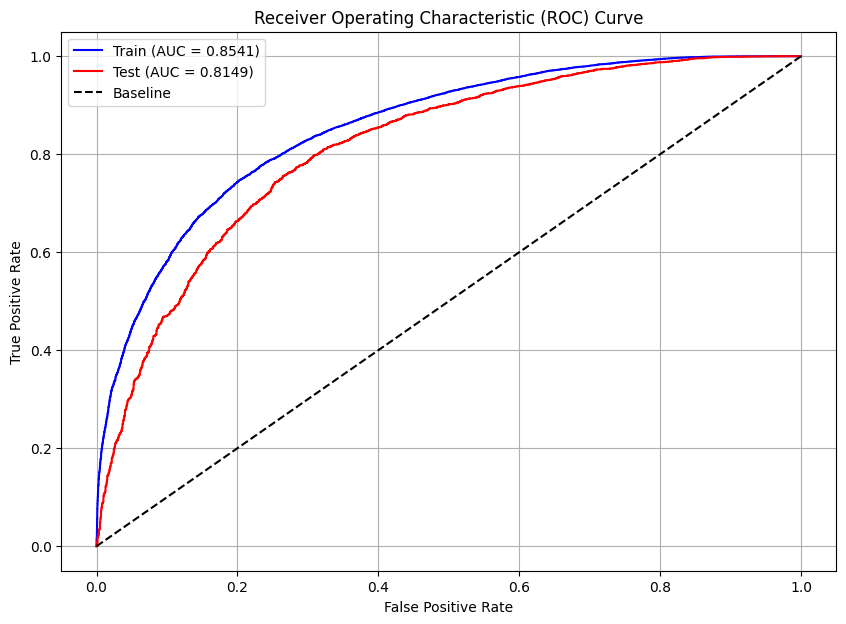

In [ ]:
# Curva ROC
plot_roc_curve(lgbm_cma, X_train, X_test, y_train, y_test)

**Modelo otimizado**

In [ ]:
# Seleção do melhor modelo
models = [lgbm_rand, lgbm_tpe, lgbm_cma]  # Lista dos modelos
best = models[0]

# Itera entre os modelos para encontrar o com maior acurácia
for i, m in enumerate(models):
    if i == 0:
        continue

    best_score = best.score(X_test, y_test)  # Acurácia do melhor modelo
    score = m.score(X_test, y_test)  # Acurácia do modelo atual

    if score > best_score:  # Atualiza o melhor modelo se a acurácia for maior
        best = m

# Print do melhor modelo selecionado
print(best)

LGBMClassifier(class_weight={0: 3.306, 1: 1}, colsample_bytree=0.3,
               learning_rate=0.2, max_depth=6, min_child_weight=5,
               n_estimators=93, random_state=1, verbose=-1)


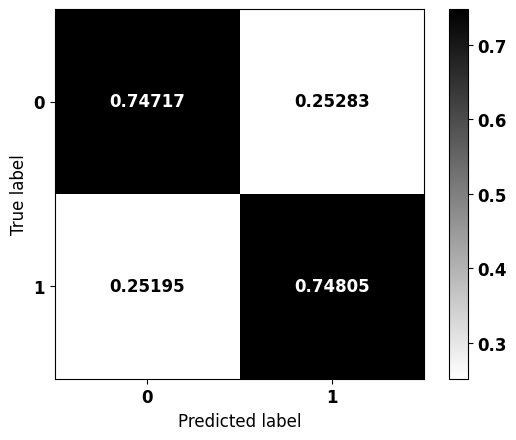


              precision    recall  f1-score   support

           0    0.48921   0.74717   0.59128      2033
           1    0.90159   0.74805   0.81768      6295

    accuracy                        0.74784      8328
   macro avg    0.69540   0.74761   0.70448      8328
weighted avg    0.80092   0.74784   0.76241      8328



In [ ]:
# Treinamento do modelo final com os melhores hiperparâmetros
params = best.get_params()

# Inicializa o modelo final
lgbm_optuna = LGBMClassifier(verbose=-1)
lgbm_optuna.set_params(**params)

# Treinamento do modelo otimizado
lgbm_optuna.fit(X_train, y_train)

# Plot da matriz de confusão para o conjunto de teste
plot_confusion_matrix(lgbm_optuna, X_test, y_test)

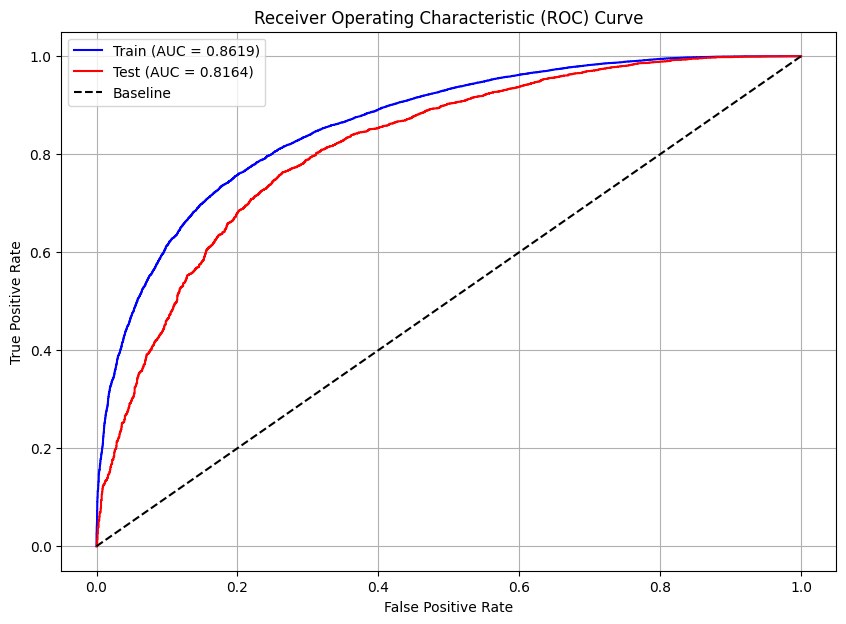

In [ ]:
# Curva ROC
plot_roc_curve(lgbm_optuna, X_train, X_test, y_train, y_test)

/usr/local/lib/python3.11/dist-packages/shap/explainers/_tree.py:583: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


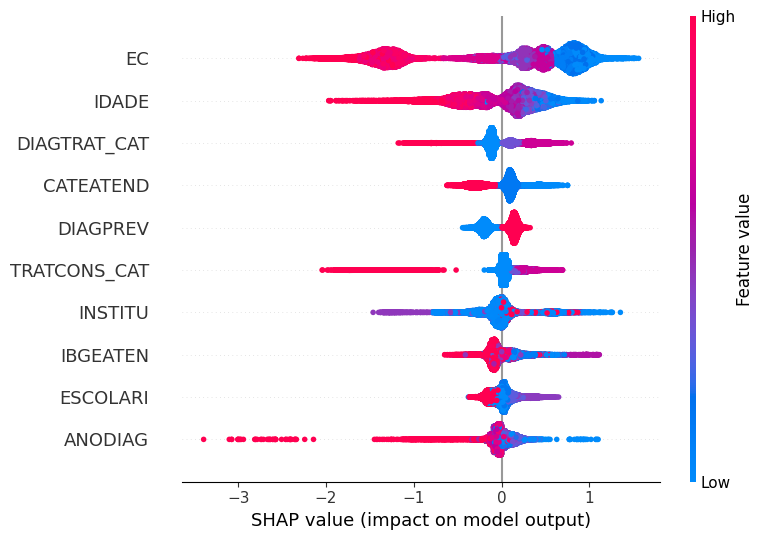

In [ ]:
# Importância das features pelo SHAP
plot_shap_values(lgbm_optuna, X_train, feat_cols)

## **Voting Classifier**


In [ ]:
# Compara as acurácias do modelo XGBoost inicial e do modelo
# otimizado pelo Optuna no conjunto de teste
xgb_score = xgb.score(X_test, y_test)
optuna_score = xgb_optuna.score(X_test, y_test)

# Exibe a acurácia de cada modelo com quatro casas decimais
print(f'Accuracy: XGB = {xgb_score:.4f}, Optuna = {optuna_score:.4f}\n')

# Verifica qual dos dois modelos apresentou o melhor desempenho

# Caso o modelo otimizado pelo Optuna apresente acurácia maior ou igual
# à do modelo inicial, seleciona o modelo otimizado
if optuna_score >= xgb_score:
    # Obtém os hiperparâmetros do modelo otimizado
    params_xgb = xgb_optuna.get_params()

    # Informa que o modelo otimizado apresentou o melhor desempenho
    print('Optimized model won')

else:
    # Caso contrário, obtém os hiperparâmetros do modelo inicial
    params_xgb = xgb.get_params()

    # Informa que o modelo inicial apresentou o melhor desempenho
    print('Initial model won')

Accuracy: XGB = 0.7404, Optuna = 0.7432

Optimized model won


In [ ]:
# Compara as acurácias do modelo LightGBM inicial e do modelo
# otimizado pelo Optuna no conjunto de teste
lgbm_score = lgbm.score(X_test, y_test)
optuna_score = lgbm_optuna.score(X_test, y_test)

# Exibe a acurácia de cada modelo com quatro casas decimais
print(f'Accuracy: LGBM = {lgbm_score:.4f}, Optuna = {optuna_score:.4f}\n')

# Verifica qual dos dois modelos apresentou o melhor desempenho

# Caso o modelo otimizado pelo Optuna apresente acurácia maior ou igual
# à do modelo inicial, seleciona o modelo otimizado
if optuna_score >= lgbm_score:
    # Obtém os hiperparâmetros do modelo otimizado pelo Optuna
    params_lgbm = lgbm_optuna.get_params()

    # Informa que o modelo otimizado apresentou o melhor desempenho
    print('Optimized model won')

else:
    # Caso contrário, obtém os hiperparâmetros do modelo LightGBM inicial
    params_lgbm = lgbm.get_params()

    # Informa que o modelo inicial apresentou o melhor desempenho
    print('Initial model won')

Accuracy: LGBM = 0.7410, Optuna = 0.7478

Optimized model won


In [ ]:
# Cria os modelos utilizando os hiperparâmetros que apresentaram
# o melhor desempenho durante o processo de avaliação

# Modelo XGBoost
# Inicializa o classificador XGBoost
best_xgb = XGBClassifier()

# Define os melhores hiperparâmetros selecionados para o modelo XGBoost
best_xgb.set_params(**params_xgb)

# Modelo LightGBM
# Inicializa o classificador LightGBM
best_lgbm = LGBMClassifier()

# Define os melhores hiperparâmetros selecionados para o modelo LightGBM
best_lgbm.set_params(**params_lgbm)

LGBMClassifier(class_weight={0: 3.306, 1: 1}, colsample_bytree=0.3,
               learning_rate=0.2, max_depth=6, min_child_weight=5,
               n_estimators=93, random_state=1, verbose=-1)

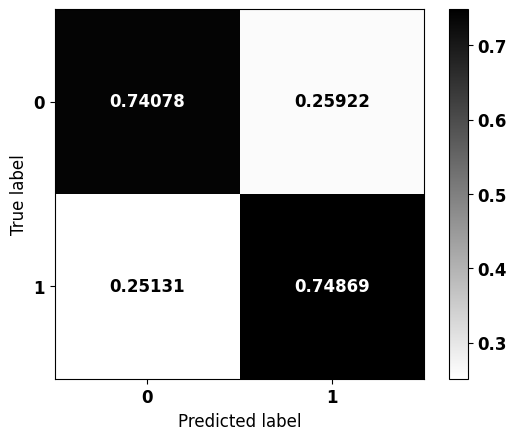


              precision    recall  f1-score   support

           0    0.48769   0.74078   0.58817      2033
           1    0.89943   0.74869   0.81717      6295

    accuracy                        0.74676      8328
   macro avg    0.69356   0.74473   0.70267      8328
weighted avg    0.79892   0.74676   0.76126      8328



In [ ]:
# Importa o classificador de votação da biblioteca scikit-learn
from sklearn.ensemble import VotingClassifier

# Cria o classificador de votação utilizando os modelos
# XGBoost e LightGBM com melhor desempenho
clf = VotingClassifier(
    estimators=[
        # Adiciona o modelo XGBoost com os melhores hiperparâmetros
        ('XGBoost', best_xgb),
        # Adiciona o modelo LightGBM com os melhores hiperparâmetros
        ('LightGBM', best_lgbm)
    ],
    # Utiliza votação ponderada pelas probabilidades previstas pelos modelos.
    # A classe final é determinada pela maior probabilidade média entre os modelos.
    voting='soft'
)

# Treina o classificador de votação utilizando o conjunto de treinamento
clf.fit(X_train, y_train)

# Matriz de confusão
# Gera e exibe a matriz de confusão para avaliar o desempenho
# do classificador de votação no conjunto de teste
plot_confusion_matrix(clf, X_test, y_test)

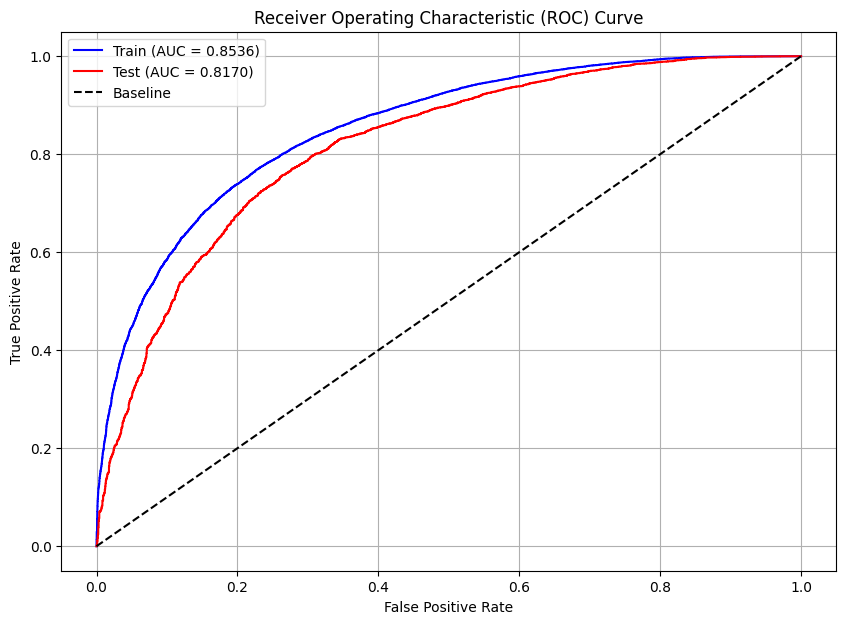

In [ ]:
# Curva ROC
plot_roc_curve(clf, X_train, X_test, y_train, y_test)

# **Sobrevida de 3 anos**

## **Treino e Teste**



In [ ]:
# Conjunto de dados de colorretal
!gdown 1yzI52UDZyac0QGWmKL5Mai1JOqWUTeMQ --quiet

In [ ]:
# Leitura dos dados
df_colo = pd.read_csv('colorretal.csv')
print(df_colo.shape)
df_colo.head(3)

(44857, 49)


,INSTITU,ESCOLARI,IDADE,SEXO,IBGE,CATEATEND,DIAGPREV,TOPO,EC,ECGRUP,...,TRATCONS_CAT,DIAGTRAT_CAT,PRESENCA_META,PRESENCA_REC,obito_geral,obito_cancer,sobrevida_ano1,sobrevida_ano3,sobrevida_ano5,meses_diag
0,612374,9,91,2,3550308,2,2,C209,IIA,II,...,0,1,0,0,0,0,1,0,0,23
1,8,9,79,2,3550308,9,1,C180,II,II,...,0,0,0,0,0,0,1,1,1,61
2,8,9,59,2,3534401,9,2,C209,II,II,...,0,0,0,1,0,0,1,1,1,61


In [ ]:
# Colunas
df_colo.columns

Index(['INSTITU', 'ESCOLARI', 'IDADE', 'SEXO', 'IBGE', 'CATEATEND', 'DIAGPREV',
       'TOPO', 'EC', 'ECGRUP', 'NENHUM', 'CIRURGIA', 'RADIO', 'QUIMIO',
       'HORMONIO', 'IMUNO', 'OUTROS', 'NENHUMAPOS', 'CIRURAPOS', 'RADIOAPOS',
       'QUIMIOAPOS', 'HORMOAPOS', 'IMUNOAPOS', 'OUTROAPOS', 'ULTINFO',
       'CONSDIAG', 'TRATCONS', 'DIAGTRAT', 'ANODIAG', 'DRS', 'RRAS', 'DSCINST',
       'IBGEATEN', 'HABILIT2', 'DRS_INST', 'RRAS_INST', 'ECGRUP_CAT',
       'ULTIDIAG', 'CONSDIAG_CAT', 'TRATCONS_CAT', 'DIAGTRAT_CAT',
       'PRESENCA_META', 'PRESENCA_REC', 'obito_geral', 'obito_cancer',
       'sobrevida_ano1', 'sobrevida_ano3', 'sobrevida_ano5', 'meses_diag'],
      dtype='object')

In [ ]:
# Retirada dos pacientes censurados
df_colo = df_colo[~((df_colo.obito_geral == 0) & (df_colo.sobrevida_ano3 == 0))].reset_index(drop=True)
df_colo.shape

(36895, 49)

In [ ]:
# Distribuição do óbito por qualquer motivo
df_colo['obito_geral'].value_counts()

,count
obito_geral,
1,21877
0,15018


In [ ]:
# Distribuição da sobrevida de 3 anos
df_colo['sobrevida_ano3'].value_counts()

,count
sobrevida_ano3,
0,18670
1,18225


In [ ]:
# Divisão dos dados em treino e teste
# Separação das features (X) e label (y)
X = df_colo.drop(['obito_geral'], axis=1)  # Features (todas as colunas, exceto 'obito_geral')
y = df_colo['obito_geral']  # Label ('obito_geral')

# Divisão do conjunto de dados
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,  # 80% treino, 20% teste
                                                    random_state=seed,  # Reprodutibilidade
                                                    stratify=y)  # Estratificação para manter a proporção das classes

# Tamanhos dos conjuntos após a divisão dos dados
print(f'X_train: {X_train.shape}')
print(f'y_train: {y_train.shape}')
print(f'X_test: {X_test.shape}')
print(f'y_test: {y_test.shape}')

X_train: (29516, 48)
y_train: (29516,)
X_test: (7379, 48)
y_test: (7379,)


In [ ]:
# Salvamento dos datasets
# Concatenação das features e label
df_treino = pd.concat([X_train, y_train], axis=1)  # Combinação do X_train e y_train em um conjunto de dados
df_teste = pd.concat([X_test, y_test], axis=1)  # Combinação do X_test e y_test em um conjunto de dados

df_treino.to_csv('colorretal_treino.csv', index=False)  # Salva o dataset de treino como 'colorretal_treino.csv'
df_teste.to_csv('colorretal_teste.csv', index=False)  # Salva o dataset de teste como 'colorretal_teste.csv'

## **Preparação dos dados**

In [ ]:
# Leitura dos dados de treino
df_treino = pd.read_csv('colorretal_treino.csv')
print(df_treino.shape)  # Dimensões dos dados
df_treino.head(3)  # 3 primeiras linhas

(29516, 49)


,INSTITU,ESCOLARI,IDADE,SEXO,IBGE,CATEATEND,DIAGPREV,TOPO,EC,ECGRUP,...,TRATCONS_CAT,DIAGTRAT_CAT,PRESENCA_META,PRESENCA_REC,obito_cancer,sobrevida_ano1,sobrevida_ano3,sobrevida_ano5,meses_diag,obito_geral
0,20141,2,67,2,3525904,2,2,C209,II,II,...,1,2,0,0,0,0,0,0,7,1
1,8672,9,70,1,3550308,9,1,C187,IV,IV,...,0,0,1,0,1,0,0,0,6,1
2,16772,9,75,1,3550308,9,1,C187,IV,IV,...,2,0,1,0,0,1,0,0,14,1


In [ ]:
# Leitura dos dados de teste
df_teste = pd.read_csv('colorretal_teste.csv')
print(df_teste.shape)  # Dimensões dos dados
df_teste.head(3)  # 3 primeiras linhas

(7379, 49)


,INSTITU,ESCOLARI,IDADE,SEXO,IBGE,CATEATEND,DIAGPREV,TOPO,EC,ECGRUP,...,TRATCONS_CAT,DIAGTRAT_CAT,PRESENCA_META,PRESENCA_REC,obito_cancer,sobrevida_ano1,sobrevida_ano3,sobrevida_ano5,meses_diag,obito_geral
0,8672,3,47,2,3550308,2,2,C209,IIA,II,...,0,1,0,0,0,1,1,1,61,0
1,208259,4,60,1,3548807,2,2,C209,III,III,...,0,0,0,0,0,1,1,0,47,0
2,18597,9,62,2,3548500,9,1,C209,III,III,...,0,0,0,0,1,0,0,0,5,1


In [ ]:
# Retirada das colunas que não serão utilizadas como features nos modelos de sobrevida
list_drop = ['ECGRUP', 'NENHUM', 'CIRURGIA', 'RADIO', 'QUIMIO', 'HORMONIO',
             'IMUNO', 'OUTROS', 'NENHUMAPOS', 'CIRURAPOS', 'RADIOAPOS',
             'QUIMIOAPOS', 'HORMOAPOS', 'IMUNOAPOS', 'OUTROAPOS', 'ULTINFO',
             'CONSDIAG', 'TRATCONS', 'DIAGTRAT', 'RRAS', 'DSCINST', 'RRAS_INST',
             'ECGRUP_CAT', 'ULTIDIAG', 'CONSDIAG_CAT', 'PRESENCA_META',
             'PRESENCA_REC', 'obito_cancer', 'sobrevida_ano1', 'sobrevida_ano3',
             'sobrevida_ano5', 'meses_diag', 'obito_geral']

X_train = df_treino.drop(list_drop, axis=1)  # Conjunto de treino
y_train = df_treino.sobrevida_ano3.copy()

X_test = df_teste.drop(list_drop, axis=1)  # Conjunto de teste
y_test = df_teste.sobrevida_ano3.copy()

X_train.shape, y_train.shape, X_test.shape, y_test.shape

((29516, 16), (29516,), (7379, 16), (7379,))

In [ ]:
# Pré-processamento dos conjuntos de treino e teste
X_train, X_test, feat_cols, enc, norm = preprocessing(X_train, X_test,
                                                      norm_name='StandardScaler',  # Método de normalização
                                                      return_enc_norm=True,  # Retornar os modelos de codificação e normalização
                                                      random_state=seed)  # Reprodutibilidade

X_train = (29516, 16), X_test = (7379, 16)


In [ ]:
# Features
feat_cols

Index(['INSTITU', 'ESCOLARI', 'IDADE', 'SEXO', 'IBGE', 'CATEATEND', 'DIAGPREV',
       'TOPO', 'EC', 'ANODIAG', 'DRS', 'IBGEATEN', 'HABILIT2', 'DRS_INST',
       'TRATCONS_CAT', 'DIAGTRAT_CAT'],
      dtype='object')

## **Treinamento e validação dos modelos de Machine Learning**



### **XGBoost**


#### **Baseline**

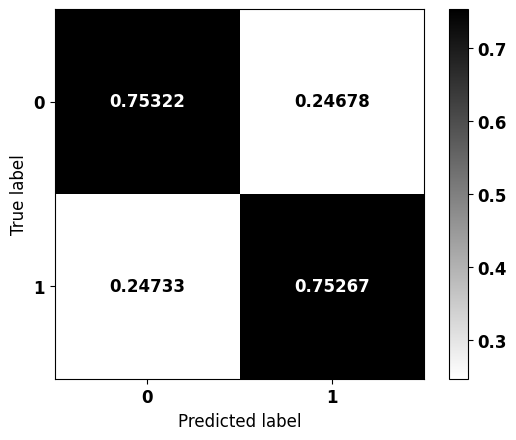


              precision    recall  f1-score   support

           0    0.75667   0.75322   0.75494      3728
           1    0.74918   0.75267   0.75092      3651

    accuracy                        0.75295      7379
   macro avg    0.75293   0.75294   0.75293      7379
weighted avg    0.75296   0.75295   0.75295      7379



In [ ]:
# XGBoost
xgb = XGBClassifier(max_depth=4,             # max_depth = 4
                    scale_pos_weight=0.7982, # Peso da classe 1
                    random_state=seed)       # Reprodutibilidade

# Treinamento do modelo
xgb.fit(X_train, y_train)

# Matriz de confusão
plot_confusion_matrix(xgb, X_test, y_test)

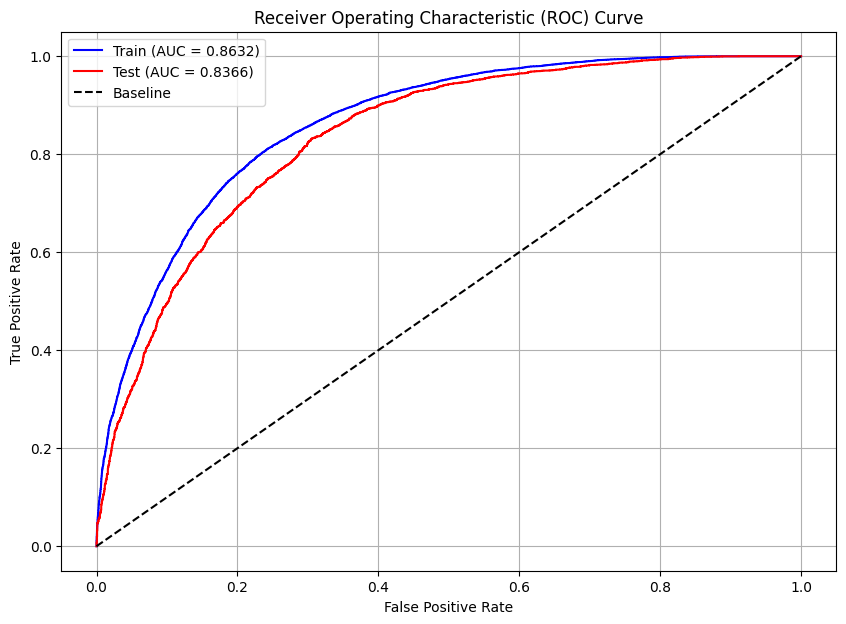

In [ ]:
# Curva ROC
plot_roc_curve(xgb, X_train, X_test, y_train, y_test)

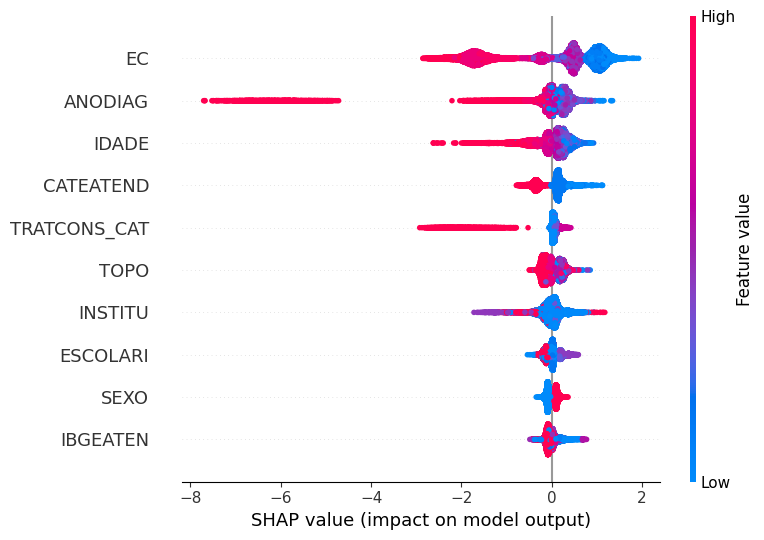

In [ ]:
# Importância pelo SHAP
plot_shap_values(xgb, X_train, feat_cols)

#### **Optuna**

In [ ]:
# Folds para validação cruzada
skf = StratifiedKFold(10, shuffle=True, random_state=seed)

# Função objetivo para otimização de hiperparâmetros
def objective(trial):

    # Define os hiperparâmetros que serão otimizados
    n_estimators = trial.suggest_int('n_estimators', 50, 150)  # Número de árvores
    max_depth = trial.suggest_int('max_depth', 3, 5)  # Profundidade máxima de cada árvore
    learning_rate = trial.suggest_float('learning_rate', 0.05, 0.2, step=0.05)  # Taxa de aprendizado
    gamma = trial.suggest_float('gamma', 0.0, 0.3, step=0.1)  # Termo de regularização
    min_child_weight = trial.suggest_int('min_child_weight', 1, 7)  # Mínimo peso para os nós filhos
    colsample_bytree = trial.suggest_float('colsample_bytree', 0.3, 0.7, step=0.1)  # Fração de features para cada árvore

    # Cria e treina o modelo com os hiperparâmetros escolhidos
    cls = XGBClassifier(n_estimators=n_estimators,
                        max_depth=max_depth,
                        learning_rate=learning_rate,
                        gamma=gamma,
                        min_child_weight=min_child_weight,
                        colsample_bytree=colsample_bytree,
                        random_state=seed,
                        n_jobs=-1)

    # Realiza a validação cruzada e retorna o valor médio de acurácia
    return cross_val_score(cls, X_train, y_train,
                           cv=skf, scoring='accuracy').mean()

**RandomSampler**

In [ ]:
# Otimização dos hiperparâmetros com Optuna - RandomSampler
studyXGB = optuna.create_study(direction='maximize', sampler=RandomSampler(seed))

# Inicia o estudo com 'n_trials'
studyXGB.optimize(objective, n_trials=150, n_jobs=-1)

In [ ]:
# Melhores hiperparâmetros encontrados
studyXGB.best_params

{'n_estimators': 97,
 'max_depth': 5,
 'learning_rate': 0.2,
 'gamma': 0.1,
 'min_child_weight': 4,
 'colsample_bytree': 0.7}

Best weight: 0.7882


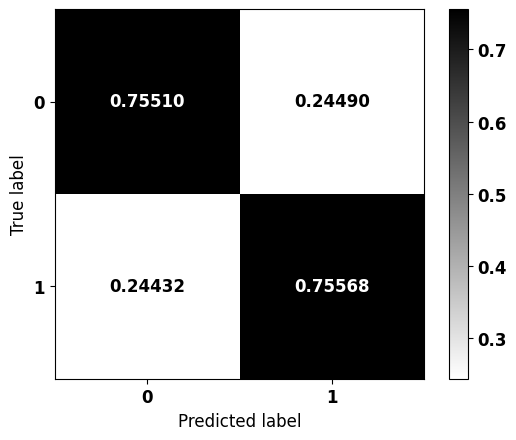


              precision    recall  f1-score   support

           0    0.75937   0.75510   0.75723      3728
           1    0.75136   0.75568   0.75352      3651

    accuracy                        0.75539      7379
   macro avg    0.75537   0.75539   0.75537      7379
weighted avg    0.75541   0.75539   0.75539      7379



In [ ]:
# Candidatos a scale_pos_weight após a busca por hiperparâmetros
pesos = np.round(np.arange(0.78, 0.8, 0.0001), 4)

# Salva os melhores hiperparâmetros e fixa o random_state
params = studyXGB.best_params
params['random_state'] = seed
mean, peso = 0, 0  # Média e peso

# Itera entre os candidatos a peso
for i in pesos:
    params['scale_pos_weight'] = i  # Atualiza o peso

    # Cria o modelo com os parâmetros
    xgb_optuna = XGBClassifier()
    xgb_optuna.set_params(**params)

    # Treino do modelo
    xgb_optuna.fit(X_train, y_train)

    # Predições no conjunto de teste
    y_pred = xgb_optuna.predict(X_test)

    # Matriz de confusão para calcular se houve ganho no ajuste do peso
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred, normalize='true').ravel()

    # Verifica se a diferença das diagonais principais é menor que 0.1% e se a média é maior
    if (abs(tn - tp) <= 0.001) and ((tn+tp)/2 > mean):
        peso = i
        mean = (tn+tp)/2
        best = xgb_optuna

if peso != 0:
    print(f'Best weight: {peso}')  # Print do melhor peso encontrado
    plot_confusion_matrix(best, X_test, y_test)  # Matriz de confusão

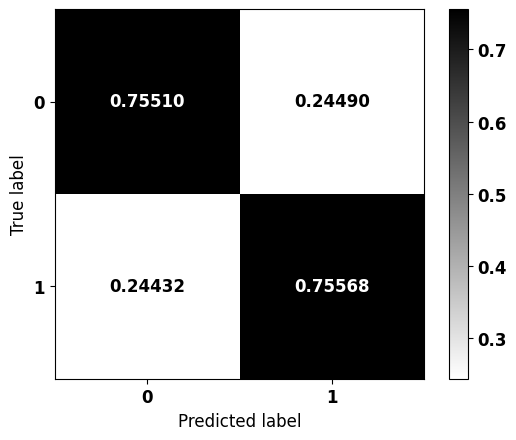


              precision    recall  f1-score   support

           0    0.75937   0.75510   0.75723      3728
           1    0.75136   0.75568   0.75352      3651

    accuracy                        0.75539      7379
   macro avg    0.75537   0.75539   0.75537      7379
weighted avg    0.75541   0.75539   0.75539      7379



In [ ]:
# Treino e validação com os melhores hiperparâmetros
params = studyXGB.best_params  # Salva os hiperparâmetros do estudo
params['random_state'] = seed  # Reprodutibilidade
params['scale_pos_weight'] = 0.7882  # Peso para a classe 1

# Criação do modelo com os parâmetros encontrados
xgb_rand = XGBClassifier()
xgb_rand.set_params(**params)

# Treinamento do modelo
xgb_rand.fit(X_train, y_train)

# Matriz de confusão do modelo otimizado
plot_confusion_matrix(xgb_rand, X_test, y_test)

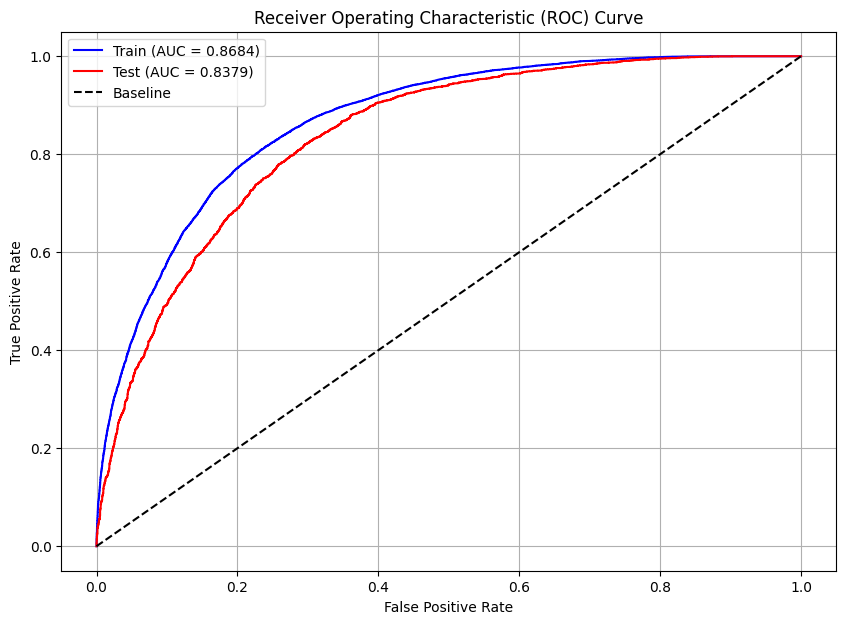

In [ ]:
# Curva ROC
plot_roc_curve(xgb_rand, X_train, X_test, y_train, y_test)

**TPESampler**

In [ ]:
# Otimização dos hiperparâmetros com Optuna - TPESampler
studyXGB = optuna.create_study(direction='maximize', sampler=TPESampler(seed=seed))

# Inicia o estudo com 'n_trials'
studyXGB.optimize(objective, n_trials=150, n_jobs=-1)

In [ ]:
# Melhores hiperparâmetros encontrados
studyXGB.best_params

{'n_estimators': 150,
 'max_depth': 5,
 'learning_rate': 0.2,
 'gamma': 0.1,
 'min_child_weight': 1,
 'colsample_bytree': 0.5}

Best weight: 0.7986


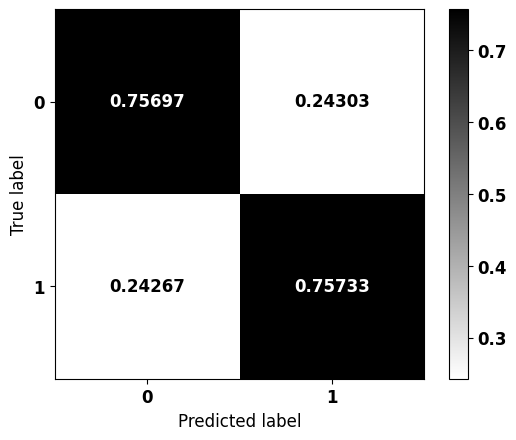


              precision    recall  f1-score   support

           0    0.76106   0.75697   0.75901      3728
           1    0.75320   0.75733   0.75526      3651

    accuracy                        0.75715      7379
   macro avg    0.75713   0.75715   0.75713      7379
weighted avg    0.75717   0.75715   0.75715      7379



In [ ]:
# Candidatos a scale_pos_weight após a busca por hiperparâmetros
pesos = np.round(np.arange(0.78, 0.81, 0.0001), 4)

# Salva os melhores hiperparâmetros e fixa o random_state
params = studyXGB.best_params
params['random_state'] = seed
mean, peso = 0, 0  # Média e peso

# Itera entre os candidatos a peso
for i in pesos:
    params['scale_pos_weight'] = i  # Atualiza o peso

    # Cria o modelo com os parâmetros
    xgb_optuna = XGBClassifier()
    xgb_optuna.set_params(**params)

    # Treino do modelo
    xgb_optuna.fit(X_train, y_train)

    # Predições no conjunto de teste
    y_pred = xgb_optuna.predict(X_test)

    # Matriz de confusão para calcular se houve ganho no ajuste do peso
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred, normalize='true').ravel()

    # Verifica se a diferença das diagonais principais é menor que 0.1% e se a média é maior
    if (abs(tn - tp) <= 0.001) and ((tn+tp)/2 > mean):
        peso = i
        mean = (tn+tp)/2
        best = xgb_optuna

if peso != 0:
    print(f'Best weight: {peso}')  # Print do melhor peso encontrado
    plot_confusion_matrix(best, X_test, y_test)  # Matriz de confusão

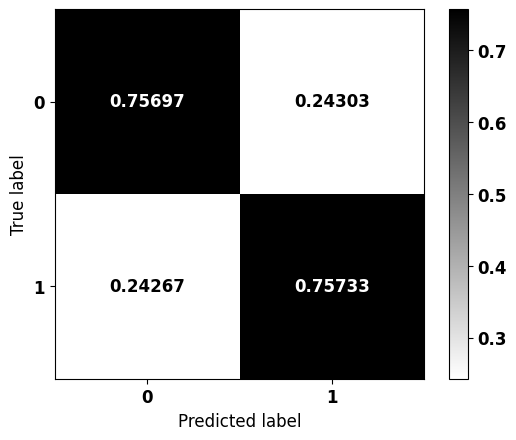


              precision    recall  f1-score   support

           0    0.76106   0.75697   0.75901      3728
           1    0.75320   0.75733   0.75526      3651

    accuracy                        0.75715      7379
   macro avg    0.75713   0.75715   0.75713      7379
weighted avg    0.75717   0.75715   0.75715      7379



In [ ]:
# Treino e validação com os melhores hiperparâmetros
params = studyXGB.best_params  # Salva os hiperparâmetros do estudo
params['random_state'] = seed  # Reprodutibilidade
params['scale_pos_weight'] = 0.7986  # Peso para a classe 1

# Criação do modelo com os parâmetros encontrados
xgb_tpe = XGBClassifier()
xgb_tpe.set_params(**params)

# Treinamento do modelo
xgb_tpe.fit(X_train, y_train)

# Matriz de confusão do modelo otimizado
plot_confusion_matrix(xgb_tpe, X_test, y_test)

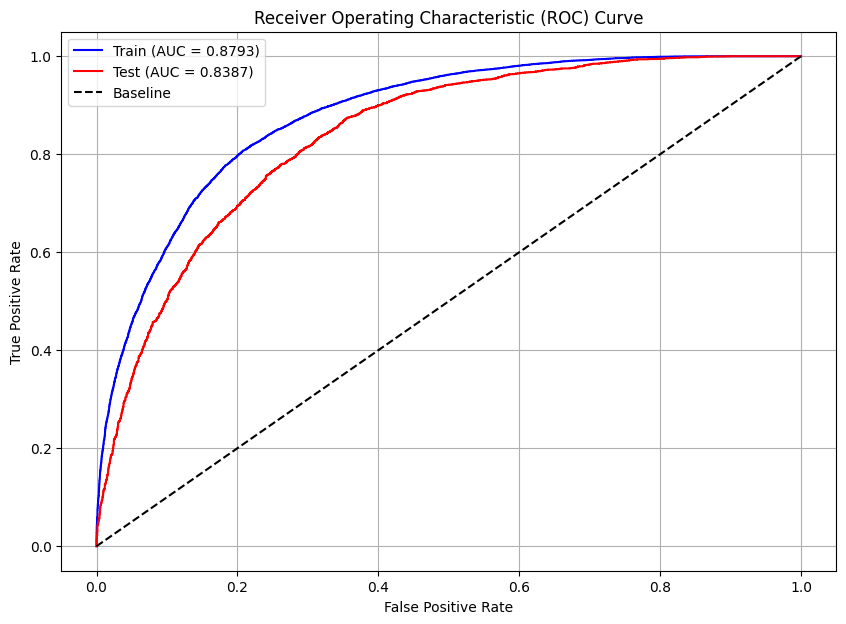

In [ ]:
# Curva ROC
plot_roc_curve(xgb_tpe, X_train, X_test, y_train, y_test)

**CmaEsSampler**

In [ ]:
# Otimização dos hiperparâmetros com Optuna - CmaEsSampler
studyXGB = optuna.create_study(direction='maximize', sampler=CmaEsSampler(seed=seed))

# Inicia o estudo com 'n_trials'
studyXGB.optimize(objective, n_trials=150, n_jobs=-1)

In [ ]:
# Melhores hiperparâmetros encontrados
studyXGB.best_params

{'n_estimators': 135,
 'max_depth': 5,
 'learning_rate': 0.15000000000000002,
 'gamma': 0.3,
 'min_child_weight': 3,
 'colsample_bytree': 0.6000000000000001}

Best weight: 0.791


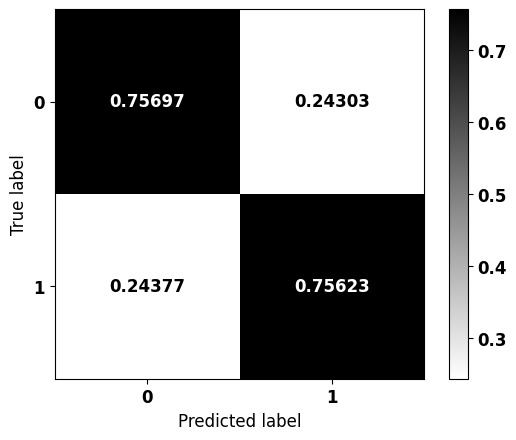


              precision    recall  f1-score   support

           0    0.76024   0.75697   0.75860      3728
           1    0.75293   0.75623   0.75458      3651

    accuracy                        0.75661      7379
   macro avg    0.75658   0.75660   0.75659      7379
weighted avg    0.75662   0.75661   0.75661      7379



In [ ]:
# Candidatos a scale_pos_weight após a busca por hiperparâmetros
pesos = np.round(np.arange(0.78, 0.8, 0.0001), 4)

# Salva os melhores hiperparâmetros e fixa o random_state
params = studyXGB.best_params
params['random_state'] = seed
mean, peso = 0, 0  # Média e peso

# Itera entre os candidatos a peso
for i in pesos:
    params['scale_pos_weight'] = i  # Atualiza o peso

    # Cria o modelo com os parâmetros
    xgb_optuna = XGBClassifier()
    xgb_optuna.set_params(**params)

    # Treino do modelo
    xgb_optuna.fit(X_train, y_train)

    # Predições no conjunto de teste
    y_pred = xgb_optuna.predict(X_test)

    # Matriz de confusão para calcular se houve ganho no ajuste do peso
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred, normalize='true').ravel()

    # Verifica se a diferença das diagonais principais é menor que 0.1% e se a média é maior
    if (abs(tn - tp) <= 0.001) and ((tn+tp)/2 > mean):
        peso = i
        mean = (tn+tp)/2
        best = xgb_optuna

if peso != 0:
    print(f'Best weight: {peso}')  # Print do melhor peso encontrado
    plot_confusion_matrix(best, X_test, y_test)  # Matriz de confusão

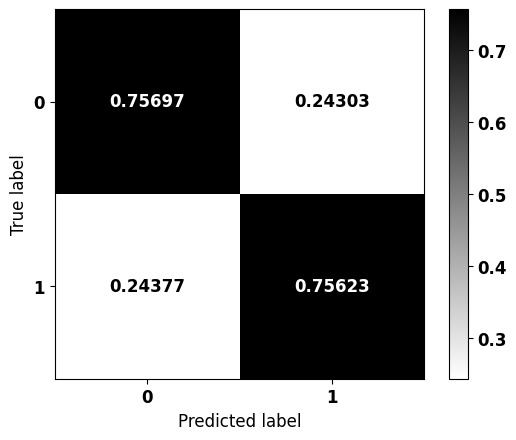


              precision    recall  f1-score   support

           0    0.76024   0.75697   0.75860      3728
           1    0.75293   0.75623   0.75458      3651

    accuracy                        0.75661      7379
   macro avg    0.75658   0.75660   0.75659      7379
weighted avg    0.75662   0.75661   0.75661      7379



In [ ]:
# Treino e validação com os melhores hiperparâmetros
params = studyXGB.best_params  # Salva os hiperparâmetros do estudo
params['random_state'] = seed  # Reprodutibilidade
params['scale_pos_weight'] = 0.791  # Peso para a classe 1

# Criação do modelo com os parâmetros encontrados
xgb_cma = XGBClassifier()
xgb_cma.set_params(**params)

# Treinamento do modelo
xgb_cma.fit(X_train, y_train)

# Matriz de confusão do modelo otimizado
plot_confusion_matrix(xgb_cma, X_test, y_test)

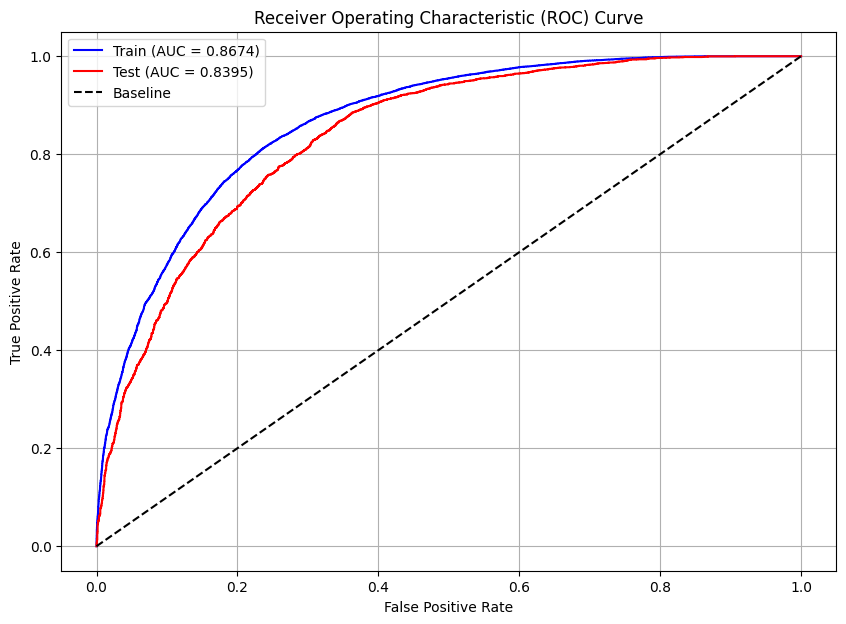

In [ ]:
# Curva ROC
plot_roc_curve(xgb_cma, X_train, X_test, y_train, y_test)

**Modelo otimizado**

In [ ]:
# Seleção do melhor modelo
models = [xgb_rand, xgb_tpe, xgb_cma]  # Lista dos modelos
best = models[0]

# Itera entre os modelos para encontrar o com maior acurácia
for i, m in enumerate(models):
    if i == 0:
        continue

    best_score = best.score(X_test, y_test)  # Acurácia do melhor modelo
    score = m.score(X_test, y_test)  # Acurácia do modelo atual

    if score > best_score:  # Atualiza o melhor modelo se a acurácia for maior
        best = m

# Print do melhor modelo selecionado
print(best)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.5, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=0.1, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.2, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=1, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=150, n_jobs=None,
              num_parallel_tree=None, random_state=1, ...)


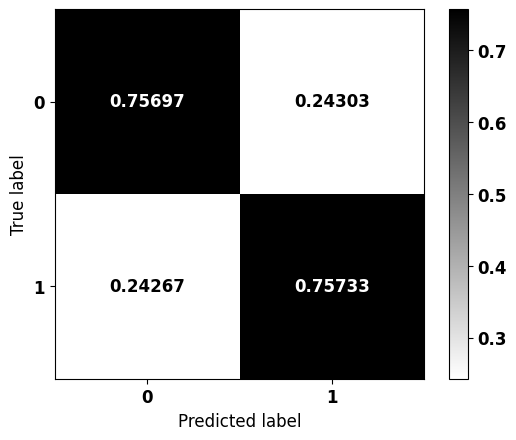


              precision    recall  f1-score   support

           0    0.76106   0.75697   0.75901      3728
           1    0.75320   0.75733   0.75526      3651

    accuracy                        0.75715      7379
   macro avg    0.75713   0.75715   0.75713      7379
weighted avg    0.75717   0.75715   0.75715      7379



In [ ]:
# Treinamento do modelo final com os melhores hiperparâmetros
params = best.get_params()

# Inicializa o modelo final
xgb_optuna = XGBClassifier()
xgb_optuna.set_params(**params)

# Treinamento do modelo otimizado
xgb_optuna.fit(X_train, y_train)

# Plot da matriz de confusão para o conjunto de teste
plot_confusion_matrix(xgb_optuna, X_test, y_test)

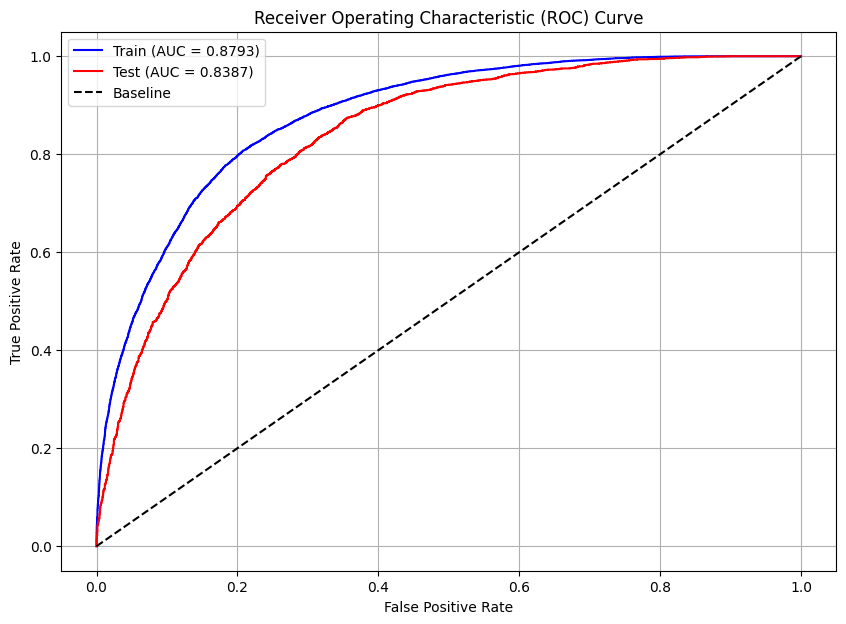

In [ ]:
# Curva ROC
plot_roc_curve(xgb_optuna, X_train, X_test, y_train, y_test)

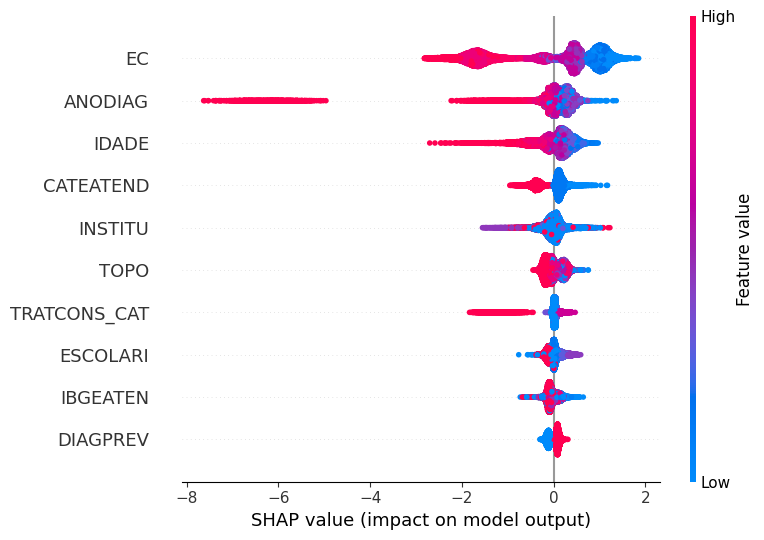

In [ ]:
# Importância das features pelo SHAP
plot_shap_values(xgb_optuna, X_train, feat_cols)

### **LightGBM**


#### **Baseline**

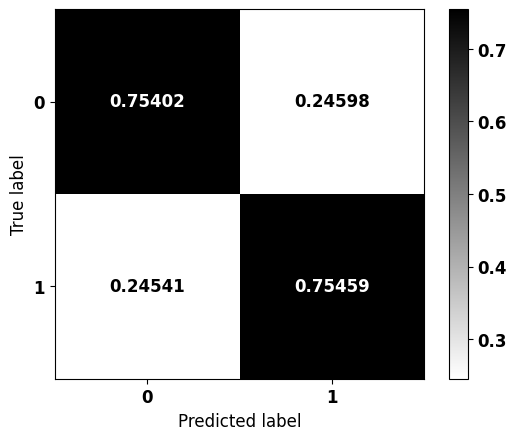


              precision    recall  f1-score   support

           0    0.75830   0.75402   0.75615      3728
           1    0.75027   0.75459   0.75242      3651

    accuracy                        0.75430      7379
   macro avg    0.75428   0.75431   0.75429      7379
weighted avg    0.75433   0.75430   0.75431      7379



In [ ]:
# Cria e treina o modelo LightGBM

# Inicializa o classificador LightGBM com os parâmetros especificados
lgbm = LGBMClassifier(max_depth=8,                      # Define a profundidade máxima das árvores
                      class_weight={0: 1.2501, 1: 1},   # Ajusta o peso das classes para lidar com o desbalanceamento
                      random_state=seed,                # Garante a reprodutibilidade dos resultados
                      verbose=-1)

# Treina o modelo utilizando o conjunto de dados de treinamento
lgbm.fit(X_train, y_train)

# Matriz de confusão

# Gera e exibe a matriz de confusão para avaliar as classificações
# realizadas pelo modelo no conjunto de teste
plot_confusion_matrix(lgbm, X_test, y_test)

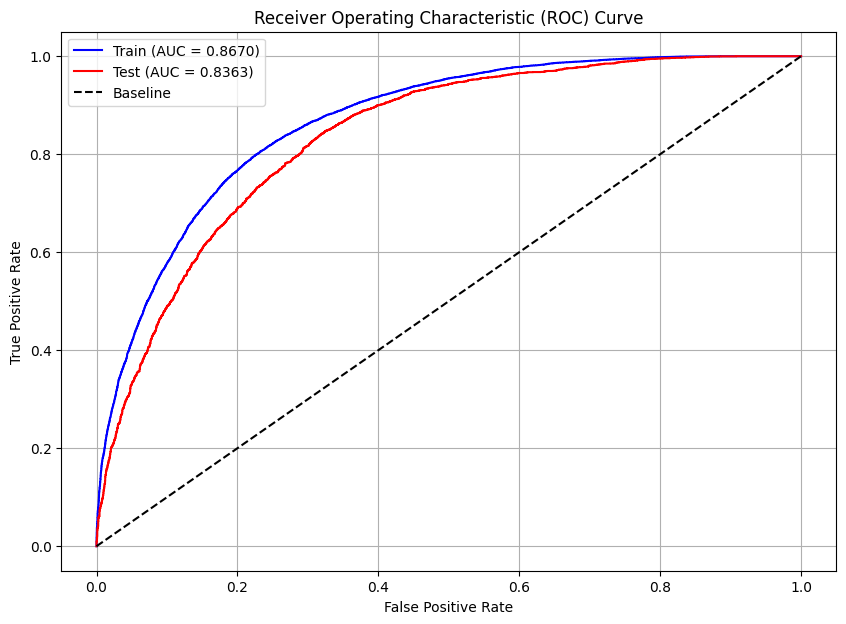

In [ ]:
# Curva ROC
plot_roc_curve(lgbm, X_train, X_test, y_train, y_test)

/usr/local/lib/python3.11/dist-packages/shap/explainers/_tree.py:583: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


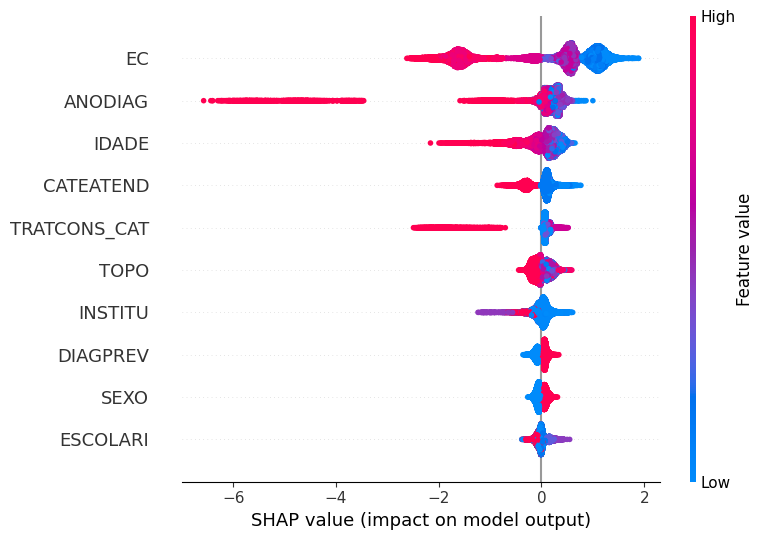

In [ ]:
# Importância pelo SHAP
plot_shap_values(lgbm, X_train, feat_cols)

#### **Optuna**

In [ ]:
# Cria os folds estratificados, mantendo aproximadamente a mesma proporção
# de classes em cada divisão dos dados
skf = StratifiedKFold(10, shuffle=True, random_state=seed)

# Define a função objetivo utilizada pelo Optuna para otimizar
# os hiperparâmetros do modelo LightGBM
def objective(trial):

    # Define o espaço de busca dos hiperparâmetros
    # Número de árvores utilizadas pelo modelo
    n_estimators = trial.suggest_int('n_estimators', 50, 150)

    # Profundidade máxima das árvores
    max_depth = trial.suggest_int('max_depth', 3, 8)

    # Taxa de aprendizado utilizada durante o treinamento
    learning_rate = trial.suggest_float('learning_rate', 0.05, 0.2, step=0.01)

    # Soma mínima dos pesos necessária para criar um novo nó filho
    min_child_weight = trial.suggest_int('min_child_weight', 1, 7)

    # Proporção de variáveis selecionadas aleatoriamente para cada árvore
    colsample_bytree = trial.suggest_float('colsample_bytree', 0.3, 0.7, step=0.1)

    # Inicializa o classificador LightGBM com os hiperparâmetros
    # selecionados pelo Optuna na iteração atual
    cls = LGBMClassifier(n_estimators=n_estimators,
                         max_depth=max_depth,
                         learning_rate=learning_rate,
                         min_child_weight=min_child_weight,
                         colsample_bytree=colsample_bytree,
                         random_state=seed,
                         verbose=-1,
                         n_jobs=-1)

    # Realiza validação cruzada estratificada e retorna a média
    # da acurácia obtida nos 10 folds.
    # O Optuna utiliza esse valor como função objetivo para selecionar
    # a combinação de hiperparâmetros com melhor desempenho.
    return cross_val_score(cls, X_train, y_train,
                           cv=skf, scoring='accuracy').mean()

**RandomSampler**

In [ ]:
# Otimização dos hiperparâmetros com Optuna - RandomSampler
studyLGBM = optuna.create_study(direction='maximize', sampler=RandomSampler(seed))

# Inicia o estudo com 'n_trials'
studyLGBM.optimize(objective, n_trials=150, n_jobs=-1)

In [ ]:
# Melhores hiperparâmetros encontrados
studyLGBM.best_params

{'n_estimators': 118,
 'max_depth': 6,
 'learning_rate': 0.18,
 'min_child_weight': 3,
 'colsample_bytree': 0.6000000000000001}

Best weight: 1.279


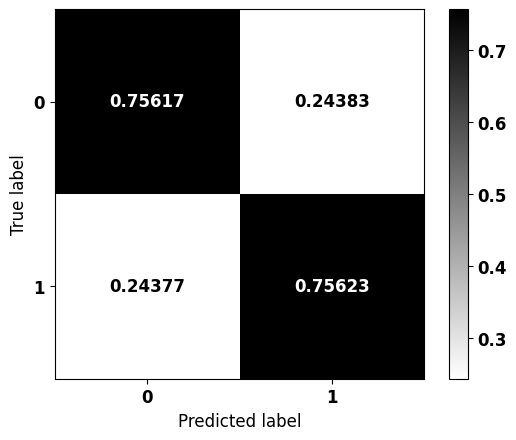


              precision    recall  f1-score   support

           0    0.76004   0.75617   0.75810      3728
           1    0.75232   0.75623   0.75427      3651

    accuracy                        0.75620      7379
   macro avg    0.75618   0.75620   0.75618      7379
weighted avg    0.75622   0.75620   0.75620      7379



In [ ]:
# Candidatos a class_weight após a busca por hiperparâmetros
pesos = np.round(np.arange(1.25, 1.4, 0.001), 3)

# Salva os melhores hiperparâmetros e fixa o random_state
params = studyLGBM.best_params
params['random_state'] = seed
mean, peso = 0, 0  # Média e peso

# Itera entre os candidatos a peso
for i in pesos:
    params['class_weight'] = {0:i, 1:1}  # Atualiza o peso

    # Cria o modelo com os parâmetros
    lgbm_optuna = LGBMClassifier(verbose=-1)
    lgbm_optuna.set_params(**params)

    # Treino do modelo
    lgbm_optuna.fit(X_train, y_train)

    # Predições no conjunto de teste
    y_pred = lgbm_optuna.predict(X_test)

    # Matriz de confusão para calcular se houve ganho no ajuste do peso
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred, normalize='true').ravel()

    # Verifica se a diferença das diagonais principais é menor que 0.1% e se a média é maior
    if (abs(tn - tp) <= 0.001) and ((tn+tp)/2 > mean):
        peso = i
        mean = (tn+tp)/2
        best = lgbm_optuna

if peso != 0:
    print(f'Best weight: {peso}')  # Print do melhor peso encontrado
    plot_confusion_matrix(best, X_test, y_test)  # Matriz de confusão

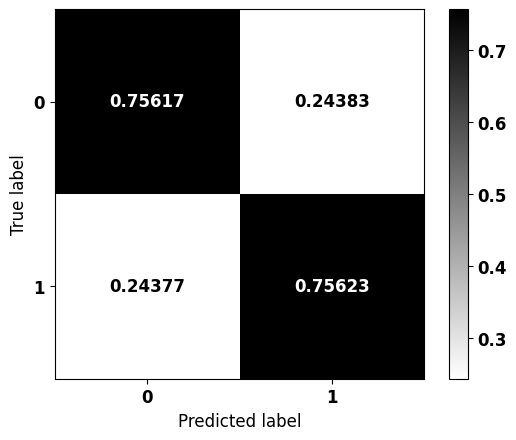


              precision    recall  f1-score   support

           0    0.76004   0.75617   0.75810      3728
           1    0.75232   0.75623   0.75427      3651

    accuracy                        0.75620      7379
   macro avg    0.75618   0.75620   0.75618      7379
weighted avg    0.75622   0.75620   0.75620      7379



In [ ]:
# Treino e validação com os melhores hiperparâmetros
params = studyLGBM.best_params  # Salva os hiperparâmetros do estudo
params['random_state'] = seed  # Reprodutibilidade
params['class_weight'] = {0:1.279, 1:1}  # Peso para a classe 0

# Criação do modelo com os parâmetros encontrados
lgbm_rand = LGBMClassifier(verbose=-1)
lgbm_rand.set_params(**params)

# Treinamento do modelo
lgbm_rand.fit(X_train, y_train)

# Matriz de confusão do modelo otimizado
plot_confusion_matrix(lgbm_rand, X_test, y_test)

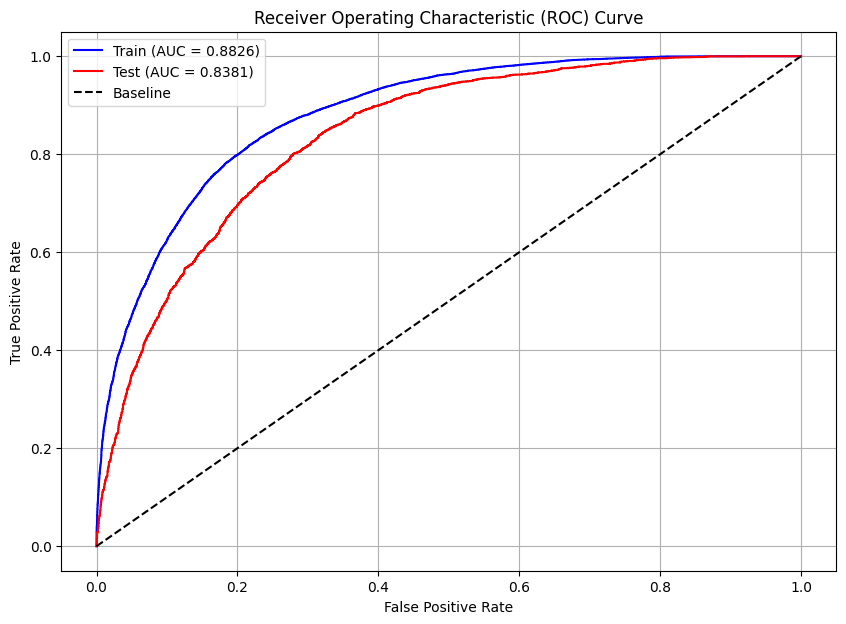

In [ ]:
# Curva ROC
plot_roc_curve(lgbm_rand, X_train, X_test, y_train, y_test)

**TPESampler**

In [ ]:
# Otimização dos hiperparâmetros com Optuna - TPESampler
studyLGBM = optuna.create_study(direction='maximize', sampler=TPESampler(seed=seed))

# Inicia o estudo com 'n_trials'
studyLGBM.optimize(objective, n_trials=150, n_jobs=-1)

In [ ]:
# Melhores hiperparâmetros encontrados
studyLGBM.best_params

{'n_estimators': 112,
 'max_depth': 8,
 'learning_rate': 0.09,
 'min_child_weight': 3,
 'colsample_bytree': 0.4}

Best weight: 1.293


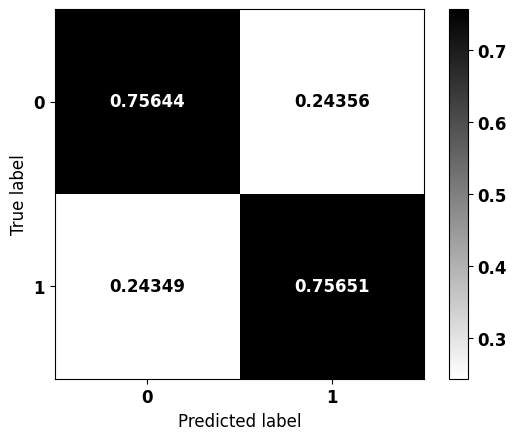


              precision    recall  f1-score   support

           0    0.76031   0.75644   0.75837      3728
           1    0.75259   0.75651   0.75454      3651

    accuracy                        0.75647      7379
   macro avg    0.75645   0.75647   0.75646      7379
weighted avg    0.75649   0.75647   0.75648      7379



In [ ]:
# Candidatos a class_weight após a busca por hiperparâmetros
pesos = np.round(np.arange(1.25, 1.4, 0.001), 3)

# Salva os melhores hiperparâmetros e fixa o random_state
params = studyLGBM.best_params
params['random_state'] = seed
mean, peso = 0, 0  # Média e peso

# Itera entre os candidatos a peso
for i in pesos:
    params['class_weight'] = {0:i, 1:1}  # Atualiza o peso

    # Cria o modelo com os parâmetros
    lgbm_optuna = LGBMClassifier(verbose=-1)
    lgbm_optuna.set_params(**params)

    # Treino do modelo
    lgbm_optuna.fit(X_train, y_train)

    # Predições no conjunto de teste
    y_pred = lgbm_optuna.predict(X_test)

    # Matriz de confusão para calcular se houve ganho no ajuste do peso
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred, normalize='true').ravel()

    # Verifica se a diferença das diagonais principais é menor que 0.1% e se a média é maior
    if (abs(tn - tp) <= 0.001) and ((tn+tp)/2 > mean):
        peso = i
        mean = (tn+tp)/2
        best = lgbm_optuna

if peso != 0:
    print(f'Best weight: {peso}')  # Print do melhor peso encontrado
    plot_confusion_matrix(best, X_test, y_test)  # Matriz de confusão

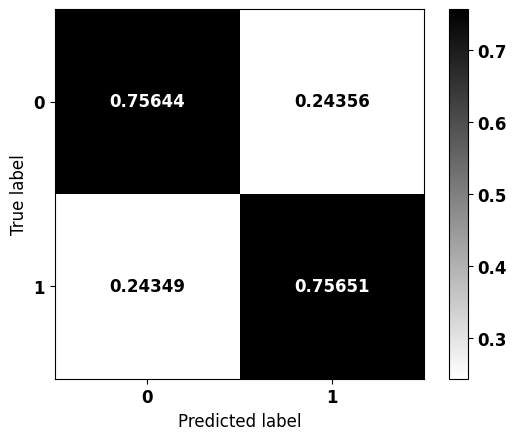


              precision    recall  f1-score   support

           0    0.76031   0.75644   0.75837      3728
           1    0.75259   0.75651   0.75454      3651

    accuracy                        0.75647      7379
   macro avg    0.75645   0.75647   0.75646      7379
weighted avg    0.75649   0.75647   0.75648      7379



In [ ]:
# Treino e validação com os melhores hiperparâmetros
params = studyLGBM.best_params  # Salva os hiperparâmetros do estudo
params['random_state'] = seed  # Reprodutibilidade
params['class_weight'] = {0:1.293, 1:1}  # Peso para a classe 0

# Criação do modelo com os parâmetros encontrados
lgbm_tpe = LGBMClassifier(verbose=-1)
lgbm_tpe.set_params(**params)

# Treinamento do modelo
lgbm_tpe.fit(X_train, y_train)

# Matriz de confusão do modelo otimizado
plot_confusion_matrix(lgbm_tpe, X_test, y_test)

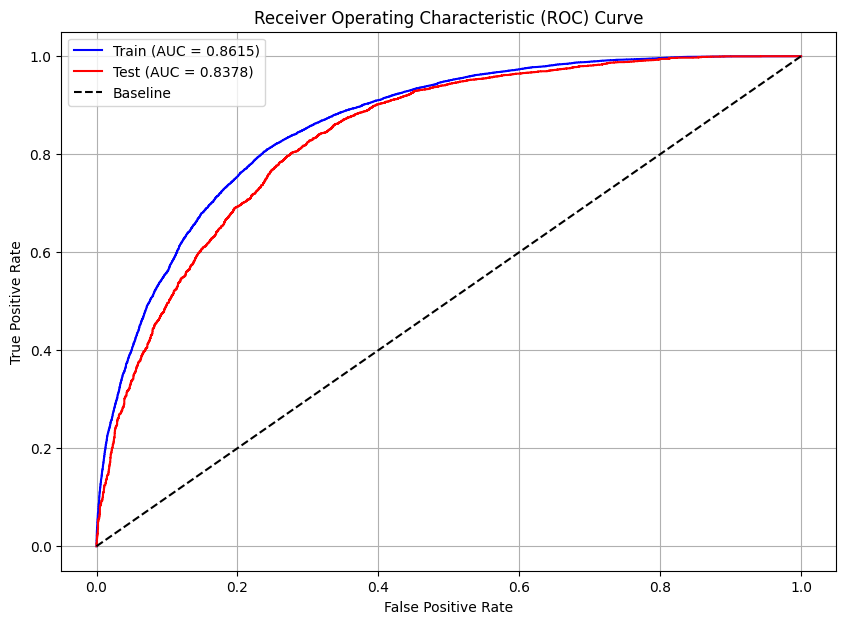

In [ ]:
# Curva ROC
plot_roc_curve(lgbm_tpe, X_train, X_test, y_train, y_test)

**CmaEsSampler**

In [ ]:
# Otimização dos hiperparâmetros com Optuna - CmaEsSampler
studyLGBM = optuna.create_study(direction='maximize', sampler=CmaEsSampler(seed=seed))

# Inicia o estudo com 'n_trials'
studyLGBM.optimize(objective, n_trials=150, n_jobs=-1)

In [ ]:
# Melhores hiperparâmetros encontrados
studyLGBM.best_params

{'n_estimators': 130,
 'max_depth': 7,
 'learning_rate': 0.16,
 'min_child_weight': 4,
 'colsample_bytree': 0.4}

Best weight: 1.253


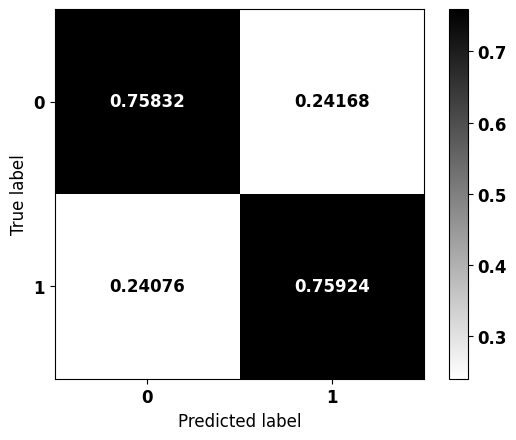


              precision    recall  f1-score   support

           0    0.76282   0.75832   0.76056      3728
           1    0.75470   0.75924   0.75696      3651

    accuracy                        0.75877      7379
   macro avg    0.75876   0.75878   0.75876      7379
weighted avg    0.75880   0.75877   0.75878      7379



In [ ]:
# Candidatos a class_weight após a busca por hiperparâmetros
pesos = np.round(np.arange(1.2, 1.35, 0.001), 3)

# Salva os melhores hiperparâmetros e fixa o random_state
params = studyLGBM.best_params
params['random_state'] = seed
mean, peso = 0, 0  # Média e peso

# Itera entre os candidatos a peso
for i in pesos:
    params['class_weight'] = {0:i, 1:1}  # Atualiza o peso

    # Cria o modelo com os parâmetros
    lgbm_optuna = LGBMClassifier(verbose=-1)
    lgbm_optuna.set_params(**params)

    # Treino o modelo
    lgbm_optuna.fit(X_train, y_train)

    # Predições no conjunto de teste
    y_pred = lgbm_optuna.predict(X_test)

    # Matriz de confusão para calcular se houve ganho no ajuste do peso
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred, normalize='true').ravel()

    # Verifica se a diferença das diagonais principais é menor que 0.1% e se a média é maior
    if (abs(tn - tp) <= 0.001) and ((tn+tp)/2 > mean):
        peso = i
        mean = (tn+tp)/2
        best = lgbm_optuna

if peso != 0:
    print(f'Best weight: {peso}')  # Print do melhor peso encontrado
    plot_confusion_matrix(best, X_test, y_test)  # Matriz de confusão

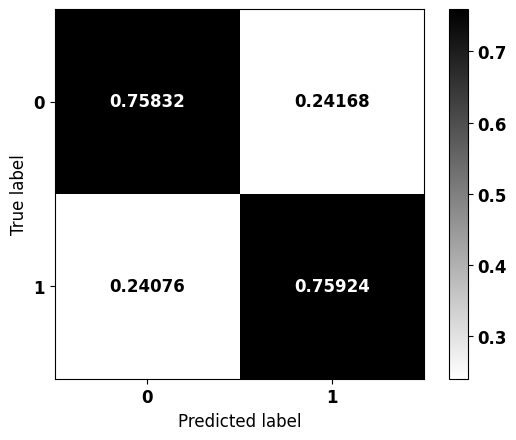


              precision    recall  f1-score   support

           0    0.76282   0.75832   0.76056      3728
           1    0.75470   0.75924   0.75696      3651

    accuracy                        0.75877      7379
   macro avg    0.75876   0.75878   0.75876      7379
weighted avg    0.75880   0.75877   0.75878      7379



In [ ]:
# Treino e validação com os melhores hiperparâmetros
params = studyLGBM.best_params  # Salva os hiperparâmetros do estudo
params['random_state'] = seed  # Reprodutibilidade
params['class_weight'] = {0:1.253, 1:1}  # Peso para a classe 1

# Criação do modelo com os parâmetros encontrados
lgbm_cma = LGBMClassifier(verbose=-1)
lgbm_cma.set_params(**params)

# Treinamento do modelo
lgbm_cma.fit(X_train, y_train)

# Matriz de confusão do modelo otimizado
plot_confusion_matrix(lgbm_cma, X_test, y_test)

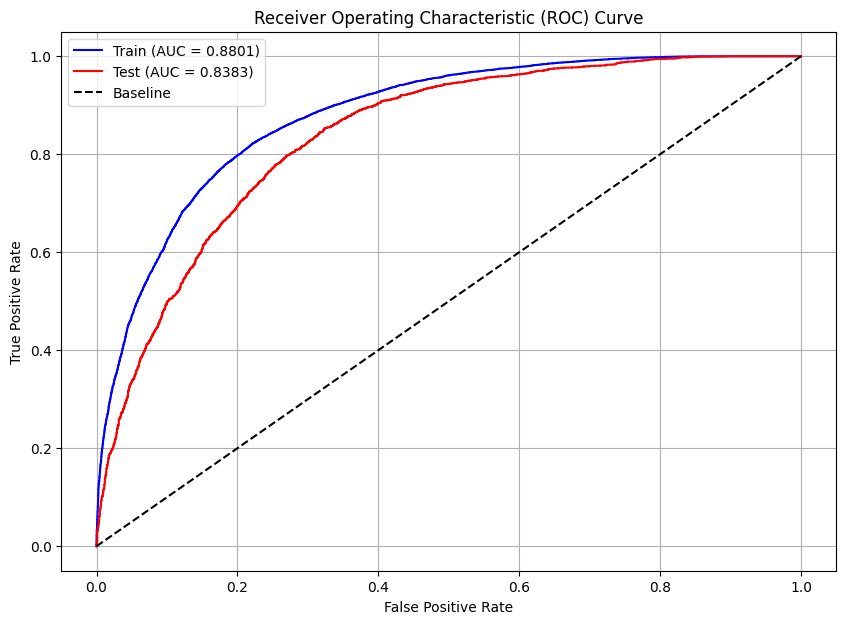

In [ ]:
# Curva ROC
plot_roc_curve(lgbm_cma, X_train, X_test, y_train, y_test)

**Modelo otimizado**

In [ ]:
# Seleção do melhor modelo
models = [lgbm_rand, lgbm_tpe, lgbm_cma]  # Lista dos modelos
best = models[0]

# Itera entre os modelos para encontrar o com maior acurácia
for i, m in enumerate(models):
    if i == 0:
        continue

    best_score = best.score(X_test, y_test)  # Acurácia do melhor modelo
    score = m.score(X_test, y_test)  # Acurácia do modelo atual

    if score > best_score:  # Atualiza o melhor modelo se a acurácia for maior
        best = m

# Print do melhor modelo selecionado
print(best)

LGBMClassifier(class_weight={0: 1.253, 1: 1}, colsample_bytree=0.4,
               learning_rate=0.16, max_depth=7, min_child_weight=4,
               n_estimators=130, random_state=1, verbose=-1)


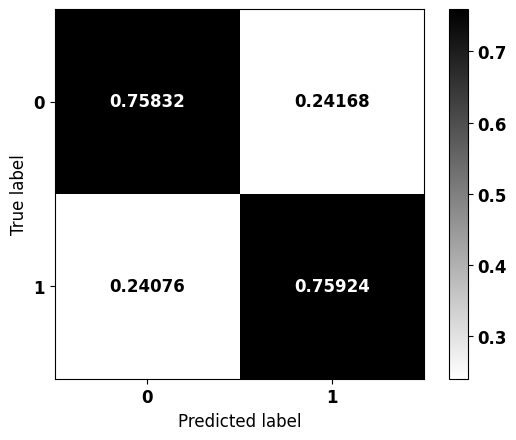


              precision    recall  f1-score   support

           0    0.76282   0.75832   0.76056      3728
           1    0.75470   0.75924   0.75696      3651

    accuracy                        0.75877      7379
   macro avg    0.75876   0.75878   0.75876      7379
weighted avg    0.75880   0.75877   0.75878      7379



In [ ]:
# Treinamento do modelo final com os melhores hiperparâmetros
params = best.get_params()

# Inicializa o modelo final
lgbm_optuna = LGBMClassifier(verbose=-1)
lgbm_optuna.set_params(**params)

# Treinamento do modelo otimizado
lgbm_optuna.fit(X_train, y_train)

# Plot da matriz de confusão para o conjunto de teste
plot_confusion_matrix(lgbm_optuna, X_test, y_test)

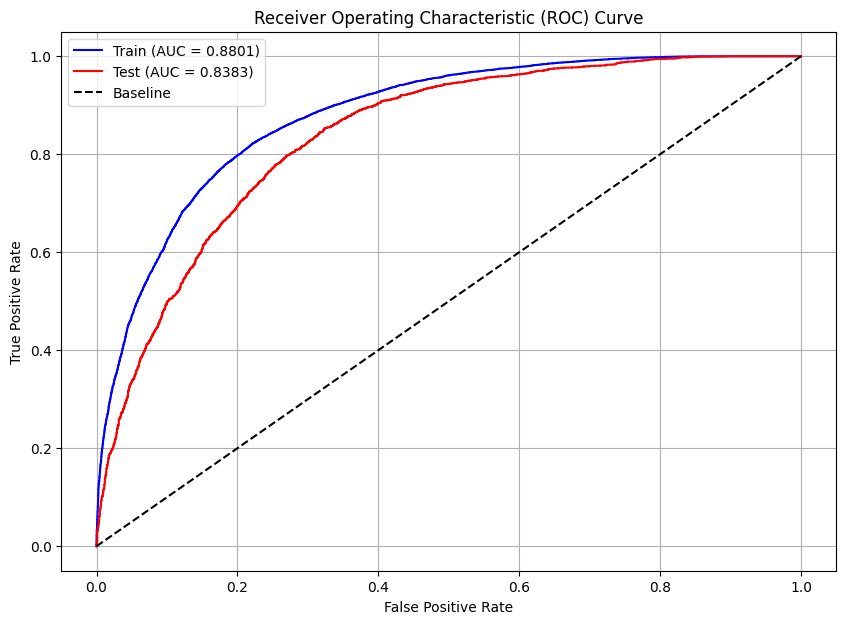

In [ ]:
# Curva ROC
plot_roc_curve(lgbm_optuna, X_train, X_test, y_train, y_test)

/usr/local/lib/python3.11/dist-packages/shap/explainers/_tree.py:583: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


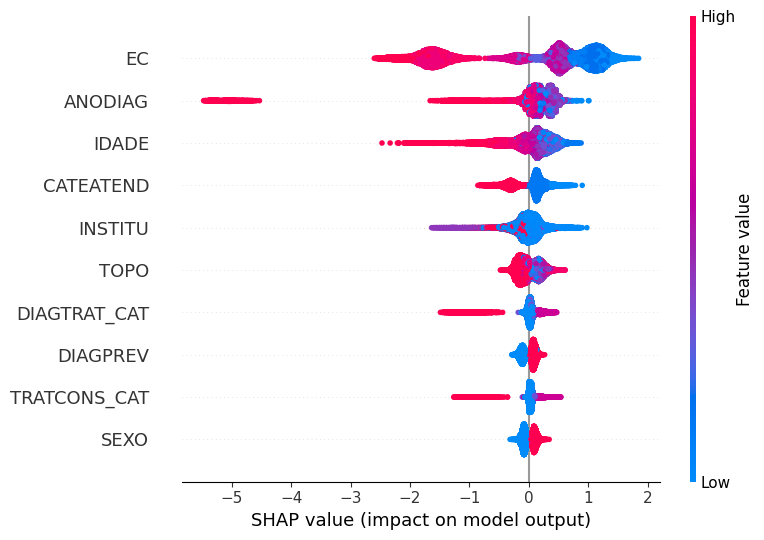

In [ ]:
# Importância das features pelo SHAP
plot_shap_values(lgbm_optuna, X_train, feat_cols)

## **Voting Classifier**


In [ ]:
# Compara as acurácias do modelo XGBoost inicial e do modelo
# otimizado pelo Optuna no conjunto de teste
xgb_score = xgb.score(X_test, y_test)
optuna_score = xgb_optuna.score(X_test, y_test)

# Exibe a acurácia de cada modelo com quatro casas decimais
print(f'Accuracy: XGB = {xgb_score:.4f}, Optuna = {optuna_score:.4f}\n')

# Verifica qual dos dois modelos apresentou o melhor desempenho

# Caso o modelo otimizado pelo Optuna apresente acurácia maior ou igual
# à do modelo inicial, seleciona o modelo otimizado
if optuna_score >= xgb_score:
    # Obtém os hiperparâmetros do modelo otimizado
    params_xgb = xgb_optuna.get_params()

    # Informa que o modelo otimizado apresentou o melhor desempenho
    print('Optimized model won')

else:
    # Caso contrário, obtém os hiperparâmetros do modelo inicial
    params_xgb = xgb.get_params()

    # Informa que o modelo inicial apresentou o melhor desempenho
    print('Initial model won')

Accuracy: XGB = 0.7529, Optuna = 0.7571

Optimized model won


In [ ]:
# Compara as acurácias do modelo LightGBM inicial e do modelo
# otimizado pelo Optuna no conjunto de teste
lgbm_score = lgbm.score(X_test, y_test)
optuna_score = lgbm_optuna.score(X_test, y_test)

# Exibe a acurácia de cada modelo com quatro casas decimais
print(f'Accuracy: LGBM = {lgbm_score:.4f}, Optuna = {optuna_score:.4f}\n')

# Verifica qual dos dois modelos apresentou o melhor desempenho

# Caso o modelo otimizado pelo Optuna apresente acurácia maior ou igual
# à do modelo inicial, seleciona o modelo otimizado
if optuna_score >= lgbm_score:
    # Obtém os hiperparâmetros do modelo otimizado pelo Optuna
    params_lgbm = lgbm_optuna.get_params()

    # Informa que o modelo otimizado apresentou o melhor desempenho
    print('Optimized model won')

else:
    # Caso contrário, obtém os hiperparâmetros do modelo LightGBM inicial
    params_lgbm = lgbm.get_params()

    # Informa que o modelo inicial apresentou o melhor desempenho
    print('Initial model won')

Accuracy: LGBM = 0.7543, Optuna = 0.7588

Optimized model won


In [ ]:
# Cria os modelos utilizando os hiperparâmetros que apresentaram
# o melhor desempenho durante o processo de avaliação

# Modelo XGBoost
# Inicializa o classificador XGBoost
best_xgb = XGBClassifier()

# Define os melhores hiperparâmetros selecionados para o modelo XGBoost
best_xgb.set_params(**params_xgb)

# Modelo LightGBM
# Inicializa o classificador LightGBM
best_lgbm = LGBMClassifier()

# Define os melhores hiperparâmetros selecionados para o modelo LightGBM
best_lgbm.set_params(**params_lgbm)

LGBMClassifier(class_weight={0: 1.253, 1: 1}, colsample_bytree=0.4,
               learning_rate=0.16, max_depth=7, min_child_weight=4,
               n_estimators=130, random_state=1, verbose=-1)

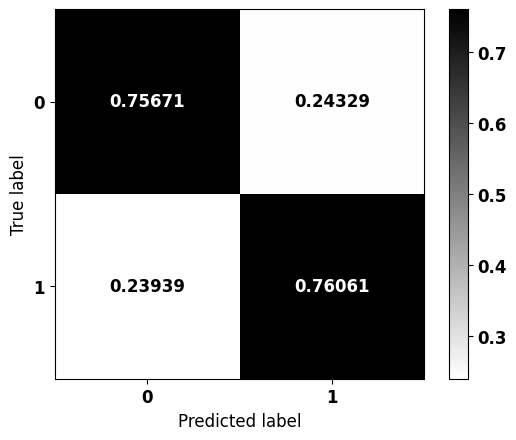


              precision    recall  f1-score   support

           0    0.76346   0.75671   0.76007      3728
           1    0.75380   0.76061   0.75719      3651

    accuracy                        0.75864      7379
   macro avg    0.75863   0.75866   0.75863      7379
weighted avg    0.75868   0.75864   0.75865      7379



In [ ]:
# Importa o classificador de votação da biblioteca scikit-learn
from sklearn.ensemble import VotingClassifier

# Cria o classificador de votação utilizando os modelos
# XGBoost e LightGBM com melhor desempenho
clf = VotingClassifier(
    estimators=[
        # Adiciona o modelo XGBoost com os melhores hiperparâmetros
        ('XGBoost', best_xgb),
        # Adiciona o modelo LightGBM com os melhores hiperparâmetros
        ('LightGBM', best_lgbm)
    ],
    # Utiliza votação ponderada pelas probabilidades previstas pelos modelos.
    # A classe final é determinada pela maior probabilidade média entre os modelos.
    voting='soft'
)

# Treina o classificador de votação utilizando o conjunto de treinamento
clf.fit(X_train, y_train)

# Matriz de confusão
# Gera e exibe a matriz de confusão para avaliar o desempenho
# do classificador de votação no conjunto de teste
plot_confusion_matrix(clf, X_test, y_test)

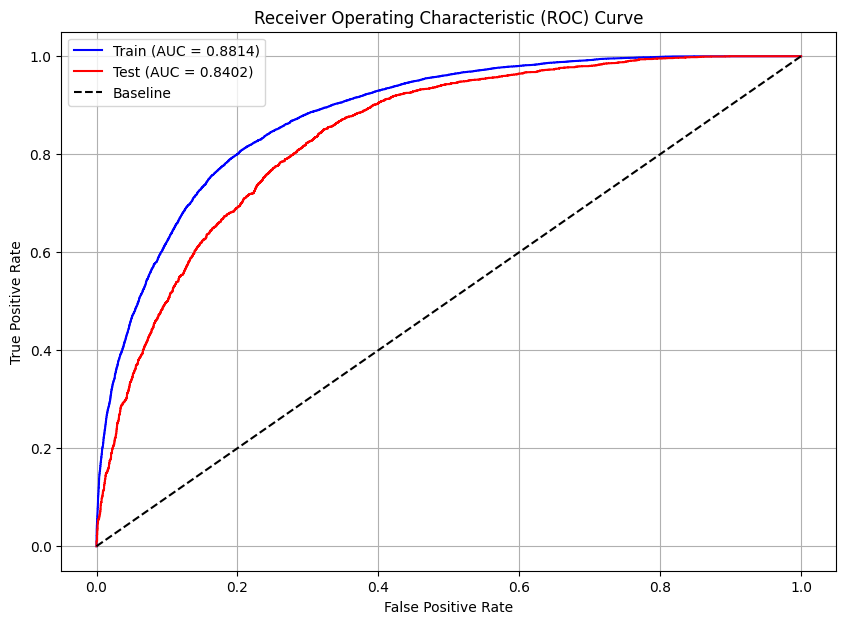

In [ ]:
# Curva ROC
plot_roc_curve(clf, X_train, X_test, y_train, y_test)

# **Sobrevida de 5 anos**

## **Treino e Teste**



In [ ]:
# Conjunto de dados de colorretal
!gdown 1yzI52UDZyac0QGWmKL5Mai1JOqWUTeMQ --quiet

In [ ]:
# Leitura dos dados
df_colo = pd.read_csv('colorretal.csv')
print(df_colo.shape)
df_colo.head(3)

(44857, 49)


,INSTITU,ESCOLARI,IDADE,SEXO,IBGE,CATEATEND,DIAGPREV,TOPO,EC,ECGRUP,...,TRATCONS_CAT,DIAGTRAT_CAT,PRESENCA_META,PRESENCA_REC,obito_geral,obito_cancer,sobrevida_ano1,sobrevida_ano3,sobrevida_ano5,meses_diag
0,612374,9,91,2,3550308,2,2,C209,IIA,II,...,0,1,0,0,0,0,1,0,0,23
1,8,9,79,2,3550308,9,1,C180,II,II,...,0,0,0,0,0,0,1,1,1,61
2,8,9,59,2,3534401,9,2,C209,II,II,...,0,0,0,1,0,0,1,1,1,61


In [ ]:
# Colunas
df_colo.columns

Index(['INSTITU', 'ESCOLARI', 'IDADE', 'SEXO', 'IBGE', 'CATEATEND', 'DIAGPREV',
       'TOPO', 'EC', 'ECGRUP', 'NENHUM', 'CIRURGIA', 'RADIO', 'QUIMIO',
       'HORMONIO', 'IMUNO', 'OUTROS', 'NENHUMAPOS', 'CIRURAPOS', 'RADIOAPOS',
       'QUIMIOAPOS', 'HORMOAPOS', 'IMUNOAPOS', 'OUTROAPOS', 'ULTINFO',
       'CONSDIAG', 'TRATCONS', 'DIAGTRAT', 'ANODIAG', 'DRS', 'RRAS', 'DSCINST',
       'IBGEATEN', 'HABILIT2', 'DRS_INST', 'RRAS_INST', 'ECGRUP_CAT',
       'ULTIDIAG', 'CONSDIAG_CAT', 'TRATCONS_CAT', 'DIAGTRAT_CAT',
       'PRESENCA_META', 'PRESENCA_REC', 'obito_geral', 'obito_cancer',
       'sobrevida_ano1', 'sobrevida_ano3', 'sobrevida_ano5', 'meses_diag'],
      dtype='object')

In [ ]:
# Retirada dos pacientes censurados
df_colo = df_colo[~((df_colo.obito_geral == 0) & (df_colo.sobrevida_ano5 == 0))].reset_index(drop=True)
df_colo.shape

(33872, 49)

In [ ]:
# Distribuição do óbito por qualquer motivo
df_colo['obito_geral'].value_counts()

,count
obito_geral,
1,21877
0,11995


In [ ]:
# Distribuição da sobrevida de 5 anos
df_colo['sobrevida_ano5'].value_counts()

,count
sobrevida_ano5,
0,21877
1,11995


In [ ]:
# Divisão dos dados em treino e teste
# Separação das features (X) e label (y)
X = df_colo.drop(['obito_geral'], axis=1)  # Features (todas as colunas, exceto 'obito_geral')
y = df_colo['obito_geral']  # Label ('obito_geral')

# Divisão do conjunto de dados
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,  # 80% treino, 20% teste
                                                    random_state=seed,  # Reprodutibilidade
                                                    stratify=y)  # Estratificação para manter a proporção das classes

# Tamanhos dos conjuntos após a divisão dos dados
print(f'X_train: {X_train.shape}')
print(f'y_train: {y_train.shape}')
print(f'X_test: {X_test.shape}')
print(f'y_test: {y_test.shape}')

X_train: (27097, 48)
y_train: (27097,)
X_test: (6775, 48)
y_test: (6775,)


In [ ]:
# Salvamento dos datasets
# Concatenação das features e label
df_treino = pd.concat([X_train, y_train], axis=1)  # Combinação do X_train e y_train em um conjunto de dados
df_teste = pd.concat([X_test, y_test], axis=1)  # Combinação do X_test e y_test em um conjunto de dados

df_treino.to_csv('colorretal_treino.csv', index=False)  # Salva o dataset de treino como 'colorretal_treino.csv'
df_teste.to_csv('colorretal_teste.csv', index=False)  # Salva o dataset de teste como 'colorretal_teste.csv'

## **Preparação dos dados**

In [ ]:
# Leitura dos dados de treino
df_treino = pd.read_csv('colorretal_treino.csv')
print(df_treino.shape)  # Dimensões dos dados
df_treino.head(3)  # 3 primeiras linhas

(27097, 49)


,INSTITU,ESCOLARI,IDADE,SEXO,IBGE,CATEATEND,DIAGPREV,TOPO,EC,ECGRUP,...,TRATCONS_CAT,DIAGTRAT_CAT,PRESENCA_META,PRESENCA_REC,obito_cancer,sobrevida_ano1,sobrevida_ano3,sobrevida_ano5,meses_diag,obito_geral
0,20435,3,60,1,3543907,9,2,C189,IIIB,III,...,0,1,0,0,1,1,0,0,14,1
1,8672,2,56,2,3550308,9,1,C182,II,II,...,0,0,0,0,0,1,1,1,61,0
2,16659,9,61,1,3507001,9,1,C209,III,III,...,0,0,0,0,1,1,0,0,35,1


In [ ]:
# Leitura dos dados de teste
df_teste = pd.read_csv('colorretal_teste.csv')
print(df_teste.shape)  # Dimensões dos dados
df_teste.head(3)  # 3 primeiras linhas

(6775, 49)


,INSTITU,ESCOLARI,IDADE,SEXO,IBGE,CATEATEND,DIAGPREV,TOPO,EC,ECGRUP,...,TRATCONS_CAT,DIAGTRAT_CAT,PRESENCA_META,PRESENCA_REC,obito_cancer,sobrevida_ano1,sobrevida_ano3,sobrevida_ano5,meses_diag,obito_geral
0,612374,3,76,1,3550308,9,2,C199,III,III,...,3,3,0,0,1,1,0,0,20,1
1,612374,2,64,2,3548708,9,2,C209,IIB,II,...,1,2,0,0,0,1,1,1,61,0
2,9385,9,66,2,3550308,2,1,C209,IIA,II,...,2,0,0,0,0,1,1,1,61,0


In [ ]:
# Retirada das colunas que não serão utilizadas como features nos modelos de sobrevida
list_drop = ['ECGRUP', 'NENHUM', 'CIRURGIA', 'RADIO', 'QUIMIO', 'HORMONIO',
             'IMUNO', 'OUTROS', 'NENHUMAPOS', 'CIRURAPOS', 'RADIOAPOS',
             'QUIMIOAPOS', 'HORMOAPOS', 'IMUNOAPOS', 'OUTROAPOS', 'ULTINFO',
             'CONSDIAG', 'TRATCONS', 'DIAGTRAT', 'RRAS', 'DSCINST', 'RRAS_INST',
             'ECGRUP_CAT', 'ULTIDIAG', 'CONSDIAG_CAT', 'PRESENCA_META',
             'PRESENCA_REC', 'obito_cancer', 'sobrevida_ano1', 'sobrevida_ano3',
             'sobrevida_ano5', 'meses_diag', 'obito_geral']

X_train = df_treino.drop(list_drop, axis=1)  # Conjunto de treino
y_train = df_treino.sobrevida_ano5.copy()

X_test = df_teste.drop(list_drop, axis=1)  # Conjunto de teste
y_test = df_teste.sobrevida_ano5.copy()

X_train.shape, y_train.shape, X_test.shape, y_test.shape

((27097, 16), (27097,), (6775, 16), (6775,))

In [ ]:
# Pré-processamento dos conjuntos de treino e teste
X_train, X_test, feat_cols, enc, norm = preprocessing(X_train, X_test,
                                                      norm_name='StandardScaler',  # Método de normalização
                                                      return_enc_norm=True,  # Retornar os modelos de codificação e normalização
                                                      random_state=seed)  # Reprodutibilidade

X_train = (27097, 16), X_test = (6775, 16)


In [ ]:
# Features
feat_cols

Index(['INSTITU', 'ESCOLARI', 'IDADE', 'SEXO', 'IBGE', 'CATEATEND', 'DIAGPREV',
       'TOPO', 'EC', 'ANODIAG', 'DRS', 'IBGEATEN', 'HABILIT2', 'DRS_INST',
       'TRATCONS_CAT', 'DIAGTRAT_CAT'],
      dtype='object')

## **Treinamento e validação dos modelos de Machine Learning**


### **XGBoost**


#### **Baseline**

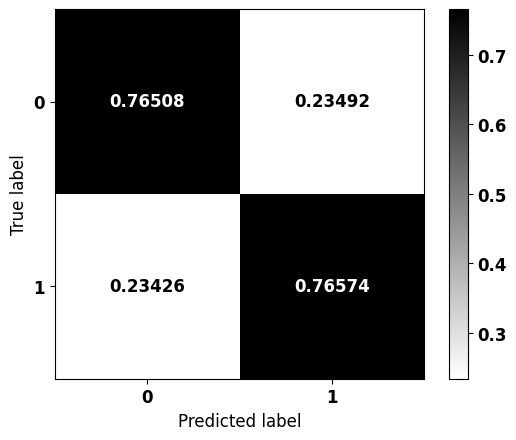


              precision    recall  f1-score   support

           0    0.85627   0.76508   0.80811      4376
           1    0.64119   0.76574   0.69795      2399

    accuracy                        0.76531      6775
   macro avg    0.74873   0.76541   0.75303      6775
weighted avg    0.78011   0.76531   0.76910      6775



In [ ]:
# XGBoost
xgb = XGBClassifier(max_depth=4,            # max_depth = 4
                    scale_pos_weight=1.34,  # Peso da classe 1
                    random_state=seed)      # Reprodutibilidade

# Treinamento do modelo
xgb.fit(X_train, y_train)

# Matriz de confusão
plot_confusion_matrix(xgb, X_test, y_test)

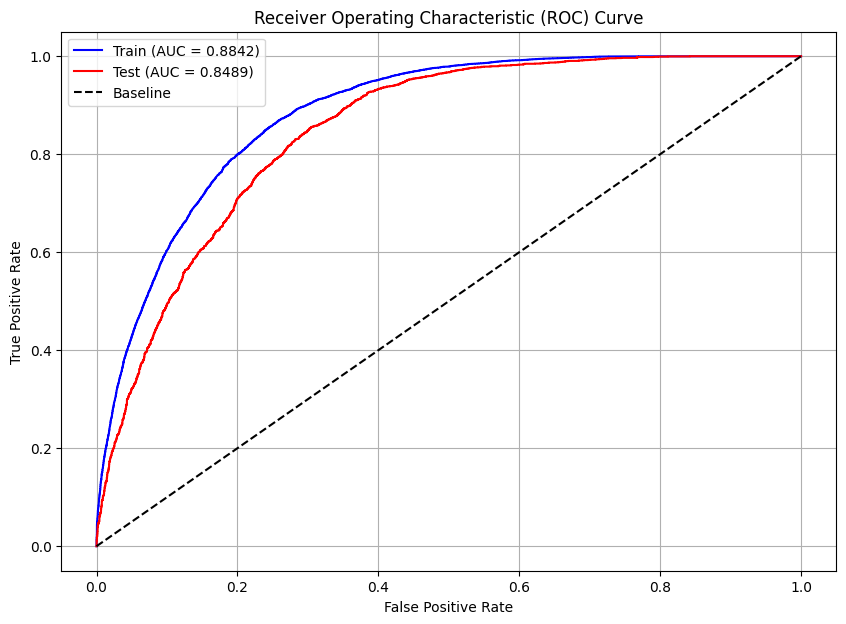

In [ ]:
# Curva ROC
plot_roc_curve(xgb, X_train, X_test, y_train, y_test)

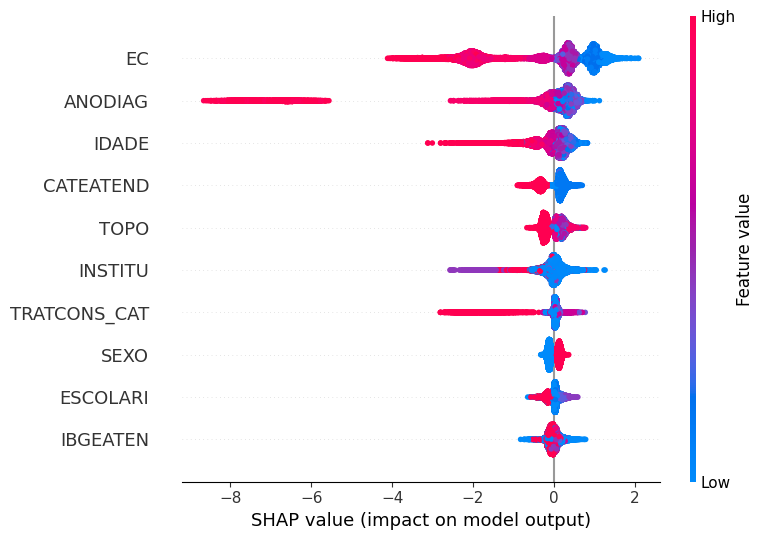

In [ ]:
# Importância pelo SHAP
plot_shap_values(xgb, X_train, feat_cols)

#### **Optuna**

In [ ]:
# Folds para validação cruzada
skf = StratifiedKFold(10, shuffle=True, random_state=seed)

# Função objetivo para otimização de hiperparâmetros
def objective(trial):

    # Define os hiperparâmetros que serão otimizados
    n_estimators = trial.suggest_int('n_estimators', 50, 150)  # Número de árvores
    max_depth = trial.suggest_int('max_depth', 3, 5)  # Profundidade máxima de cada árvore
    learning_rate = trial.suggest_float('learning_rate', 0.05, 0.2, step=0.05)  # Taxa de aprendizado
    gamma = trial.suggest_float('gamma', 0.0, 0.3, step=0.1)  # Termo de regularização
    min_child_weight = trial.suggest_int('min_child_weight', 1, 7)  # Mínimo peso para os nós filhos
    colsample_bytree = trial.suggest_float('colsample_bytree', 0.3, 0.7, step=0.1)  # Fração de features para cada árvore

    # Cria e treina o modelo com os hiperparâmetros escolhidos
    cls = XGBClassifier(n_estimators=n_estimators,
                        max_depth=max_depth,
                        learning_rate=learning_rate,
                        gamma=gamma,
                        min_child_weight=min_child_weight,
                        colsample_bytree=colsample_bytree,
                        random_state=seed,
                        n_jobs=-1)

    # Realiza a validação cruzada e retorna o valor médio de acurácia
    return cross_val_score(cls, X_train, y_train,
                           cv=skf, scoring='accuracy').mean()

**RandomSampler**

In [ ]:
# Otimização dos hiperparâmetros com Optuna - RandomSampler
studyXGB = optuna.create_study(direction='maximize', sampler=RandomSampler(seed))

# Inicia o estudo com 'n_trials'
studyXGB.optimize(objective, n_trials=150, n_jobs=-1)

In [ ]:
# Melhores hiperparâmetros encontrados
studyXGB.best_params

{'n_estimators': 141,
 'max_depth': 5,
 'learning_rate': 0.15000000000000002,
 'gamma': 0.0,
 'min_child_weight': 3,
 'colsample_bytree': 0.6000000000000001}

Best weight: 1.314


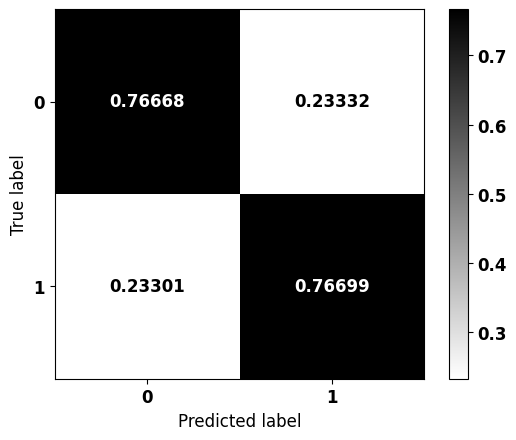


              precision    recall  f1-score   support

           0    0.85718   0.76668   0.80941      4376
           1    0.64313   0.76699   0.69962      2399

    accuracy                        0.76679      6775
   macro avg    0.75016   0.76683   0.75451      6775
weighted avg    0.78139   0.76679   0.77053      6775



In [ ]:
# Candidatos a scale_pos_weight após a busca por hiperparâmetros
pesos = np.round(np.arange(1.2, 1.35, 0.001), 3)

# Salva os melhores hiperparâmetros e fixa o random_state
params = studyXGB.best_params
params['random_state'] = seed
mean, peso = 0, 0  # Média e peso

# Itera entre os candidatos a peso
for i in pesos:
    params['scale_pos_weight'] = i  # Atualiza o peso

    # Cria o modelo com os parâmetros
    xgb_optuna = XGBClassifier()
    xgb_optuna.set_params(**params)

    # Treino do modelo
    xgb_optuna.fit(X_train, y_train)

    # Predições no conjunto de teste
    y_pred = xgb_optuna.predict(X_test)

    # Matriz de confusão para calcular se houve ganho no ajuste do peso
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred, normalize='true').ravel()

    # Verifica se a diferença das diagonais principais é menor que 0.1% e se a média é maior
    if (abs(tn - tp) <= 0.001) and ((tn+tp)/2 > mean):
        peso = i
        mean = (tn+tp)/2
        best = xgb_optuna

if peso != 0:
    print(f'Best weight: {peso}')  # Print do melhor peso encontrado
    plot_confusion_matrix(best, X_test, y_test)  # Matriz de confusão

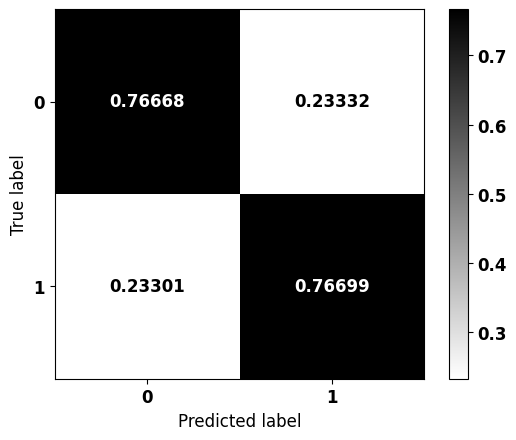


              precision    recall  f1-score   support

           0    0.85718   0.76668   0.80941      4376
           1    0.64313   0.76699   0.69962      2399

    accuracy                        0.76679      6775
   macro avg    0.75016   0.76683   0.75451      6775
weighted avg    0.78139   0.76679   0.77053      6775



In [ ]:
# Treino e validação com os melhores hiperparâmetros
params = studyXGB.best_params  # Salva os hiperparâmetros do estudo
params['random_state'] = seed  # Reprodutibilidade
params['scale_pos_weight'] = 1.314  # Peso para a classe 1

# Criação do modelo com os parâmetros encontrados
xgb_rand = XGBClassifier()
xgb_rand.set_params(**params)

# Treinamento do modelo
xgb_rand.fit(X_train, y_train)

# Matriz de confusão do modelo otimizado
plot_confusion_matrix(xgb_rand, X_test, y_test)

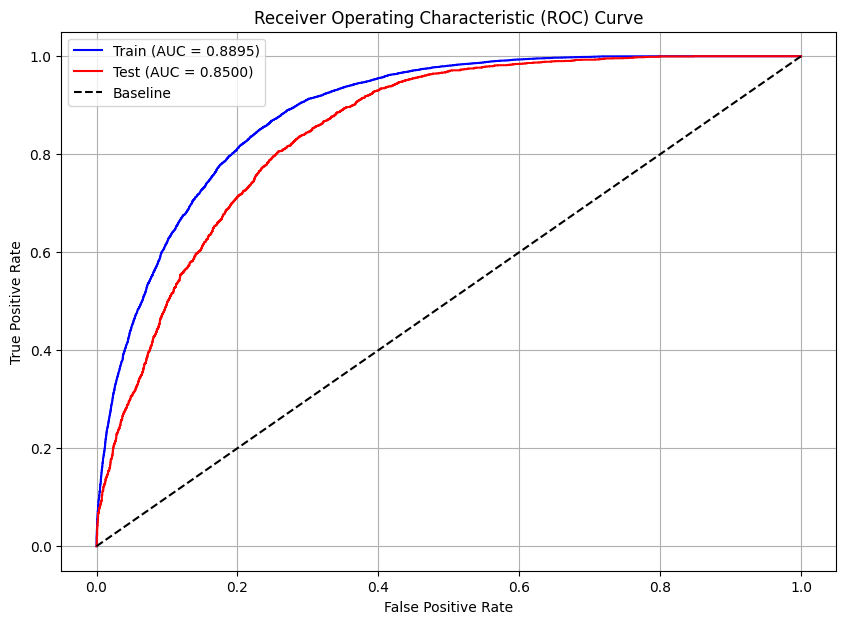

In [ ]:
# Curva ROC
plot_roc_curve(xgb_rand, X_train, X_test, y_train, y_test)

**TPESampler**

In [ ]:
# Otimização dos hiperparâmetros com Optuna - TPESampler
studyXGB = optuna.create_study(direction='maximize', sampler=TPESampler(seed=seed))

# Inicia o estudo com 'n_trials'
studyXGB.optimize(objective, n_trials=150, n_jobs=-1)

In [ ]:
# Melhores hiperparâmetros encontrados
studyXGB.best_params

{'n_estimators': 86,
 'max_depth': 5,
 'learning_rate': 0.2,
 'gamma': 0.3,
 'min_child_weight': 6,
 'colsample_bytree': 0.5}

1.317


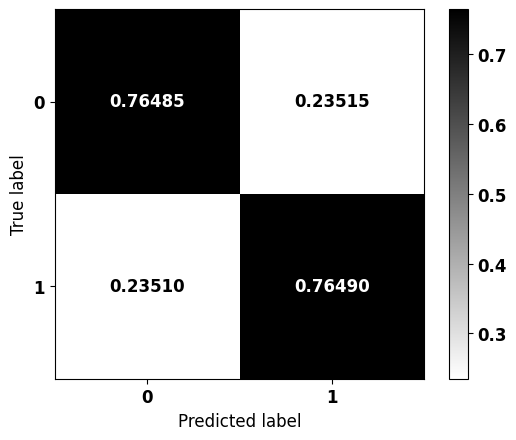


              precision    recall  f1-score   support

           0    0.85579   0.76485   0.80777      4376
           1    0.64071   0.76490   0.69732      2399

    accuracy                        0.76487      6775
   macro avg    0.74825   0.76488   0.75255      6775
weighted avg    0.77963   0.76487   0.76866      6775




In [ ]:
# Candidatos a scale_pos_weight após a busca por hiperparâmetros
pesos = np.round(np.arange(1.25, 1.35, 0.001), 3)

# Salva os melhores hiperparâmetros e fixa o random_state
params = studyXGB.best_params
params['random_state'] = seed
mean, peso = 0, 0  # Média e peso

# Itera entre os candidatos a peso
for i in pesos:
    params['scale_pos_weight'] = i  # Atualiza o peso

    # Cria o modelo com os parâmetros
    xgb_optuna = XGBClassifier()
    xgb_optuna.set_params(**params)

    # Treino do modelo
    xgb_optuna.fit(X_train, y_train)

    # Predições no conjunto de teste
    y_pred = xgb_optuna.predict(X_test)

    # Matriz de confusão para calcular se houve ganho no ajuste do peso
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred, normalize='true').ravel()

    # Verifica se a diferença das diagonais principais é menor que 0.1% e se a média é maior
    if (abs(tn - tp) <= 0.001) and ((tn+tp)/2 > mean):
        peso = i
        mean = (tn+tp)/2
        best = xgb_optuna

if peso != 0:
    print(f'Best weight: {peso}')  # Print do melhor peso encontrado
    plot_confusion_matrix(best, X_test, y_test)  # Matriz de confusão

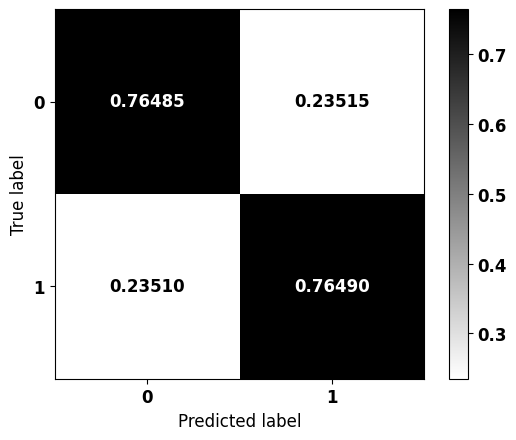


              precision    recall  f1-score   support

           0    0.85579   0.76485   0.80777      4376
           1    0.64071   0.76490   0.69732      2399

    accuracy                        0.76487      6775
   macro avg    0.74825   0.76488   0.75255      6775
weighted avg    0.77963   0.76487   0.76866      6775



In [ ]:
# Treino e validação com os melhores hiperparâmetros
params = studyXGB.best_params  # Salva os hiperparâmetros do estudo
params['random_state'] = seed  # Reprodutibilidade
params['scale_pos_weight'] = 1.317  # Peso para a classe 1

# Criação do modelo com os parâmetros encontrados
xgb_tpe = XGBClassifier()
xgb_tpe.set_params(**params)

# Treinamento do modelo
xgb_tpe.fit(X_train, y_train)

# Matriz de confusão do modelo otimizado
plot_confusion_matrix(xgb_tpe, X_test, y_test)

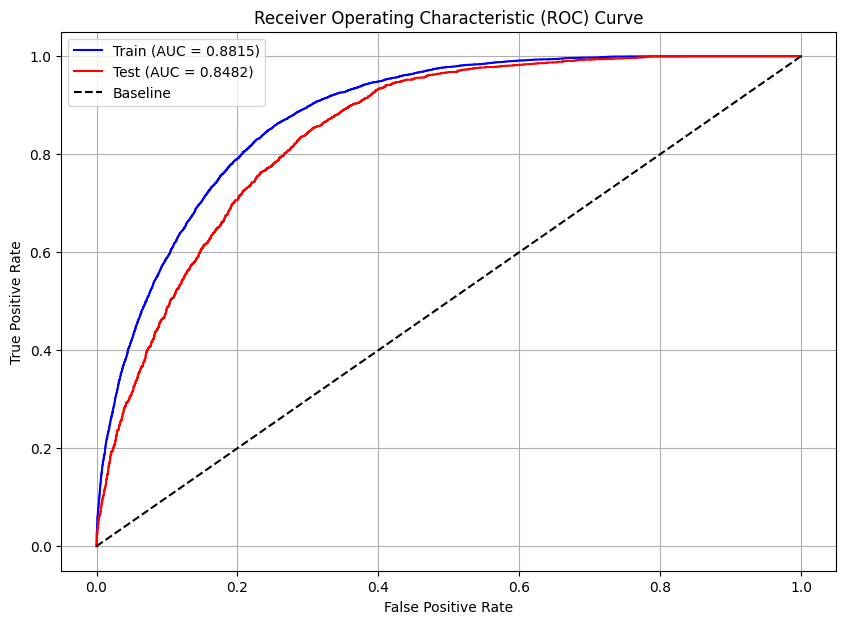

In [ ]:
# Curva ROC
plot_roc_curve(xgb_tpe, X_train, X_test, y_train, y_test)

**CmaEsSampler**

In [ ]:
# Otimização dos hiperparâmetros com Optuna - CmaEsSampler
studyXGB = optuna.create_study(direction='maximize', sampler=CmaEsSampler(seed=seed))

# Inicia o estudo com 'n_trials'
studyXGB.optimize(objective, n_trials=150, n_jobs=-1)

In [ ]:
# Melhores hiperparâmetros encontrados
studyXGB.best_params

{'n_estimators': 137,
 'max_depth': 5,
 'learning_rate': 0.15000000000000002,
 'gamma': 0.1,
 'min_child_weight': 6,
 'colsample_bytree': 0.3}

Best weight: 1.286


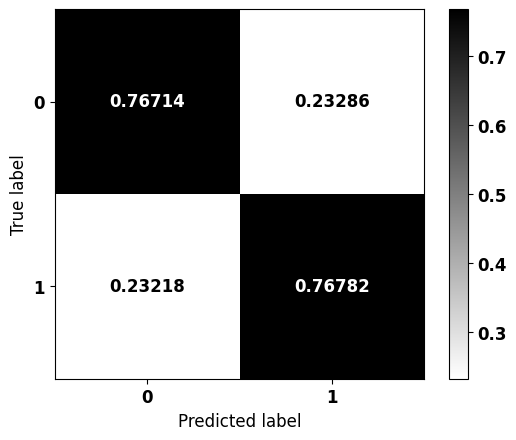


              precision    recall  f1-score   support

           0    0.85769   0.76714   0.80989      4376
           1    0.64383   0.76782   0.70038      2399

    accuracy                        0.76738      6775
   macro avg    0.75076   0.76748   0.75514      6775
weighted avg    0.78196   0.76738   0.77111      6775



In [ ]:
# Candidatos a scale_pos_weight após a busca por hiperparâmetros
pesos = np.round(np.arange(1.2, 1.35, 0.001), 3)

# Salva os melhores hiperparâmetros e fixa o random_state
params = studyXGB.best_params
params['random_state'] = seed
mean, peso = 0, 0  # Média e peso

# Itera entre os candidatos a peso
for i in pesos:
    params['scale_pos_weight'] = i  # Atualiza o peso

    # Cria o modelo com os parâmetros
    xgb_optuna = XGBClassifier()
    xgb_optuna.set_params(**params)

    # Treino do modelo
    xgb_optuna.fit(X_train, y_train)

    # Predições no conjunto de teste
    y_pred = xgb_optuna.predict(X_test)

    # Matriz de confusão para calcular se houve ganho no ajuste do peso
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred, normalize='true').ravel()

    # Verifica se a diferença das diagonais principais é menor que 0.1% e se a média é maior
    if (abs(tn - tp) <= 0.001) and ((tn+tp)/2 > mean):
        peso = i
        mean = (tn+tp)/2
        best = xgb_optuna

if peso != 0:
    print(f'Best weight: {peso}')  # Print do melhor peso encontrado
    plot_confusion_matrix(best, X_test, y_test)  # Matriz de confusão

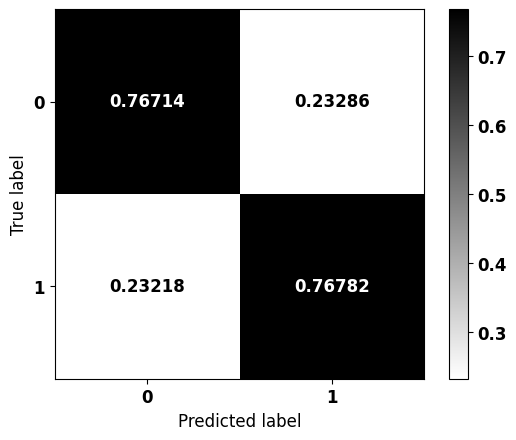


              precision    recall  f1-score   support

           0    0.85769   0.76714   0.80989      4376
           1    0.64383   0.76782   0.70038      2399

    accuracy                        0.76738      6775
   macro avg    0.75076   0.76748   0.75514      6775
weighted avg    0.78196   0.76738   0.77111      6775



In [ ]:
# Treino e validação com os melhores hiperparâmetros
params = studyXGB.best_params  # Salva os hiperparâmetros do estudo
params['random_state'] = seed  # Reprodutibilidade
params['scale_pos_weight'] = 1.286  # Peso para a classe 1

# Criação do modelo com os parâmetros encontrados
xgb_cma = XGBClassifier()
xgb_cma.set_params(**params)

# Treinamento do modelo
xgb_cma.fit(X_train, y_train)

# Matriz de confusão do modelo otimizado
plot_confusion_matrix(xgb_cma, X_test, y_test)

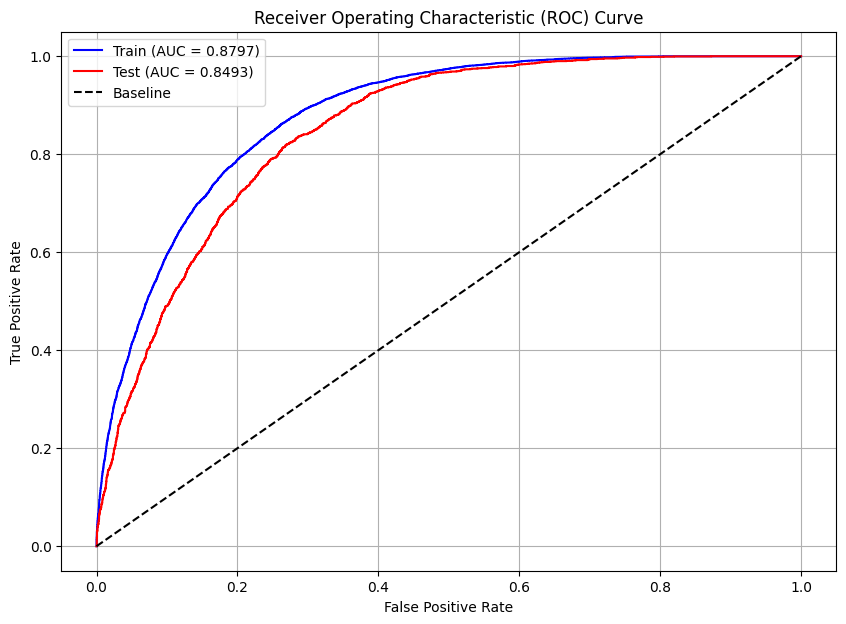

In [ ]:
# Curva ROC
plot_roc_curve(xgb_cma, X_train, X_test, y_train, y_test)

**Modelo otimizado**

In [ ]:
# Seleção do melhor modelo
models = [xgb_rand, xgb_tpe, xgb_cma]  # Lista dos modelos
best = models[0]

# Itera entre os modelos para encontrar o com maior acurácia
for i, m in enumerate(models):
    if i == 0:
        continue

    best_score = best.score(X_test, y_test)  # Acurácia do melhor modelo
    score = m.score(X_test, y_test)  # Acurácia do modelo atual

    if score > best_score:  # Atualiza o melhor modelo se a acurácia for maior
        best = m

# Print do melhor modelo selecionado
print(best)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.3, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=0.1, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.15000000000000002,
              max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=6, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=137, n_jobs=None,
              num_parallel_tree=None, random_state=1, ...)


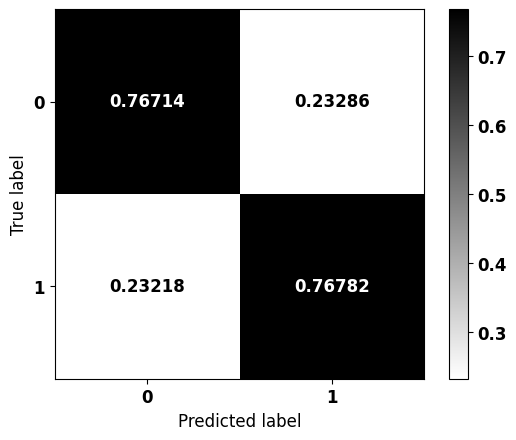


              precision    recall  f1-score   support

           0    0.85769   0.76714   0.80989      4376
           1    0.64383   0.76782   0.70038      2399

    accuracy                        0.76738      6775
   macro avg    0.75076   0.76748   0.75514      6775
weighted avg    0.78196   0.76738   0.77111      6775



In [ ]:
# Treinamento do modelo final com os melhores hiperparâmetros
params = best.get_params()

# Inicializa o modelo final
xgb_optuna = XGBClassifier()
xgb_optuna.set_params(**params)

# Treinamento do modelo otimizado
xgb_optuna.fit(X_train, y_train)

# Plot da matriz de confusão para o conjunto de teste
plot_confusion_matrix(xgb_optuna, X_test, y_test)

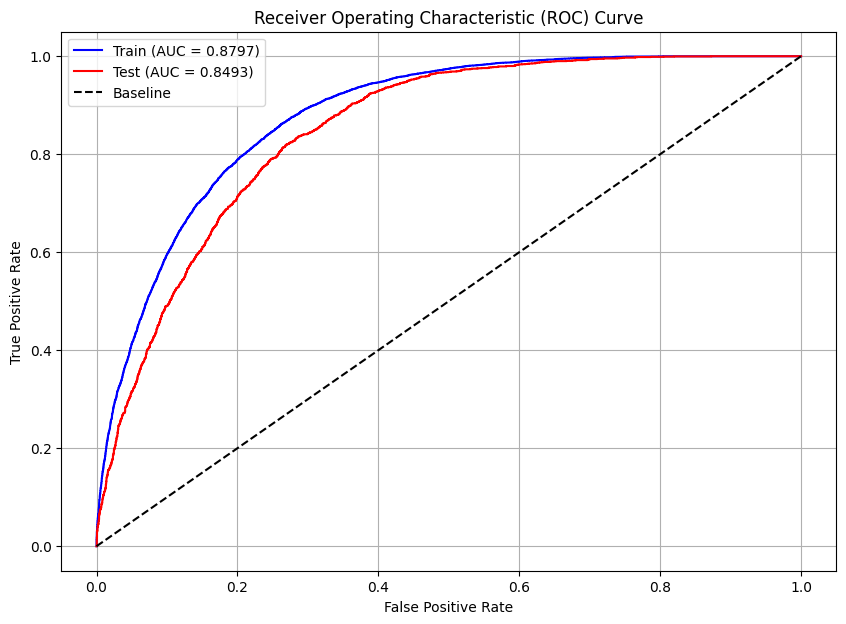

In [ ]:
# Curva ROC
plot_roc_curve(xgb_optuna, X_train, X_test, y_train, y_test)

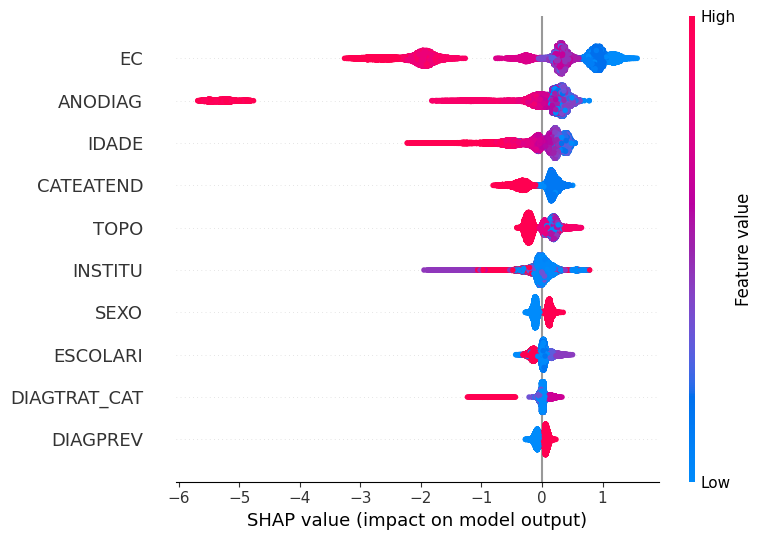

In [ ]:
# Importância das features pelo SHAP
plot_shap_values(xgb_optuna, X_train, feat_cols)

### **LightGBM**


#### **Baseline**

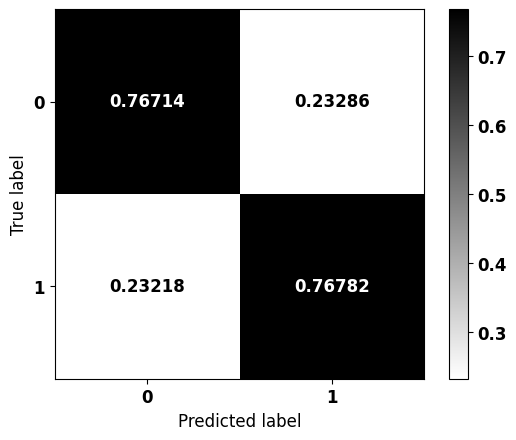


              precision    recall  f1-score   support

           0    0.85769   0.76714   0.80989      4376
           1    0.64383   0.76782   0.70038      2399

    accuracy                        0.76738      6775
   macro avg    0.75076   0.76748   0.75514      6775
weighted avg    0.78196   0.76738   0.77111      6775



In [ ]:
# Cria e treina o modelo LightGBM

# Inicializa o classificador LightGBM com os parâmetros especificados
lgbm = LGBMClassifier(max_depth=7,                      # Define a profundidade máxima das árvores
                      class_weight={0: 1, 1: 1.285},    # Ajusta o peso das classes para lidar com o desbalanceamento
                      random_state=seed,                # Garante a reprodutibilidade dos resultados
                      verbose=-1)

# Treina o modelo utilizando o conjunto de dados de treinamento
lgbm.fit(X_train, y_train)

# Matriz de confusão

# Gera e exibe a matriz de confusão para avaliar as classificações
# realizadas pelo modelo no conjunto de teste
plot_confusion_matrix(lgbm, X_test, y_test)

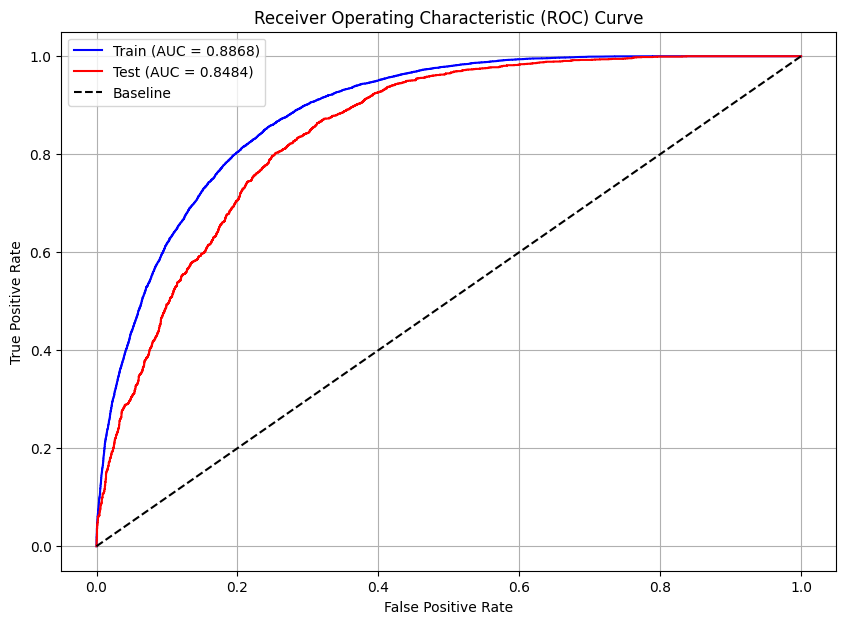

In [ ]:
# Curva ROC
plot_roc_curve(lgbm, X_train, X_test, y_train, y_test)

/usr/local/lib/python3.11/dist-packages/shap/explainers/_tree.py:583: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


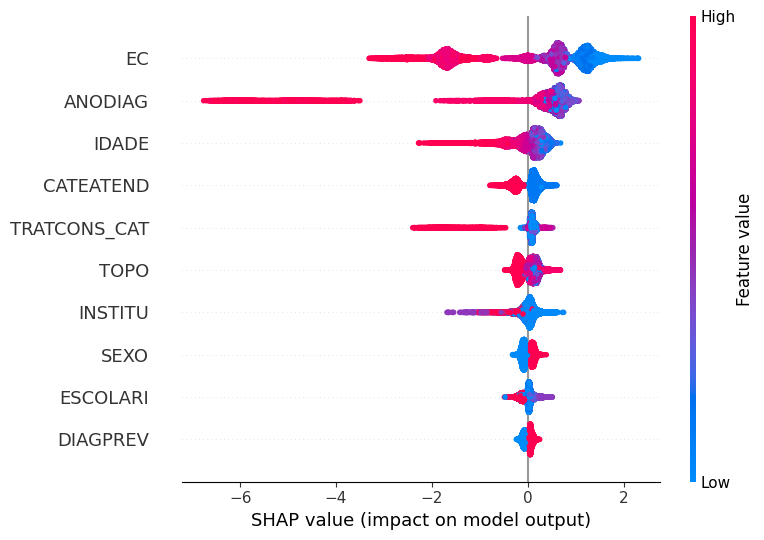

In [ ]:
# Importância pelo SHAP
plot_shap_values(lgbm, X_train, feat_cols)

#### **Optuna**

In [ ]:
# Cria os folds estratificados, mantendo aproximadamente a mesma proporção
# de classes em cada divisão dos dados
skf = StratifiedKFold(10, shuffle=True, random_state=seed)

# Define a função objetivo utilizada pelo Optuna para otimizar
# os hiperparâmetros do modelo LightGBM
def objective(trial):

    # Define o espaço de busca dos hiperparâmetros
    # Número de árvores utilizadas pelo modelo
    n_estimators = trial.suggest_int('n_estimators', 50, 150)

    # Profundidade máxima das árvores
    max_depth = trial.suggest_int('max_depth', 3, 7)

    # Taxa de aprendizado utilizada durante o treinamento
    learning_rate = trial.suggest_float('learning_rate', 0.05, 0.2, step=0.01)

    # Soma mínima dos pesos necessária para criar um novo nó filho
    min_child_weight = trial.suggest_int('min_child_weight', 1, 7)

    # Proporção de variáveis selecionadas aleatoriamente para cada árvore
    colsample_bytree = trial.suggest_float('colsample_bytree', 0.3, 0.7, step=0.1)

    # Inicializa o classificador LightGBM com os hiperparâmetros
    # selecionados pelo Optuna na iteração atual
    cls = LGBMClassifier(n_estimators=n_estimators,
                         max_depth=max_depth,
                         learning_rate=learning_rate,
                         min_child_weight=min_child_weight,
                         colsample_bytree=colsample_bytree,
                         random_state=seed,
                         verbose=-1,
                         n_jobs=-1)

    # Realiza validação cruzada estratificada e retorna a média
    # da acurácia obtida nos 10 folds.
    # O Optuna utiliza esse valor como função objetivo para selecionar
    # a combinação de hiperparâmetros com melhor desempenho.
    return cross_val_score(cls, X_train, y_train,
                           cv=skf, scoring='accuracy').mean()

**RandomSampler**

In [ ]:
# Otimização dos hiperparâmetros com Optuna - RandomSampler
studyLGBM = optuna.create_study(direction='maximize', sampler=RandomSampler(seed))

# Inicia o estudo com 'n_trials'
studyLGBM.optimize(objective, n_trials=150, n_jobs=-1)

In [ ]:
# Melhores hiperparâmetros encontrados
studyLGBM.best_params

{'n_estimators': 148,
 'max_depth': 7,
 'learning_rate': 0.09,
 'min_child_weight': 3,
 'colsample_bytree': 0.3}

Best weight: 1.282


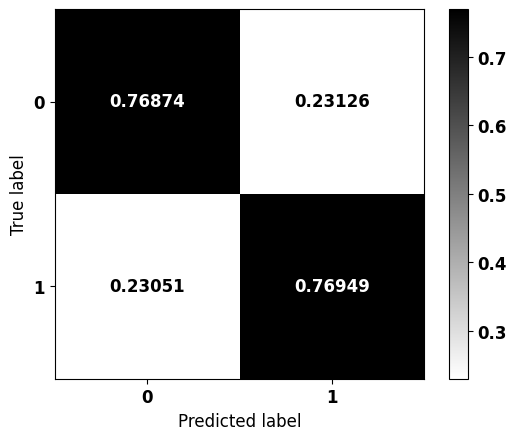


              precision    recall  f1-score   support

           0    0.85882   0.76874   0.81129      4376
           1    0.64591   0.76949   0.70230      2399

    accuracy                        0.76900      6775
   macro avg    0.75236   0.76911   0.75679      6775
weighted avg    0.78343   0.76900   0.77270      6775



In [ ]:
# Candidatos a class_weight após a busca por hiperparâmetros
pesos = np.round(np.arange(1.25, 1.35, 0.001), 3)

# Salva os melhores hiperparâmetros e fixa o random_state
params = studyLGBM.best_params
params['random_state'] = seed
mean, peso = 0, 0  # Média e peso

# Itera entre os candidatos a peso
for i in pesos:
    params['class_weight'] = {0:1, 1:i}  # Atualiza o peso

    # Cria o modelo com os parâmetros
    lgbm_optuna = LGBMClassifier(verbose=-1)
    lgbm_optuna.set_params(**params)

    # Treino do modelo
    lgbm_optuna.fit(X_train, y_train)

    # Predições no conjunto de teste
    y_pred = lgbm_optuna.predict(X_test)

    # Matriz de confusão para calcular se houve ganho no ajuste do peso
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred, normalize='true').ravel()

    # Verifica se a diferença das diagonais principais é menor que 0.1% e se a média é maior
    if (abs(tn - tp) <= 0.001) and ((tn+tp)/2 > mean):
        peso = i
        mean = (tn+tp)/2
        best = lgbm_optuna

if peso != 0:
    print(f'Best weight: {peso}')  # Print do melhor peso encontrado
    plot_confusion_matrix(best, X_test, y_test)  # Matriz de confusão

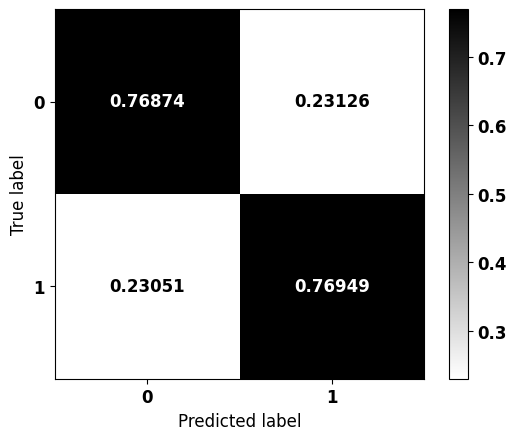


              precision    recall  f1-score   support

           0    0.85882   0.76874   0.81129      4376
           1    0.64591   0.76949   0.70230      2399

    accuracy                        0.76900      6775
   macro avg    0.75236   0.76911   0.75679      6775
weighted avg    0.78343   0.76900   0.77270      6775



In [ ]:
# Treino e validação com os melhores hiperparâmetros
params = studyLGBM.best_params  # Salva os hiperparâmetros do estudo
params['random_state'] = seed  # Reprodutibilidade
params['class_weight'] = {0:1, 1:1.282}  # Peso para a classe 1

# Criação do modelo com os parâmetros encontrados
lgbm_rand = LGBMClassifier(verbose=-1)
lgbm_rand.set_params(**params)

# Treinamento do modelo
lgbm_rand.fit(X_train, y_train)

# Matriz de confusão do modelo otimizado
plot_confusion_matrix(lgbm_rand, X_test, y_test)

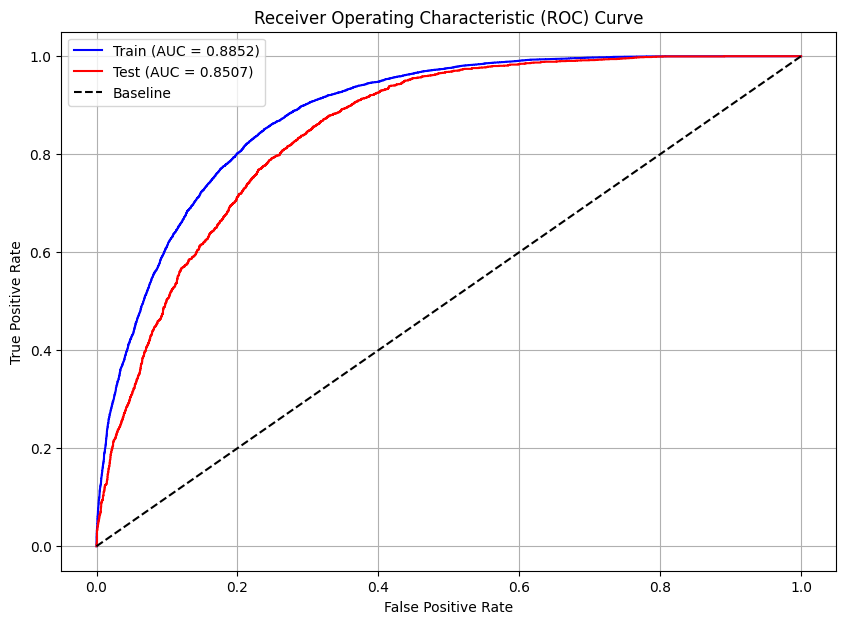

In [ ]:
# Curva ROC
plot_roc_curve(lgbm_rand, X_train, X_test, y_train, y_test)

**TPESampler**

In [ ]:
# Otimização dos hiperparâmetros com Optuna - TPESampler
studyLGBM = optuna.create_study(direction='maximize', sampler=TPESampler(seed=seed))

# Inicia o estudo com 'n_trials'
studyLGBM.optimize(objective, n_trials=150, n_jobs=-1)

In [ ]:
# Melhores hiperparâmetros encontrados
studyLGBM.best_params

{'n_estimators': 145,
 'max_depth': 7,
 'learning_rate': 0.12000000000000001,
 'min_child_weight': 5,
 'colsample_bytree': 0.4}

Best weight: 1.319


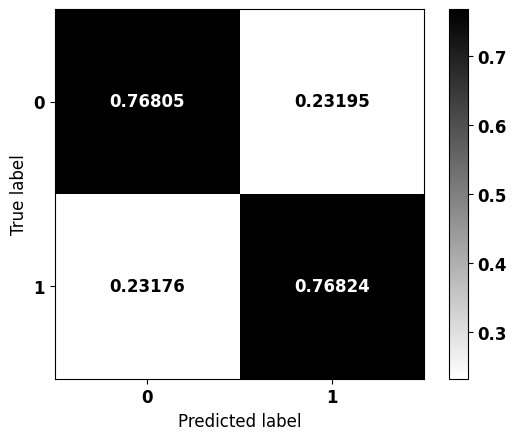


              precision    recall  f1-score   support

           0    0.85805   0.76805   0.81056      4376
           1    0.64486   0.76824   0.70116      2399

    accuracy                        0.76812      6775
   macro avg    0.75146   0.76814   0.75586      6775
weighted avg    0.78256   0.76812   0.77182      6775



In [ ]:
# Candidatos a class_weight após a busca por hiperparâmetros
pesos = np.round(np.arange(1.25, 1.35, 0.001), 3)

# Salva os melhores hiperparâmetros e fixa o random_state
params = studyLGBM.best_params
params['random_state'] = seed
mean, peso = 0, 0  # Média e peso

# Itera entre os candidatos a peso
for i in pesos:
    params['class_weight'] = {0:1, 1:i}  # Atualiza o peso

    # Cria o modelo com os parâmetros
    lgbm_optuna = LGBMClassifier(verbose=-1)
    lgbm_optuna.set_params(**params)

    # Treino o modelo
    lgbm_optuna.fit(X_train, y_train)

    # Predições no conjunto de teste
    y_pred = lgbm_optuna.predict(X_test)

    # Matriz de confusão para calcular se houve ganho no ajuste do peso
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred, normalize='true').ravel()

    # Verifica se a diferença das diagonais principais é menor que 0.1% e se a média é maior
    if (abs(tn - tp) <= 0.001) and ((tn+tp)/2 > mean):
        peso = i
        mean = (tn+tp)/2
        best = lgbm_optuna

if peso != 0:
    print(f'Best weight: {peso}')  # Print do melhor peso encontrado
    plot_confusion_matrix(best, X_test, y_test)  # Matriz de confusão

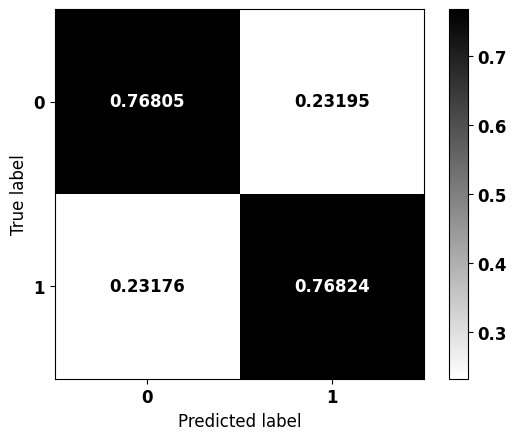


              precision    recall  f1-score   support

           0    0.85805   0.76805   0.81056      4376
           1    0.64486   0.76824   0.70116      2399

    accuracy                        0.76812      6775
   macro avg    0.75146   0.76814   0.75586      6775
weighted avg    0.78256   0.76812   0.77182      6775



In [ ]:
# Treino e validação com os melhores hiperparâmetros
params = studyLGBM.best_params  # Salva os hiperparâmetros do estudo
params['random_state'] = seed  # Reprodutibilidade
params['class_weight'] = {0:1, 1:1.319}  # Peso para a classe 1

# Criação do modelo com os parâmetros encontrados
lgbm_tpe = LGBMClassifier(verbose=-1)
lgbm_tpe.set_params(**params)

# Treinamento do modelo
lgbm_tpe.fit(X_train, y_train)

# Matriz de confusão do modelo otimizado
plot_confusion_matrix(lgbm_tpe, X_test, y_test)

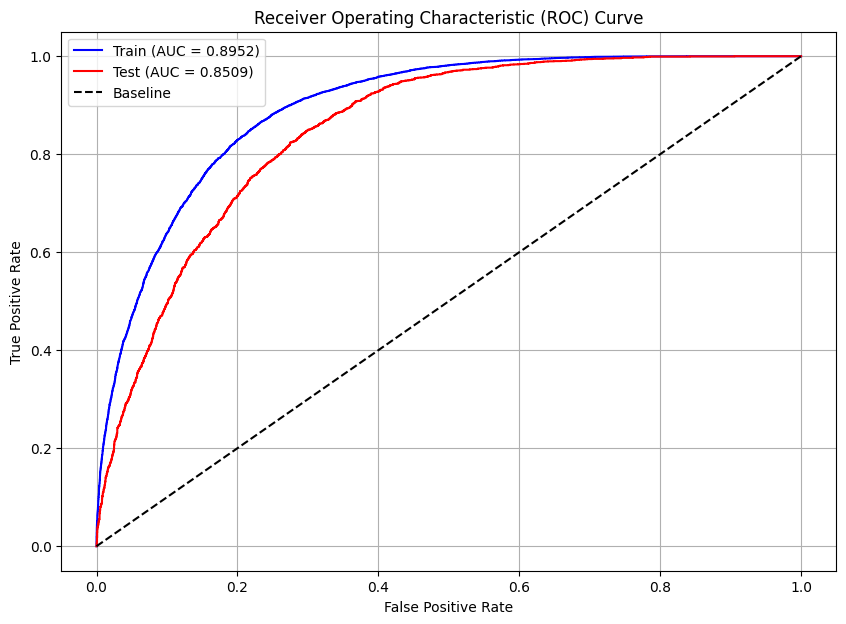

In [ ]:
# Curva ROC
plot_roc_curve(lgbm_tpe, X_train, X_test, y_train, y_test)

**CmaEsSampler**

In [ ]:
# Otimização dos hiperparâmetros com Optuna - CmaEsSampler
studyLGBM = optuna.create_study(direction='maximize', sampler=CmaEsSampler(seed=seed))

# Inicia o estudo com 'n_trials'
studyLGBM.optimize(objective, n_trials=150, n_jobs=-1)

In [ ]:
# Melhores hiperparâmetros encontrados
studyLGBM.best_params

{'n_estimators': 132,
 'max_depth': 7,
 'learning_rate': 0.13,
 'min_child_weight': 6,
 'colsample_bytree': 0.4}

Best weight: 1.324


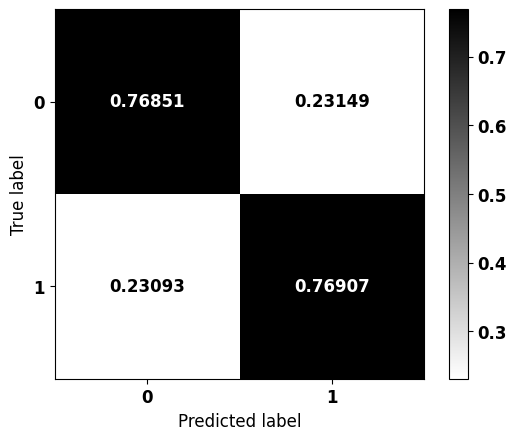


              precision    recall  f1-score   support

           0    0.85857   0.76851   0.81105      4376
           1    0.64556   0.76907   0.70192      2399

    accuracy                        0.76871      6775
   macro avg    0.75206   0.76879   0.75648      6775
weighted avg    0.78314   0.76871   0.77241      6775



In [ ]:
# Candidatos a class_weight após a busca por hiperparâmetros
pesos = np.round(np.arange(1.25, 1.35, 0.001), 3)

# Salva os melhores hiperparâmetros e fixa o random_state
params = studyLGBM.best_params
params['random_state'] = seed
mean, peso = 0, 0  # Média e peso

# Itera entre os candidatos a peso
for i in pesos:
    params['class_weight'] = {0:1, 1:i}  # Atualiza o peso

    # Cria o modelo com os parâmetros
    lgbm_optuna = LGBMClassifier(verbose=-1)
    lgbm_optuna.set_params(**params)

    # Treino o modelo
    lgbm_optuna.fit(X_train, y_train)

    # Predições no conjunto de teste
    y_pred = lgbm_optuna.predict(X_test)

    # Matriz de confusão para calcular se houve ganho no ajuste do peso
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred, normalize='true').ravel()

    # Verifica se a diferença das diagonais principais é menor que 0.1% e se a média é maior
    if (abs(tn - tp) <= 0.001) and ((tn+tp)/2 > mean):
        peso = i
        mean = (tn+tp)/2
        best = lgbm_optuna

if peso != 0:
    print(f'Best weight: {peso}')  # Print do melhor peso encontrado
    plot_confusion_matrix(best, X_test, y_test)  # Matriz de confusão

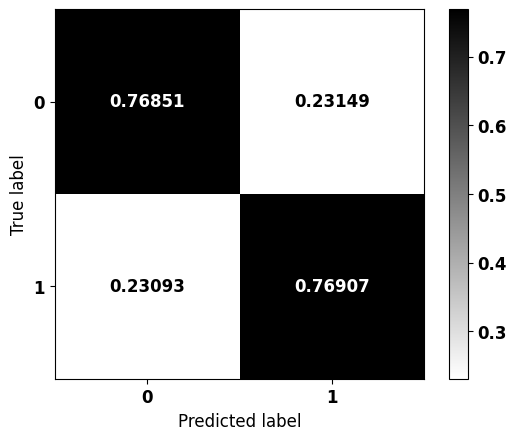


              precision    recall  f1-score   support

           0    0.85857   0.76851   0.81105      4376
           1    0.64556   0.76907   0.70192      2399

    accuracy                        0.76871      6775
   macro avg    0.75206   0.76879   0.75648      6775
weighted avg    0.78314   0.76871   0.77241      6775



In [ ]:
# Treino e validação com os melhores hiperparâmetros
params = studyLGBM.best_params  # Salva os hiperparâmetros do estudo
params['random_state'] = seed  # Reprodutibilidade
params['class_weight'] = {0:1, 1:1.324}  # Peso para a classe 1

# Criação do modelo com os parâmetros encontrados
lgbm_cma = LGBMClassifier(verbose=-1)
lgbm_cma.set_params(**params)

# Treinamento do modelo
lgbm_cma.fit(X_train, y_train)

# Matriz de confusão do modelo otimizado
plot_confusion_matrix(lgbm_cma, X_test, y_test)

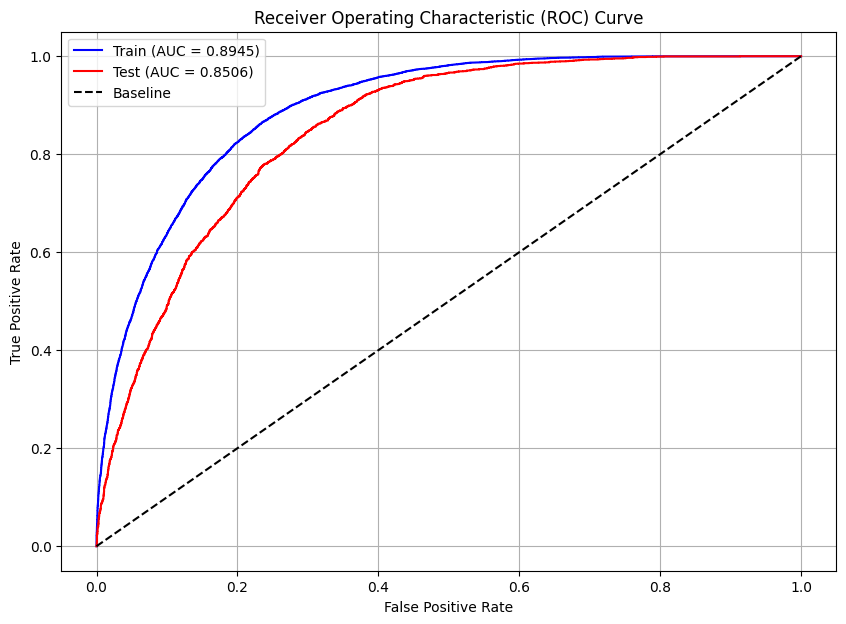

In [ ]:
# Curva ROC
plot_roc_curve(lgbm_cma, X_train, X_test, y_train, y_test)

**Modelo otimizado**

In [ ]:
# Seleção do melhor modelo
models = [lgbm_rand, lgbm_tpe, lgbm_cma]  # Lista dos modelos
best = models[0]

# Itera entre os modelos para encontrar o com maior acurácia
for i, m in enumerate(models):
    if i == 0:
        continue

    best_score = best.score(X_test, y_test)  # Acurácia do melhor modelo
    score = m.score(X_test, y_test)  # Acurácia do modelo atual

    if score > best_score:  # Atualiza o melhor modelo se a acurácia for maior
        best = m

# Print do melhor modelo selecionado
print(best)

LGBMClassifier(class_weight={0: 1, 1: 1.282}, colsample_bytree=0.3,
               learning_rate=0.09, max_depth=7, min_child_weight=3,
               n_estimators=148, random_state=1, verbose=-1)


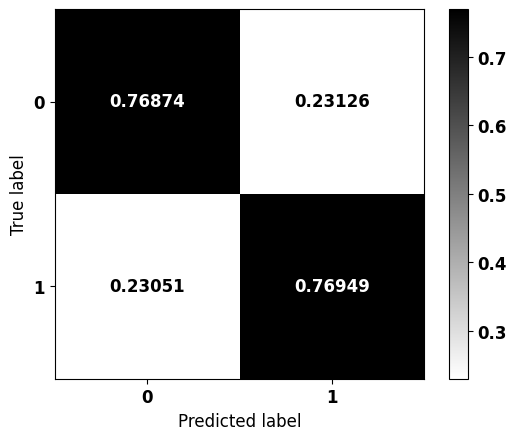


              precision    recall  f1-score   support

           0    0.85882   0.76874   0.81129      4376
           1    0.64591   0.76949   0.70230      2399

    accuracy                        0.76900      6775
   macro avg    0.75236   0.76911   0.75679      6775
weighted avg    0.78343   0.76900   0.77270      6775



In [ ]:
# Treinamento do modelo final com os melhores hiperparâmetros
params = best.get_params()

# Inicializa o modelo final
lgbm_optuna = LGBMClassifier(verbose=-1)
lgbm_optuna.set_params(**params)

# Treinamento do modelo otimizado
lgbm_optuna.fit(X_train, y_train)

# Plot da matriz de confusão para o conjunto de teste
plot_confusion_matrix(lgbm_optuna, X_test, y_test)

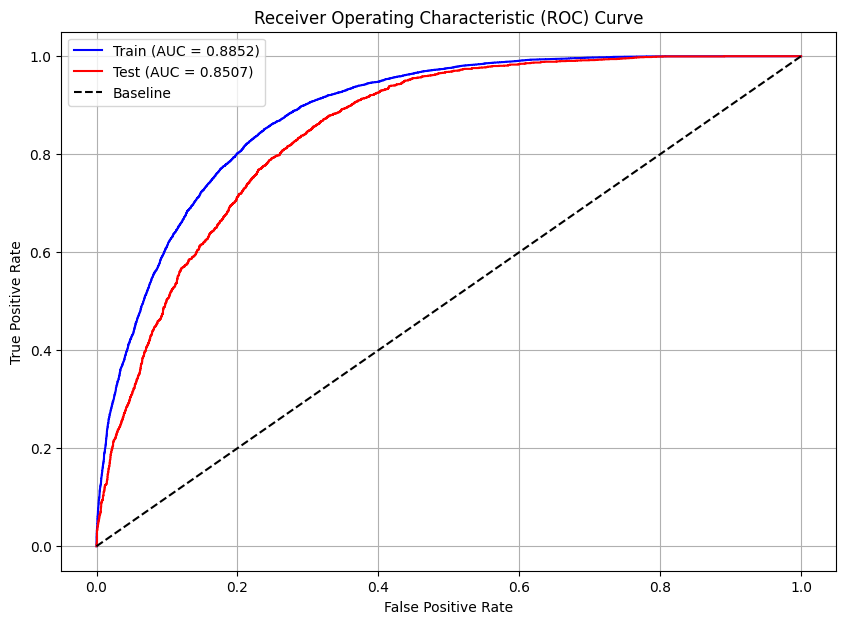

In [ ]:
# Curva ROC
plot_roc_curve(lgbm_optuna, X_train, X_test, y_train, y_test)

/usr/local/lib/python3.11/dist-packages/shap/explainers/_tree.py:583: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


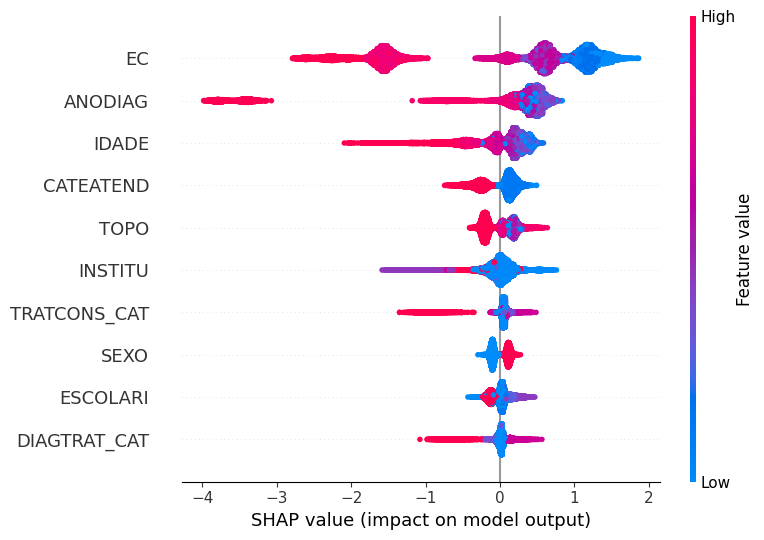

In [ ]:
# Importância das features pelo SHAP
plot_shap_values(lgbm_optuna, X_train, feat_cols)

## **Voting Classifier**


In [ ]:
# Compara as acurácias do modelo XGBoost inicial e do modelo
# otimizado pelo Optuna no conjunto de teste
xgb_score = xgb.score(X_test, y_test)
optuna_score = xgb_optuna.score(X_test, y_test)

# Exibe a acurácia de cada modelo com quatro casas decimais
print(f'Accuracy: XGB = {xgb_score:.4f}, Optuna = {optuna_score:.4f}\n')

# Verifica qual dos dois modelos apresentou o melhor desempenho

# Caso o modelo otimizado pelo Optuna apresente acurácia maior ou igual
# à do modelo inicial, seleciona o modelo otimizado
if optuna_score >= xgb_score:
    # Obtém os hiperparâmetros do modelo otimizado
    params_xgb = xgb_optuna.get_params()

    # Informa que o modelo otimizado apresentou o melhor desempenho
    print('Optimized model won')

else:
    # Caso contrário, obtém os hiperparâmetros do modelo inicial
    params_xgb = xgb.get_params()

    # Informa que o modelo inicial apresentou o melhor desempenho
    print('Initial model won')

Accuracy: XGB = 0.7653, Optuna = 0.7674

Optimized model won


In [ ]:
# Compara as acurácias do modelo LightGBM inicial e do modelo
# otimizado pelo Optuna no conjunto de teste
lgbm_score = lgbm.score(X_test, y_test)
optuna_score = lgbm_optuna.score(X_test, y_test)

# Exibe a acurácia de cada modelo com quatro casas decimais
print(f'Accuracy: LGBM = {lgbm_score:.4f}, Optuna = {optuna_score:.4f}\n')

# Verifica qual dos dois modelos apresentou o melhor desempenho

# Caso o modelo otimizado pelo Optuna apresente acurácia maior ou igual
# à do modelo inicial, seleciona o modelo otimizado
if optuna_score >= lgbm_score:
    # Obtém os hiperparâmetros do modelo otimizado pelo Optuna
    params_lgbm = lgbm_optuna.get_params()

    # Informa que o modelo otimizado apresentou o melhor desempenho
    print('Optimized model won')

else:
    # Caso contrário, obtém os hiperparâmetros do modelo LightGBM inicial
    params_lgbm = lgbm.get_params()

    # Informa que o modelo inicial apresentou o melhor desempenho
    print('Initial model won')

Accuracy: LGBM = 0.7674, Optuna = 0.7690

Optimized model won


In [ ]:
# Cria os modelos utilizando os hiperparâmetros que apresentaram
# o melhor desempenho durante o processo de avaliação

# Modelo XGBoost
# Inicializa o classificador XGBoost
best_xgb = XGBClassifier()

# Define os melhores hiperparâmetros selecionados para o modelo XGBoost
best_xgb.set_params(**params_xgb)

# Modelo LightGBM
# Inicializa o classificador LightGBM
best_lgbm = LGBMClassifier()

# Define os melhores hiperparâmetros selecionados para o modelo LightGBM
best_lgbm.set_params(**params_lgbm)

LGBMClassifier(class_weight={0: 1, 1: 1.282}, colsample_bytree=0.3,
               learning_rate=0.09, max_depth=7, min_child_weight=3,
               n_estimators=148, random_state=1, verbose=-1)

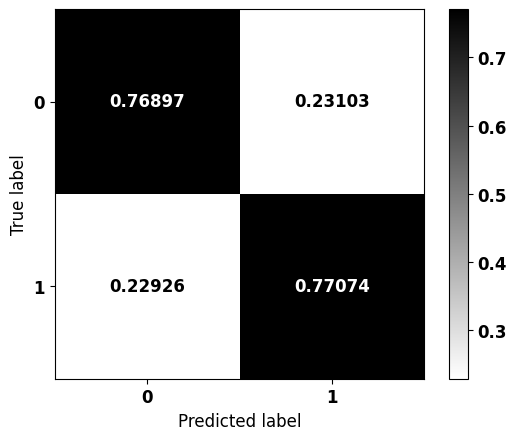


              precision    recall  f1-score   support

           0    0.85951   0.76897   0.81172      4376
           1    0.64650   0.77074   0.70318      2399

    accuracy                        0.76959      6775
   macro avg    0.75301   0.76985   0.75745      6775
weighted avg    0.78409   0.76959   0.77329      6775



In [ ]:
# Importa o classificador de votação da biblioteca scikit-learn
from sklearn.ensemble import VotingClassifier

# Cria o classificador de votação utilizando os modelos
# XGBoost e LightGBM com melhor desempenho
clf = VotingClassifier(
    estimators=[
        # Adiciona o modelo XGBoost com os melhores hiperparâmetros
        ('XGBoost', best_xgb),
        # Adiciona o modelo LightGBM com os melhores hiperparâmetros
        ('LightGBM', best_lgbm)
    ],
    # Utiliza votação ponderada pelas probabilidades previstas pelos modelos.
    # A classe final é determinada pela maior probabilidade média entre os modelos.
    voting='soft'
)

# Treina o classificador de votação utilizando o conjunto de treinamento
clf.fit(X_train, y_train)

# Matriz de confusão
# Gera e exibe a matriz de confusão para avaliar o desempenho
# do classificador de votação no conjunto de teste
plot_confusion_matrix(clf, X_test, y_test)

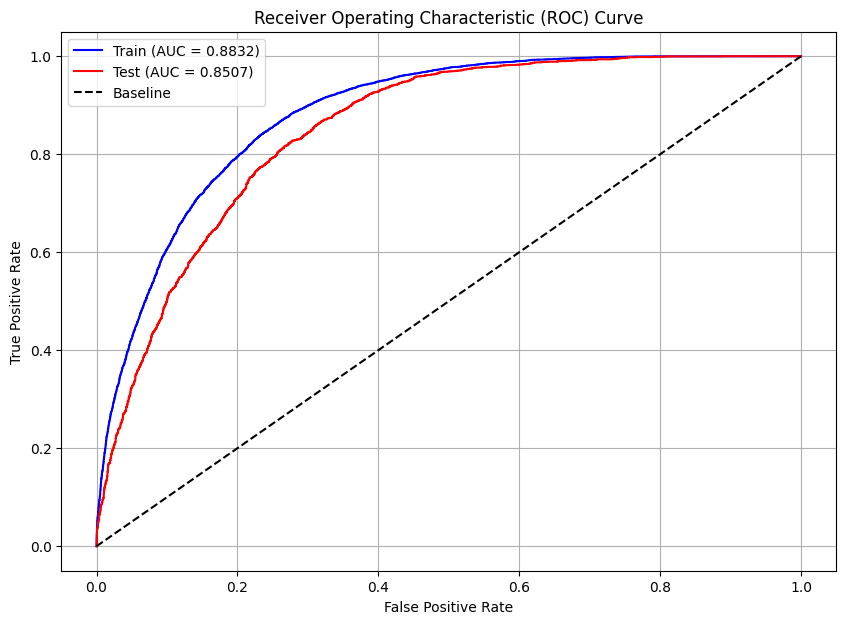

In [ ]:
# Curva ROC
plot_roc_curve(clf, X_train, X_test, y_train, y_test)